# ExpresSo Demand Forecasting - Full EDA Notebook

This notebook combines the original large EDA notebook with the deep-dive add-on so the analysis keeps the full chart set from the old version and adds normalized demand diagnostics, forecast-window checks, drift analysis, and stockout validation.

## Notebook Sections
1. Data loading and target construction
2. Core demand overview
3. Calendar and seasonality
4. Promotions and local events
5. Store operations and customer behavior
6. Diagnostics, drift, and stockout analysis
7. EDA summary for feature engineering


In [1]:
# CELL 1: Setup and Load
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "figure.figsize": (12, 5)})
plt.rcParams["font.family"] = ["DejaVu Sans", "Arial", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

BASE = Path("/kaggle/input/competitions/super-ai-engineer-season-6-coffee-chain-hackathon")
TRAIN = BASE / "train"
TEST = BASE / "test"

txn = pd.read_csv(TRAIN / "TRANSACTION.csv")
order = pd.read_csv(TRAIN / "ORDER.csv", parse_dates=["date"])
prod = pd.read_csv(TRAIN / "PRODUCT.csv")
store = pd.read_csv(TRAIN / "STORE.csv", parse_dates=["opened_date"])
promo = pd.read_csv(TRAIN / "PROMOTION.csv", parse_dates=["start_date", "end_date"])
cust = pd.read_csv(TRAIN / "CUSTOMER.csv", parse_dates=["registration_date"])
date_dim = pd.read_csv(TRAIN / "DATE_DIM.csv", parse_dates=["date"])
event = pd.read_csv(TRAIN / "LOCAL_EVENT.csv", parse_dates=["date"])
inventory = pd.read_csv(TRAIN / "INVENTORY.csv", parse_dates=["date"])

test_date = pd.read_csv(TEST / "DATE_DIM.csv", parse_dates=["date"])
test_promo = pd.read_csv(TEST / "PROMOTION.csv", parse_dates=["start_date", "end_date"])
test_event = pd.read_csv(TEST / "LOCAL_EVENT.csv", parse_dates=["date"])

# Build canonical daily target
line = (
    txn.merge(order[["order_id", "store_id", "date", "customer_id", "hour", "is_member", "payment_method"]], on="order_id")
       .merge(prod[["product_id", "category", "base_price", "is_seasonal", "is_limited_edition", "product_name", "serve_type"]], on="product_id")
)
df = line.copy()

daily = (
    line.groupby(["store_id", "category", "date"], observed=True)
        .agg(
            units_sold=("units_sold", "sum"),
            revenue=("revenue", "sum") if "revenue" in line.columns else ("units_sold", "count"),
            n_orders=("order_id", "nunique"),
            n_customers=("customer_id", "nunique"),
        )
        .reset_index()
)

all_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
cat_order = [
    "Coffee", "Tea", "Chocolate & Milk", "Juice & Smoothie",
    "Bakery", "Savory Bakery", "Merchandise",
]
idx = pd.MultiIndex.from_product(
    [sorted(daily["store_id"].unique()), cat_order, all_dates],
    names=["store_id", "category", "date"],
)
daily = daily.set_index(["store_id", "category", "date"]).reindex(idx, fill_value=0).reset_index()
daily = daily.merge(store, on="store_id", how="left")
daily = daily.merge(date_dim, on="date", how="left")
daily["dow_baseline"] = daily.groupby(["store_id", "category", "day_of_week"])["units_sold"].transform("mean")
daily["units_rel"] = np.where(daily["dow_baseline"] > 0, daily["units_sold"] / daily["dow_baseline"], 0)

print(f"daily shape: {daily.shape}")
print(f"Date: {daily['date'].min()} -> {daily['date'].max()}")

daily shape: (93800, 27)
Date: 2023-01-01 00:00:00 -> 2024-10-31 00:00:00


In [2]:
# CELL 2: Helper Functions for Deep-Dive EDA
def lift_table(df, flag, by="category", value="units_rel"):
    out = (
        df.groupby([by, flag], observed=True)[value]
          .mean()
          .unstack(flag)
          .rename(columns={False: "off", True: "on", 0: "off", 1: "on"})
    )
    for col in ["off", "on"]:
        if col not in out:
            out[col] = np.nan
    out["lift_pct"] = (out["on"] - out["off"]) / out["off"] * 100
    return out.sort_values("lift_pct", ascending=False)


def plot_lift(df, title, ax=None):
    ax = ax or plt.gca()
    df["lift_pct"].plot(kind="barh", ax=ax, color=np.where(df["lift_pct"] >= 0, "#2a9d8f", "#e76f51"))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("normalized lift %")
    ax.invert_yaxis()


def expand_promo(promo_df, product_df):
    p = promo_df.merge(product_df[["product_id", "category"]], on="product_id", how="left").copy()
    p["date"] = p.apply(lambda r: pd.date_range(r["start_date"], r["end_date"], freq="D"), axis=1)
    p = p.explode("date")
    return (
        p.groupby(["store_id", "category", "date"], observed=True)
         .agg(
             has_promo=("promo_id", "count"),
             max_discount=("discount_pct", "max"),
             promo_type=("promo_type", lambda s: "|".join(sorted(set(s)))),
             email_sent=("email_sent", "max"),
             social_campaign=("social_campaign", "max"),
             promo_product_count=("product_id", "nunique"),
         )
         .reset_index()
    )


def heatmap_table(df, row, col, value, min_count=10):
    count = df.groupby([row, col], observed=True)[value].size().unstack(fill_value=0)
    mean = df.groupby([row, col], observed=True)[value].mean().unstack()
    return mean.where(count >= min_count)

## Core Demand Overview

The first block keeps the original broad EDA view: target distribution, time-series shape, store-category demand, and high-level calendar patterns.


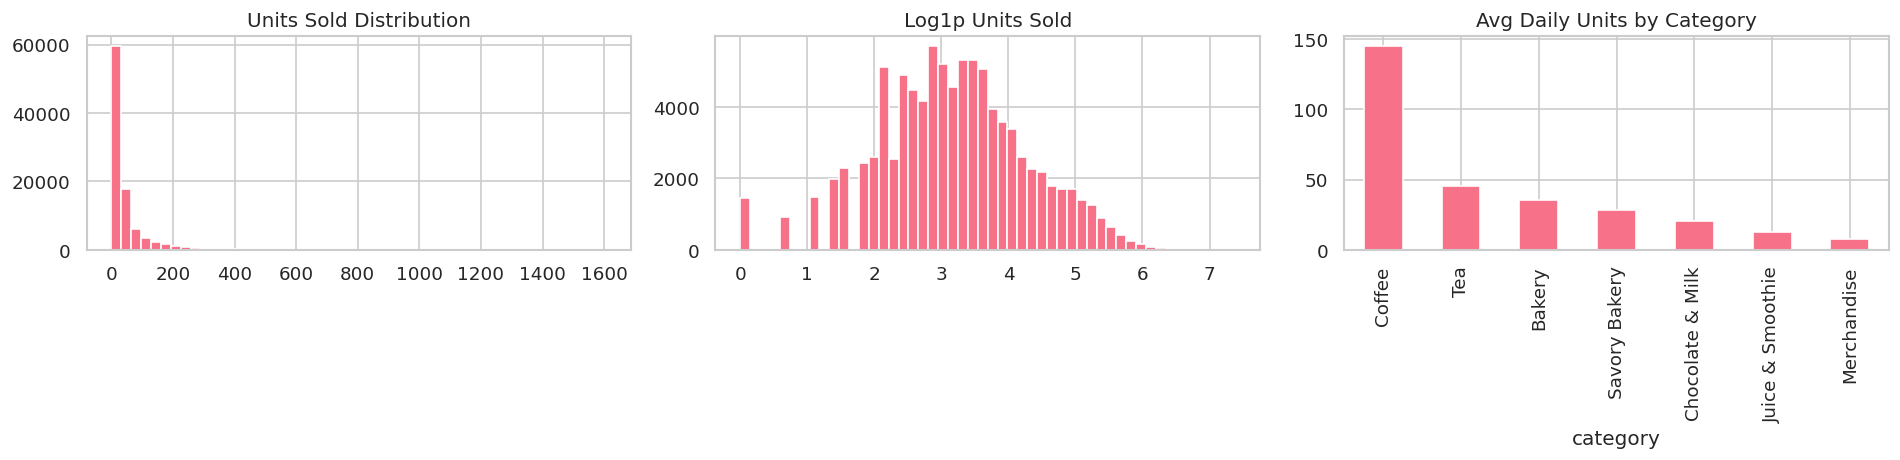

>> Heavy right skew. Coffee dominates. Use Tweedie/log1p.


In [3]:
# CELL 2 — [CHART 1] Target Distribution
fig, axes = plt.subplots(1,3,figsize=(16,4))
daily["units_sold"].hist(bins=50, ax=axes[0]); axes[0].set_title("Units Sold Distribution")
np.log1p(daily["units_sold"]).hist(bins=50, ax=axes[1]); axes[1].set_title("Log1p Units Sold")
daily.groupby("category")["units_sold"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[2]); axes[2].set_title("Avg Daily Units by Category")
plt.tight_layout(); plt.savefig("chart01_target_distribution.png"); plt.show()
print(">> Heavy right skew. Coffee dominates. Use Tweedie/log1p.")

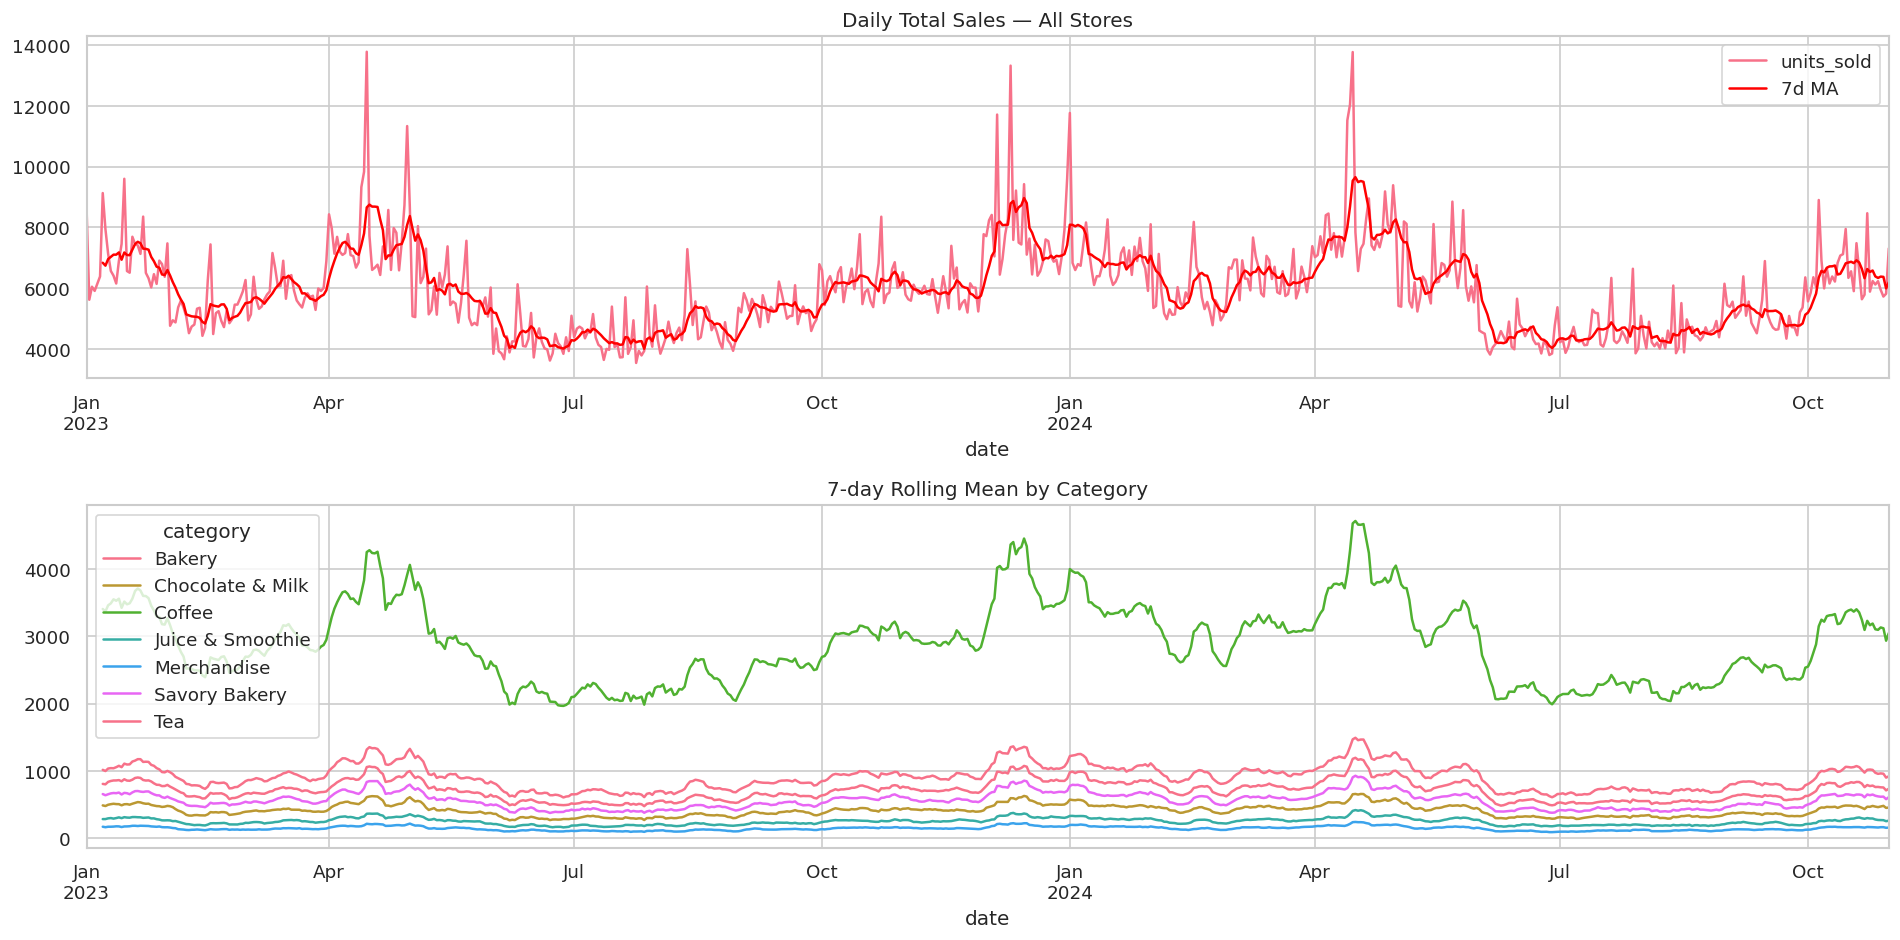

In [4]:
# CELL 3 — [CHART 2] Full Time Series Trend
daily_total = daily.groupby("date")["units_sold"].sum()
fig, axes = plt.subplots(2,1,figsize=(16,8))
daily_total.plot(ax=axes[0], title="Daily Total Sales — All Stores")
daily_total.rolling(7).mean().plot(ax=axes[0], color="red", label="7d MA")
axes[0].legend()
daily.groupby(["date","category"])["units_sold"].sum().unstack().rolling(7).mean().plot(
    ax=axes[1], title="7-day Rolling Mean by Category")
plt.tight_layout(); plt.savefig("chart02_timeseries.png"); plt.show()

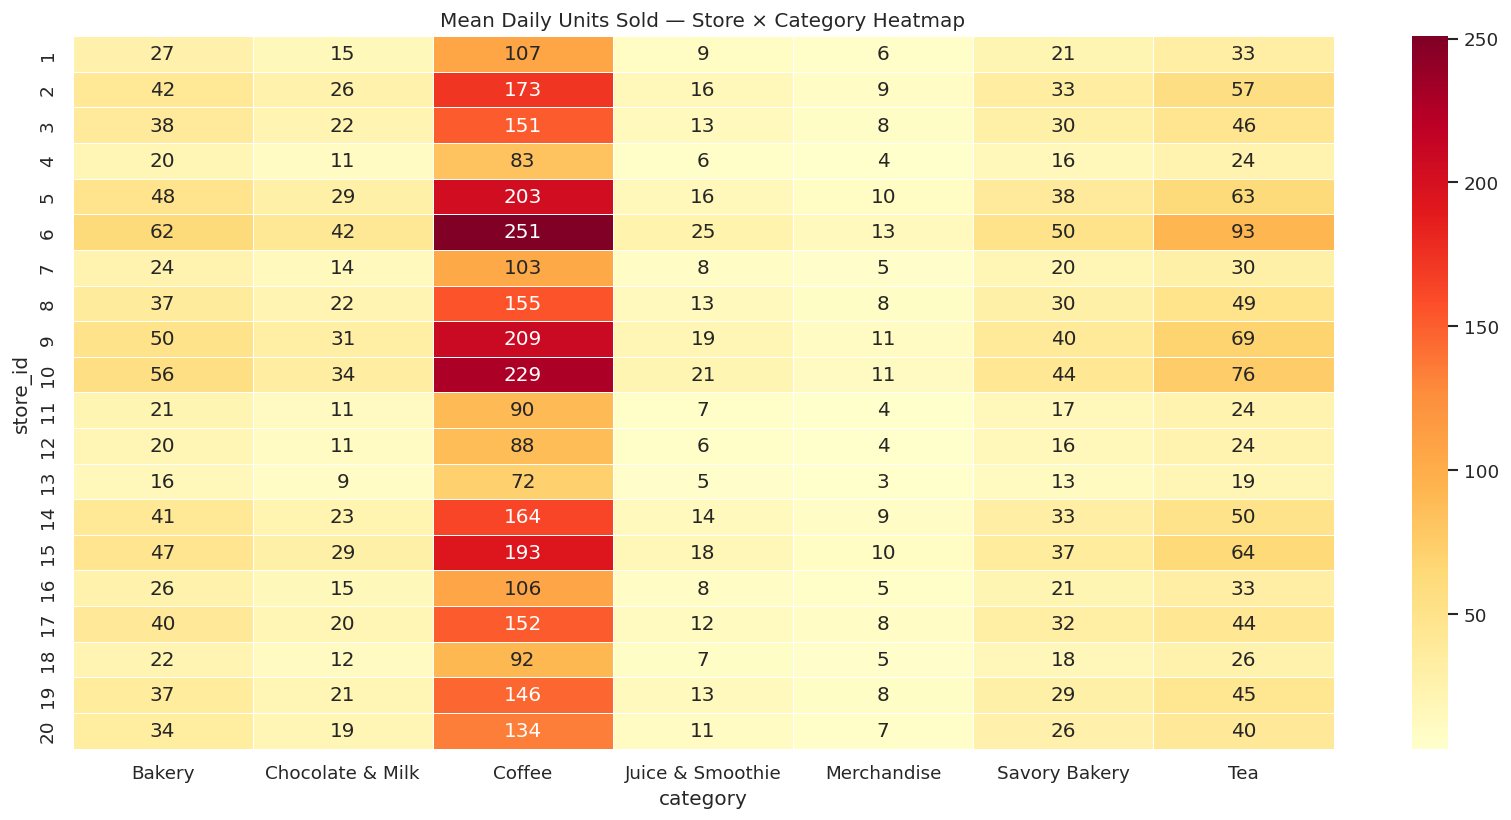

>> Identifies high-demand (store,category) cells for model weighting


In [5]:
# CELL 4 — [CHART 3] Store-level Heatmap
pivot = daily.groupby(["store_id","category"])["units_sold"].mean().unstack(fill_value=0)
plt.figure(figsize=(14,7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Mean Daily Units Sold — Store × Category Heatmap")
plt.tight_layout(); plt.savefig("chart03_store_category_heatmap.png"); plt.show()
print(">> Identifies high-demand (store,category) cells for model weighting")

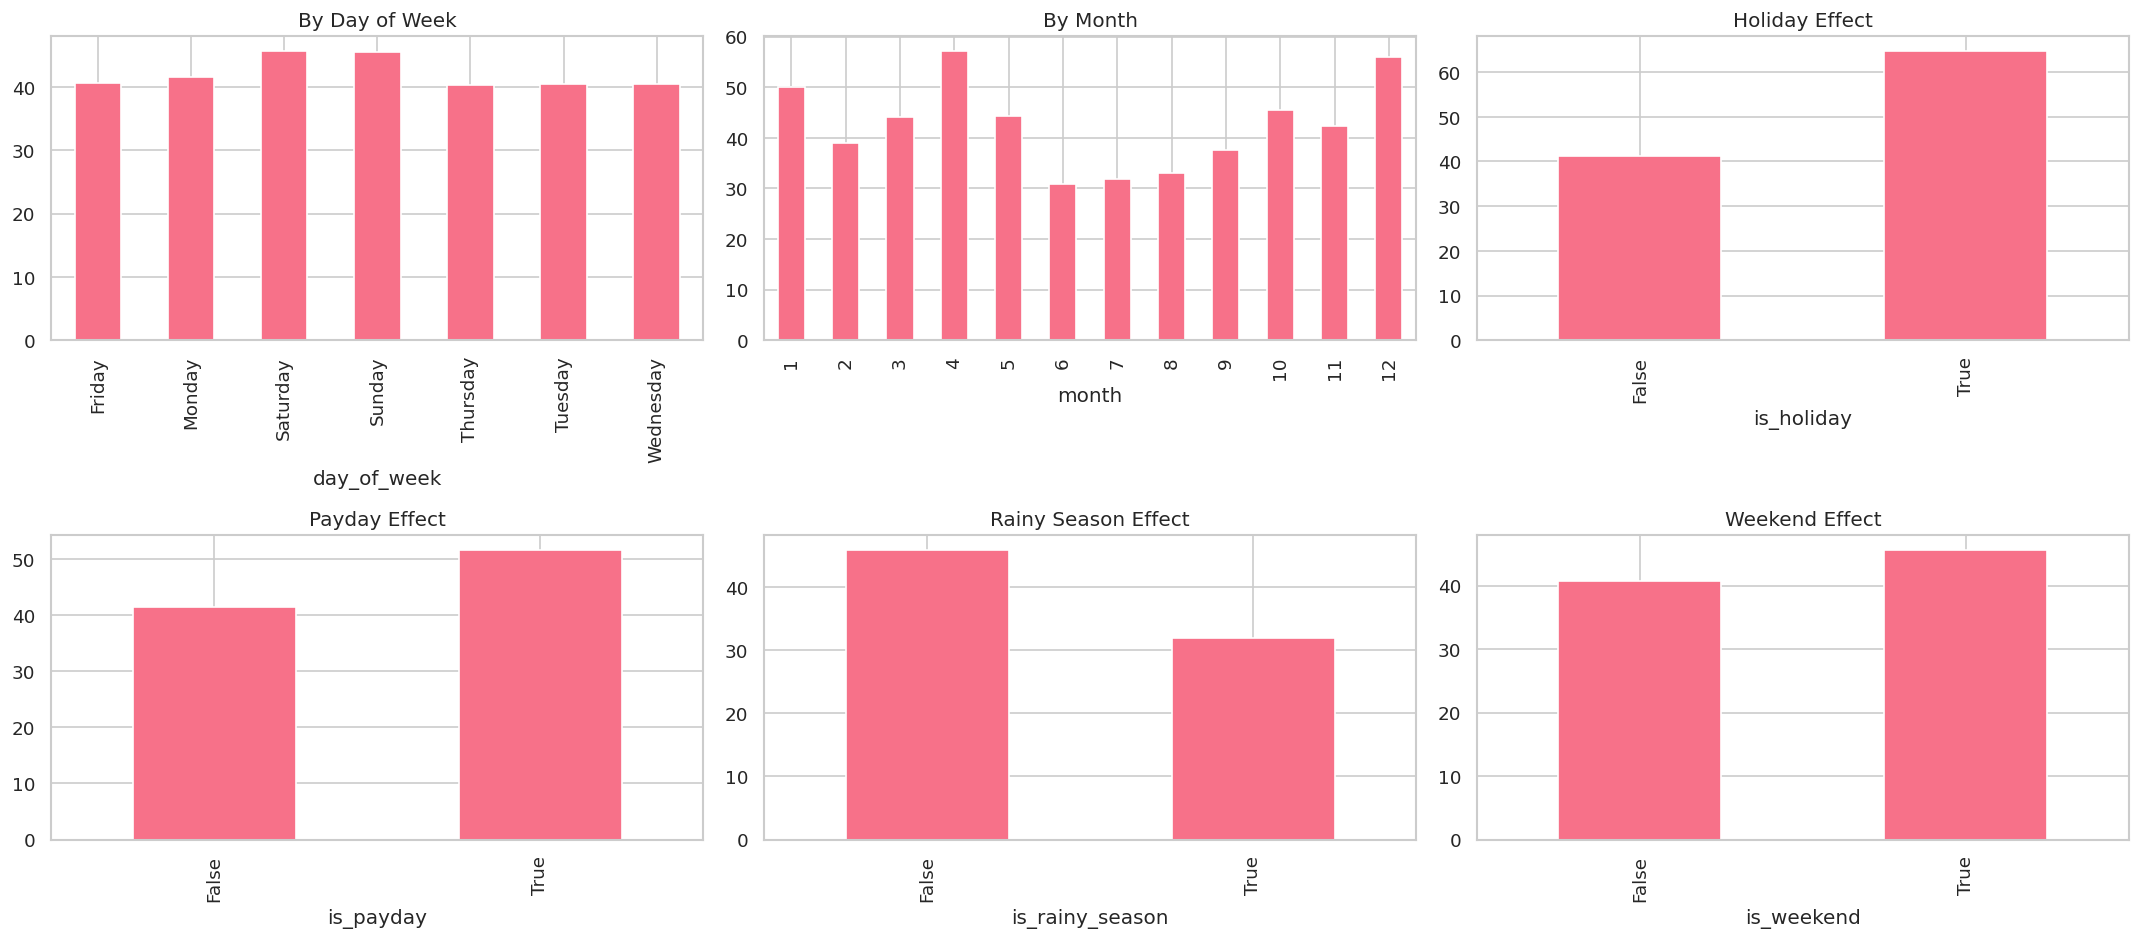

In [6]:
# CELL 5 — [CHART 4] Calendar Effects
fig, axes = plt.subplots(2,3,figsize=(18,8))
daily.groupby("day_of_week")["units_sold"].mean().plot(kind="bar",ax=axes[0,0],title="By Day of Week")
daily.groupby("month")["units_sold"].mean().plot(kind="bar",ax=axes[0,1],title="By Month")
for col,ax,lbl in [("is_holiday",axes[0,2],"Holiday"),("is_payday",axes[1,0],"Payday"),
                    ("is_rainy_season",axes[1,1],"Rainy Season"),("is_weekend",axes[1,2],"Weekend")]:
    daily.groupby(col)["units_sold"].mean().plot(kind="bar",ax=ax,title=f"{lbl} Effect")
plt.tight_layout(); plt.savefig("chart04_calendar_effects.png"); plt.show()

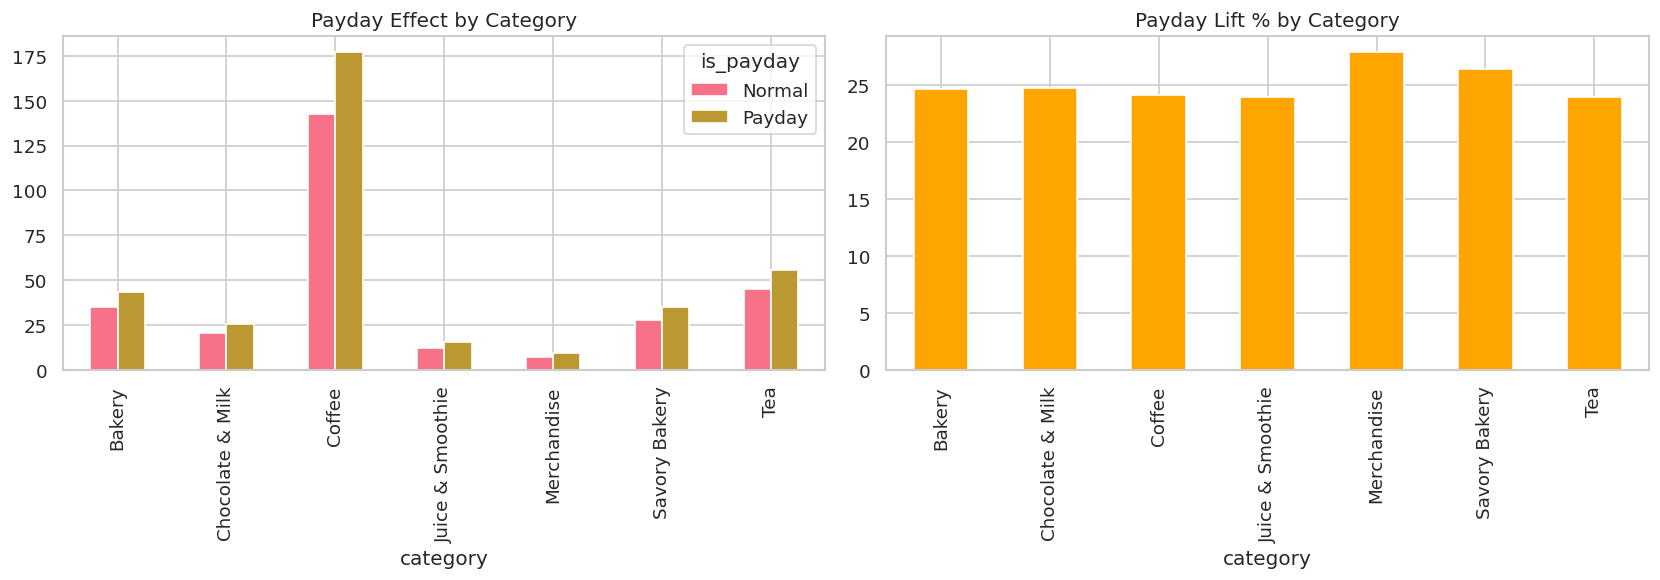

Payday lift by category:
category
Bakery              24.6
Chocolate & Milk    24.8
Coffee              24.2
Juice & Smoothie    23.9
Merchandise         27.9
Savory Bakery       26.4
Tea                 24.0
Name: Lift%, dtype: float64


In [7]:
# CELL 6 — [NEW CHART 5] Payday Effect by Category
payday_cat = (daily.groupby(["category","is_payday"])["units_sold"]
              .mean().unstack().rename(columns={False:"Normal",True:"Payday"}))
payday_cat["Lift%"] = (payday_cat["Payday"]-payday_cat["Normal"])/payday_cat["Normal"]*100
fig, axes = plt.subplots(1,2,figsize=(14,5))
payday_cat[["Normal","Payday"]].plot(kind="bar",ax=axes[0],title="Payday Effect by Category")
payday_cat["Lift%"].plot(kind="bar",ax=axes[1],color="orange",title="Payday Lift % by Category")
plt.tight_layout(); plt.savefig("chart05_payday_by_category.png"); plt.show()
print("Payday lift by category:"); print(payday_cat["Lift%"].round(1))

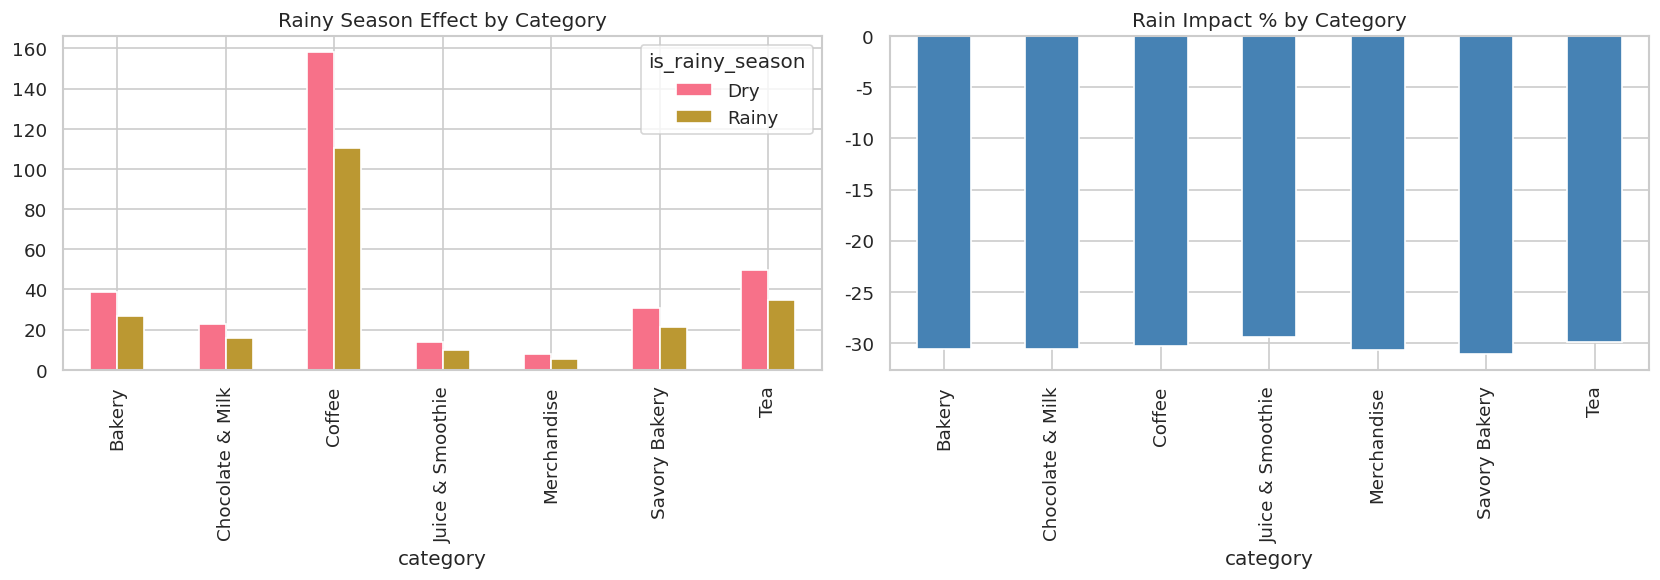

>> Hot drinks (Coffee/Chocolate) may rise in rainy season


In [8]:
# CELL 7 — [NEW CHART 6] Rainy Season × Category Interaction
rain_cat = (daily.groupby(["category","is_rainy_season"])["units_sold"]
            .mean().unstack().rename(columns={False:"Dry",True:"Rainy"}))
rain_cat["Impact%"] = (rain_cat["Rainy"]-rain_cat["Dry"])/rain_cat["Dry"]*100
fig, axes = plt.subplots(1,2,figsize=(14,5))
rain_cat[["Dry","Rainy"]].plot(kind="bar",ax=axes[0],title="Rainy Season Effect by Category")
rain_cat["Impact%"].plot(kind="bar",ax=axes[1],color="steelblue",title="Rain Impact % by Category")
plt.tight_layout(); plt.savefig("chart06_rainy_by_category.png"); plt.show()
print(">> Hot drinks (Coffee/Chocolate) may rise in rainy season")

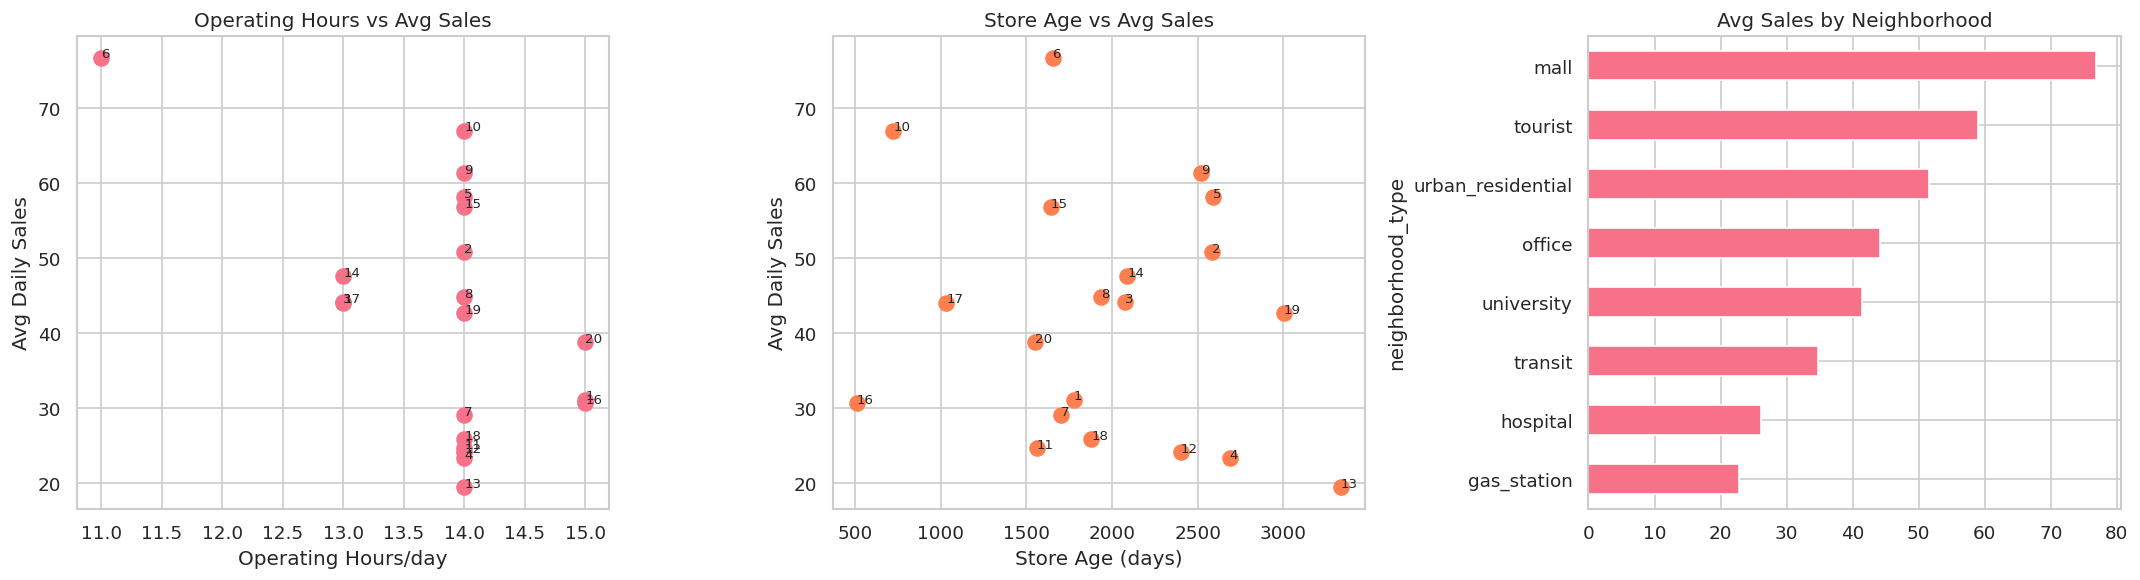

In [9]:
# CELL 8 — [NEW CHART 7] Operating Hours Effect
store["open_hour"] = store["open_time"].str.split(":").str[0].astype(int)
store["close_hour"] = store["close_time"].str.split(":").str[0].astype(int)
store["operating_hours"] = store["close_hour"] - store["open_hour"]
store["store_age_days"] = (pd.Timestamp("2024-10-31") - store["opened_date"]).dt.days

store_sales = daily.groupby("store_id")["units_sold"].mean().reset_index()
store_merged = store_sales.merge(store, on="store_id")

fig, axes = plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(store_merged["operating_hours"], store_merged["units_sold"], s=80)
for _, r in store_merged.iterrows():
    axes[0].annotate(r["store_id"], (r["operating_hours"], r["units_sold"]), fontsize=8)
axes[0].set_xlabel("Operating Hours/day"); axes[0].set_ylabel("Avg Daily Sales")
axes[0].set_title("Operating Hours vs Avg Sales")

axes[1].scatter(store_merged["store_age_days"], store_merged["units_sold"], s=80, c="coral")
for _, r in store_merged.iterrows():
    axes[1].annotate(r["store_id"], (r["store_age_days"], r["units_sold"]), fontsize=8)
axes[1].set_xlabel("Store Age (days)"); axes[1].set_ylabel("Avg Daily Sales")
axes[1].set_title("Store Age vs Avg Sales")

store_merged.groupby("neighborhood_type")["units_sold"].mean().sort_values().plot(
    kind="barh", ax=axes[2], title="Avg Sales by Neighborhood")
plt.tight_layout(); plt.savefig("chart07_store_profile.png"); plt.show()

## Calendar Deep Dive

These additional views use normalized demand (`units_rel`) so we can separate structural volume from true uplift or suppression.


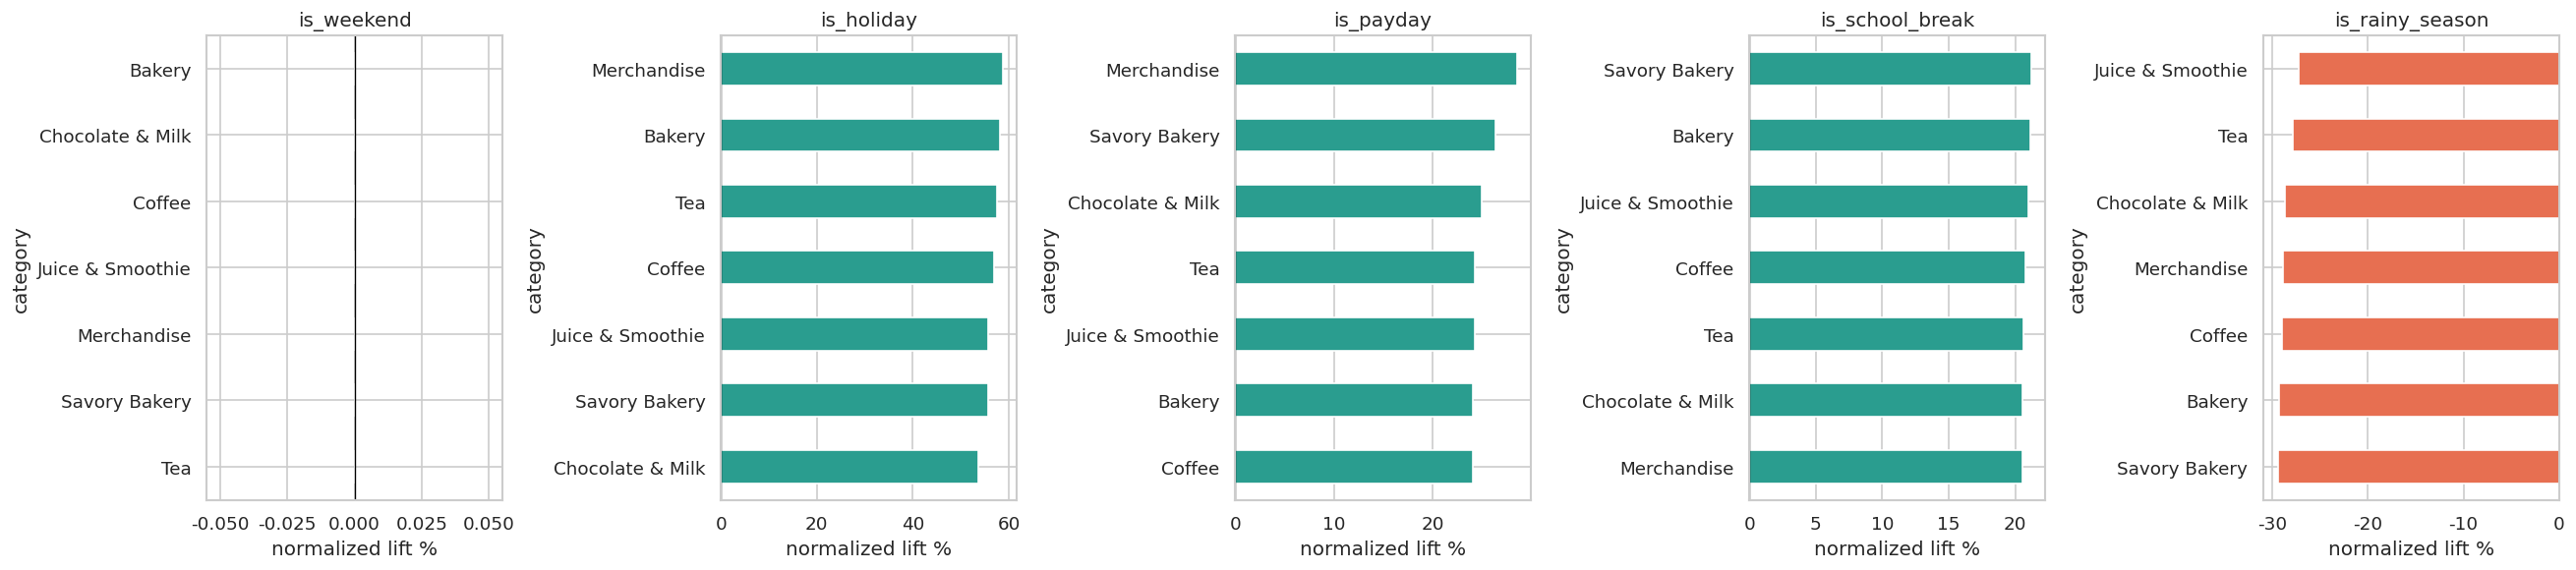

is_weekend,off,on,lift_pct
category,,,
Bakery,1.0,1.0,0.0
Chocolate & Milk,1.0,1.0,0.0
Coffee,1.0,1.0,0.0
Juice & Smoothie,1.0,1.0,0.0
Merchandise,1.0,1.0,0.0
Savory Bakery,1.0,1.0,0.0
Tea,1.0,1.0,0.0


is_holiday,off,on,lift_pct
category,,,
Merchandise,0.978,1.552,58.685
Bakery,0.978,1.547,58.210
Tea,0.978,1.540,57.458
Coffee,0.978,1.534,56.832
Juice & Smoothie,0.979,1.524,55.747
Savory Bakery,0.979,1.524,55.694
Chocolate & Milk,0.980,1.506,53.732


is_payday,off,on,lift_pct
category,,,
Merchandise,0.982,1.261,28.488
Savory Bakery,0.983,1.242,26.359
Chocolate & Milk,0.984,1.229,24.950
Tea,0.984,1.223,24.283
Juice & Smoothie,0.984,1.223,24.276
Bakery,0.984,1.221,24.053
Coffee,0.984,1.221,24.044


is_school_break,off,on,lift_pct
category,,,
Savory Bakery,0.928,1.124,21.191
Bakery,0.928,1.124,21.150
Juice & Smoothie,0.928,1.123,21.007
Coffee,0.929,1.122,20.797
Tea,0.930,1.121,20.624
Chocolate & Milk,0.930,1.121,20.559
Merchandise,0.930,1.121,20.538


is_rainy_season,off,on,lift_pct
category,,,
Juice & Smoothie,1.081,0.786,-27.239
Tea,1.083,0.781,-27.889
Chocolate & Milk,1.085,0.775,-28.641
Merchandise,1.086,0.773,-28.841
Coffee,1.086,0.772,-28.975
Bakery,1.087,0.769,-29.244
Savory Bakery,1.088,0.768,-29.444


In [10]:
flags = ["is_weekend", "is_holiday", "is_payday", "is_school_break", "is_rainy_season"]
fig, axes = plt.subplots(1, len(flags), figsize=(22, 5), sharex=False)
for flag, ax in zip(flags, axes):
    tab = lift_table(daily, flag)
    plot_lift(tab, flag, ax=ax)
plt.tight_layout()
plt.show()

for flag in flags:
    display(lift_table(daily, flag).round(3))

,holiday_name,category,rel_mean,raw_mean,dates
23,วันพ่อแห่งชาติ,Coffee,2.027738,293.900000,1
40,วันรัฐธรรมนูญ,Savory Bakery,2.024991,63.250000,1
35,วันรัฐธรรมนูญ,Bakery,2.017520,82.050000,1
49,วันสงกรานต์,Bakery,2.005078,72.158333,6
53,วันสงกรานต์,Merchandise,2.000570,14.708333,6
27,วันพ่อแห่งชาติ,Tea,1.998040,89.850000,1
41,วันรัฐธรรมนูญ,Tea,1.995581,104.700000,1
37,วันรัฐธรรมนูญ,Coffee,1.994931,324.550000,1
54,วันสงกรานต์,Savory Bakery,1.993434,56.358333,6
39,วันรัฐธรรมนูญ,Merchandise,1.991180,17.300000,1


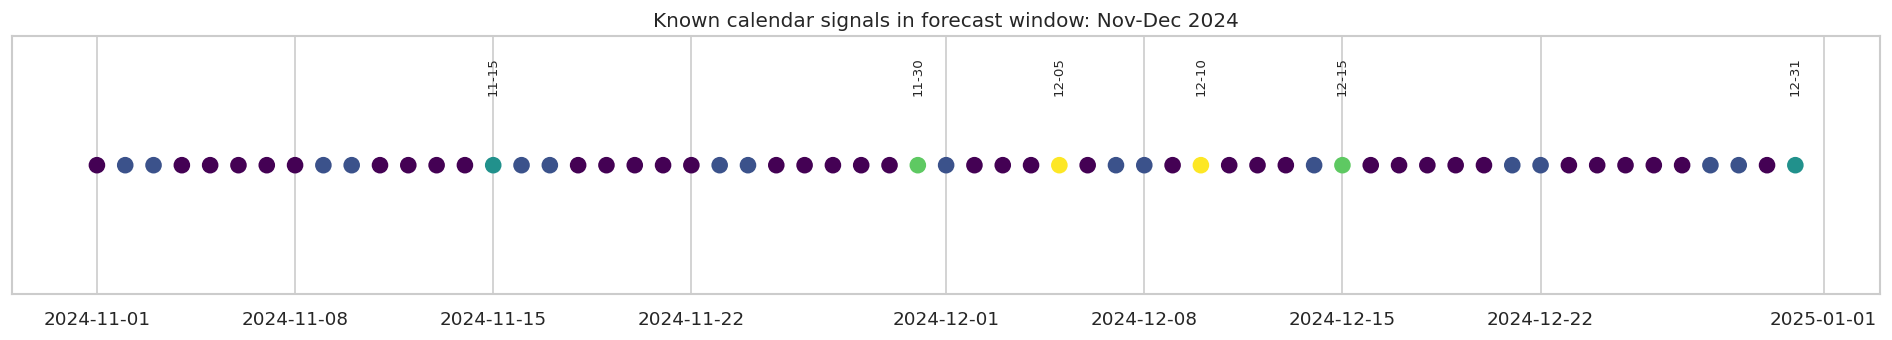

,date,day_of_week,is_holiday,holiday_name,is_payday
684,2024-11-15,Friday,False,NaN,True
699,2024-11-30,Saturday,False,NaN,True
704,2024-12-05,Thursday,True,วันพ่อแห่งชาติ,False
709,2024-12-10,Tuesday,True,วันรัฐธรรมนูญ,False
714,2024-12-15,Sunday,False,NaN,True
730,2024-12-31,Tuesday,False,NaN,True


In [11]:
holiday_lift = (
    daily[daily["is_holiday"]]
    .groupby(["holiday_name", "category"], observed=True)
    .agg(rel_mean=("units_rel", "mean"), raw_mean=("units_sold", "mean"), dates=("date", "nunique"))
    .reset_index()
    .sort_values("rel_mean", ascending=False)
)
display(holiday_lift.head(30))

forecast_window = test_date[(test_date["date"] >= "2024-11-01") & (test_date["date"] <= "2024-12-31")].copy()
known_signal_arr = (
    np.where(forecast_window["is_holiday"], "holiday", "")
    + np.where(forecast_window["is_payday"], "|payday", "")
    + np.where(forecast_window["is_weekend"], "|weekend", "")
)
forecast_window["known_signal"] = pd.Series(known_signal_arr, index=forecast_window.index).str.strip("|")

plt.figure(figsize=(16, 3))
signal_rank = {"": 0, "weekend": 1, "payday": 2, "payday|weekend": 3, "holiday": 4, "holiday|weekend": 5}
tmp = forecast_window.assign(signal_score=forecast_window["known_signal"].map(signal_rank).fillna(1))
plt.scatter(tmp["date"], np.ones(len(tmp)), c=tmp["signal_score"], cmap="viridis", s=80)
for _, r in tmp[tmp["is_holiday"] | tmp["is_payday"]].iterrows():
    plt.text(r["date"], 1.03, r["date"].strftime("%m-%d"), rotation=90, ha="center", va="bottom", fontsize=8)
plt.yticks([])
plt.title("Known calendar signals in forecast window: Nov-Dec 2024")
plt.tight_layout()
plt.show()

display(forecast_window.loc[forecast_window["is_holiday"] | forecast_window["is_payday"], ["date", "day_of_week", "is_holiday", "holiday_name", "is_payday"]])

## Promotion and Event Analysis

This block keeps the original promotion and event charts, then adds normalized promotion and event diagnostics from the deep-dive notebook.


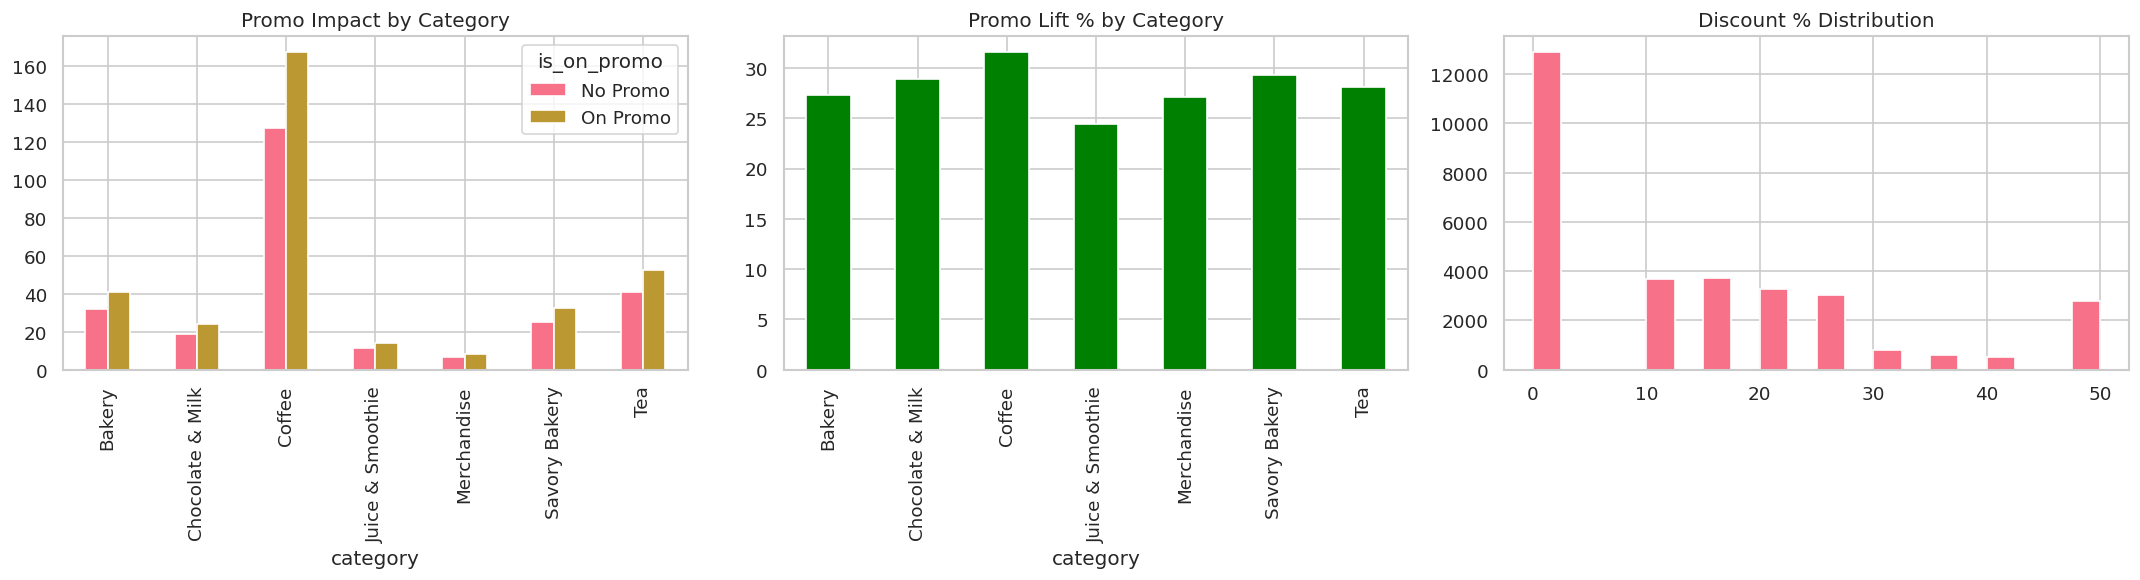

Promo lift by category:
category
Bakery              27.3
Chocolate & Milk    28.9
Coffee              31.6
Juice & Smoothie    24.4
Merchandise         27.1
Savory Bakery       29.3
Tea                 28.2
Name: Lift%, dtype: float64


In [12]:
# CELL 9 — [CHART 8] Promotion Analysis
promo_cat = promo.merge(prod[["product_id","category"]], on="product_id")
records = []
for _, r in promo_cat.iterrows():
    for d in pd.date_range(r["start_date"], r["end_date"], freq="D"):
        records.append({"store_id":r["store_id"],"category":r["category"],"date":d,
                        "discount_pct":r["discount_pct"],"promo_type":r["promo_type"]})
pf = pd.DataFrame(records)
pf["date"] = pd.to_datetime(pf["date"])
pf_agg = pf.groupby(["store_id","category","date"]).agg(
    max_discount=("discount_pct","max"), is_on_promo=("discount_pct",lambda x:1)).reset_index()

daily2 = daily.merge(pf_agg, on=["store_id","category","date"], how="left")
daily2["is_on_promo"] = daily2["is_on_promo"].fillna(0)
daily2["max_discount"] = daily2["max_discount"].fillna(0)

promo_effect = (daily2.groupby(["category","is_on_promo"])["units_sold"]
                .mean().unstack().rename(columns={0.0:"No Promo",1.0:"On Promo"}))
promo_effect["Lift%"] = (promo_effect["On Promo"]-promo_effect["No Promo"])/promo_effect["No Promo"]*100

fig, axes = plt.subplots(1,3,figsize=(18,5))
promo_effect[["No Promo","On Promo"]].plot(kind="bar",ax=axes[0],title="Promo Impact by Category")
promo_effect["Lift%"].plot(kind="bar",ax=axes[1],color="green",title="Promo Lift % by Category")
promo["discount_pct"].hist(bins=20,ax=axes[2]); axes[2].set_title("Discount % Distribution")
plt.tight_layout(); plt.savefig("chart08_promotion.png"); plt.show()
print("Promo lift by category:"); print(promo_effect["Lift%"].round(1))

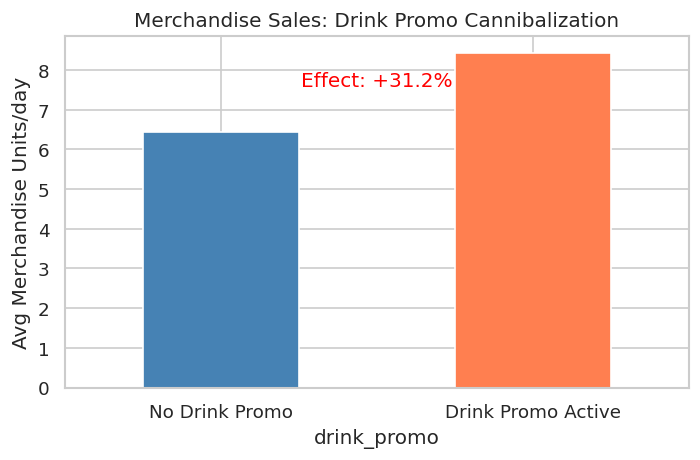

In [13]:
# CELL 10 — [NEW CHART 9] Promo Cannibalization
drink_promo = pf_agg[pf_agg["category"].isin(["Coffee","Tea"])][["store_id","date"]].drop_duplicates()
drink_promo["drink_promo"] = 1
merch = daily2[daily2["category"]=="Merchandise"].copy()
merch = merch.merge(drink_promo, on=["store_id","date"], how="left")
merch["drink_promo"] = merch["drink_promo"].fillna(0)
cann = merch.groupby("drink_promo")["units_sold"].mean()
plt.figure(figsize=(6,4))
cann.plot(kind="bar", color=["steelblue","coral"], title="Merchandise Sales: Drink Promo Cannibalization")
plt.xticks([0,1],["No Drink Promo","Drink Promo Active"], rotation=0)
plt.ylabel("Avg Merchandise Units/day")
if 0.0 in cann.index and 1.0 in cann.index:
    drop = (cann[1.0]-cann[0.0])/cann[0.0]*100
    plt.text(0.5,max(cann)*0.9,f"Effect: {drop:+.1f}%",ha="center",fontsize=12,color="red")
plt.tight_layout(); plt.savefig("chart09_cannibalization.png"); plt.show()

Event uplift: No event=39.9 | Has event=63.1


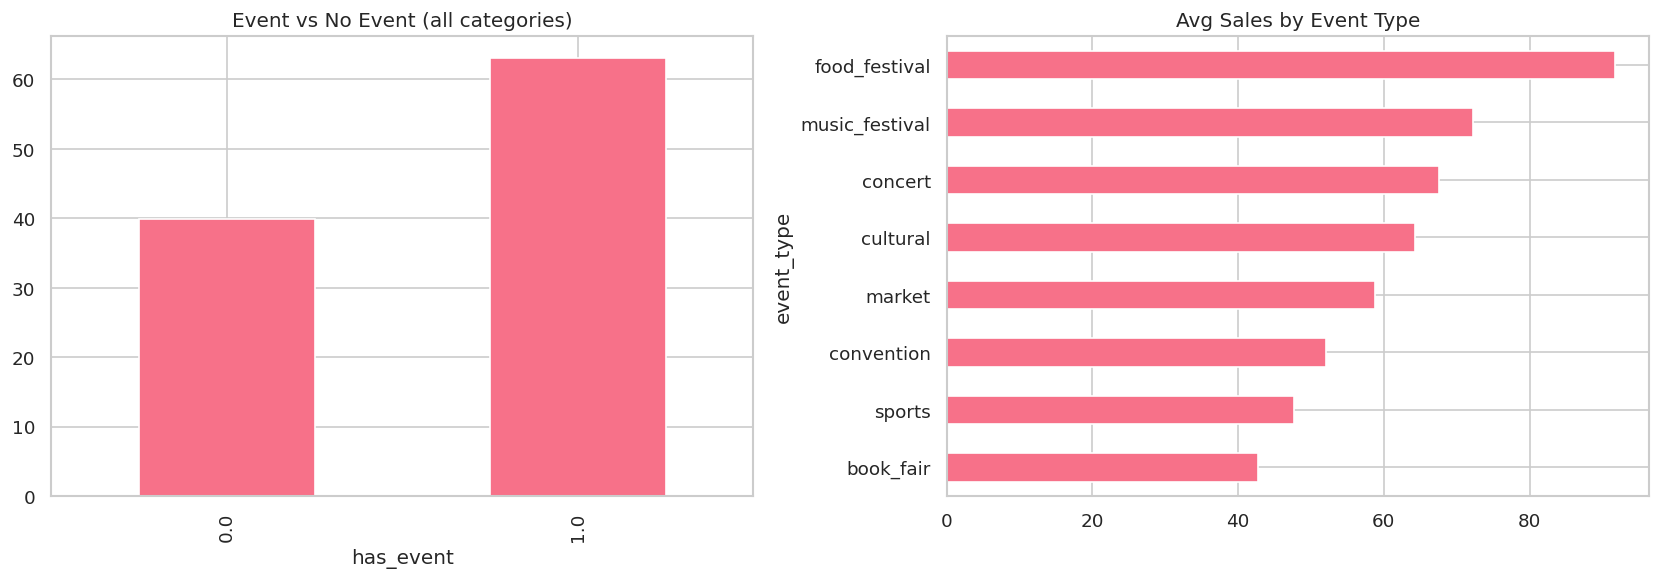

In [14]:
# CELL 11 — [CHART 10] Local Events Analysis
ev_daily = event.groupby(["store_id","date"]).agg(
    has_event=("event_id","count"),
    event_type=("event_type","first")).reset_index()
ev_daily["has_event"] = (ev_daily["has_event"]>0).astype(int)

daily3 = daily.merge(ev_daily, on=["store_id","date"], how="left")
daily3["has_event"] = daily3["has_event"].fillna(0)

ev_effect = daily3.groupby("has_event")["units_sold"].mean()
print(f"Event uplift: No event={ev_effect.get(0,0):.1f} | Has event={ev_effect.get(1,0):.1f}")

fig, axes = plt.subplots(1,2,figsize=(14,5))
ev_effect.plot(kind="bar",ax=axes[0],title="Event vs No Event (all categories)")
daily3.groupby("event_type")["units_sold"].mean().sort_values().dropna().plot(
    kind="barh",ax=axes[1],title="Avg Sales by Event Type")
plt.tight_layout(); plt.savefig("chart10_events.png"); plt.show()

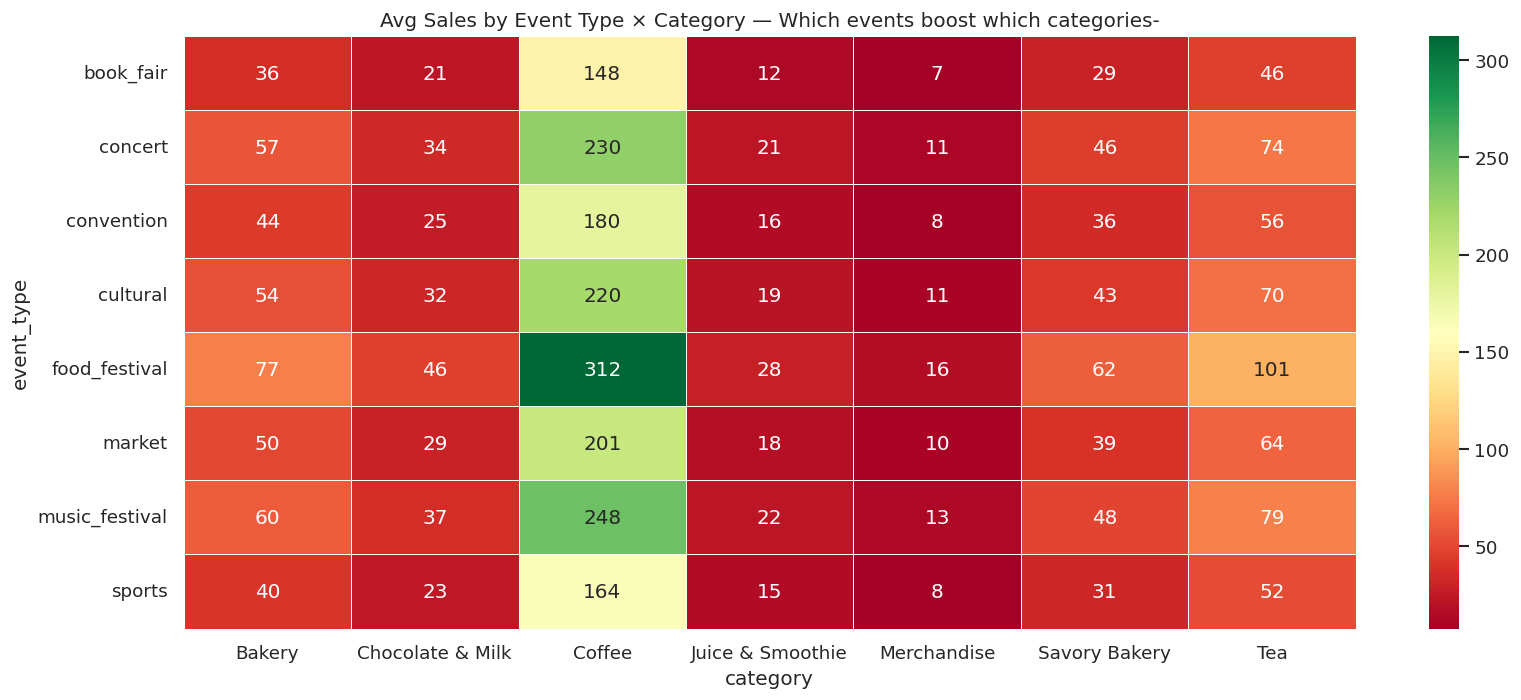

>> Food festivals boost Coffee+Bakery. Cultural events → Tea. Sports → portable Bakery.


In [15]:
# CELL 12 — [NEW CHART 11] Event Type × Category Cross
ev_cat = daily3[daily3["has_event"] == 1].copy()
ev_cross = ev_cat.groupby(["event_type","category"])["units_sold"].mean().unstack(fill_value=0)
plt.figure(figsize=(14,6))
sns.heatmap(ev_cross, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=0.5)
plt.title("Avg Sales by Event Type × Category — Which events boost which categories-")
plt.tight_layout(); plt.savefig("chart11_event_category_cross.png"); plt.show()
print(">> Food festivals boost Coffee+Bakery. Cultural events → Tea. Sports → portable Bakery.")

has_promo,off,on,lift_pct
category,,,
Coffee,0.903,1.121,24.153
Bakery,0.923,1.120,21.313
Merchandise,0.925,1.122,21.249
Chocolate & Milk,0.923,1.118,21.081
Savory Bakery,0.927,1.117,20.570
Tea,0.926,1.106,19.438
Juice & Smoothie,0.941,1.106,17.503


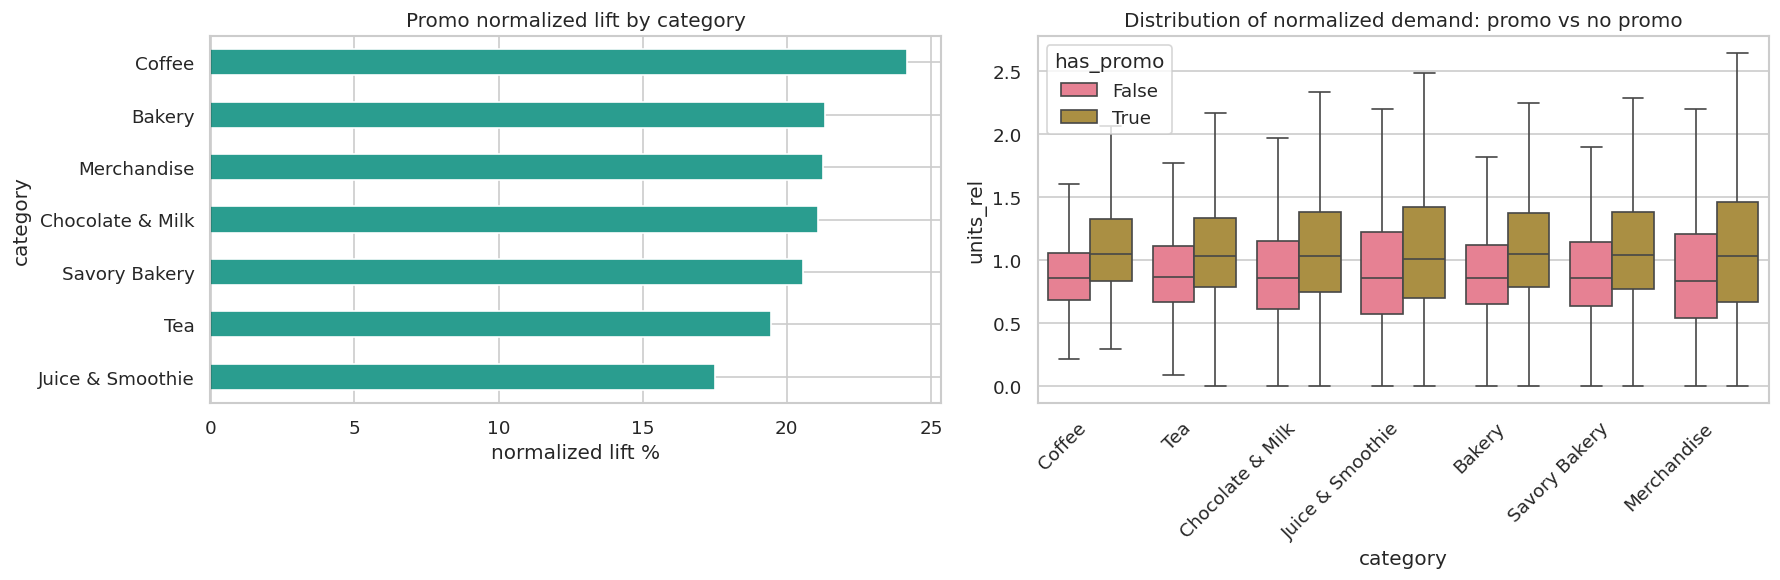

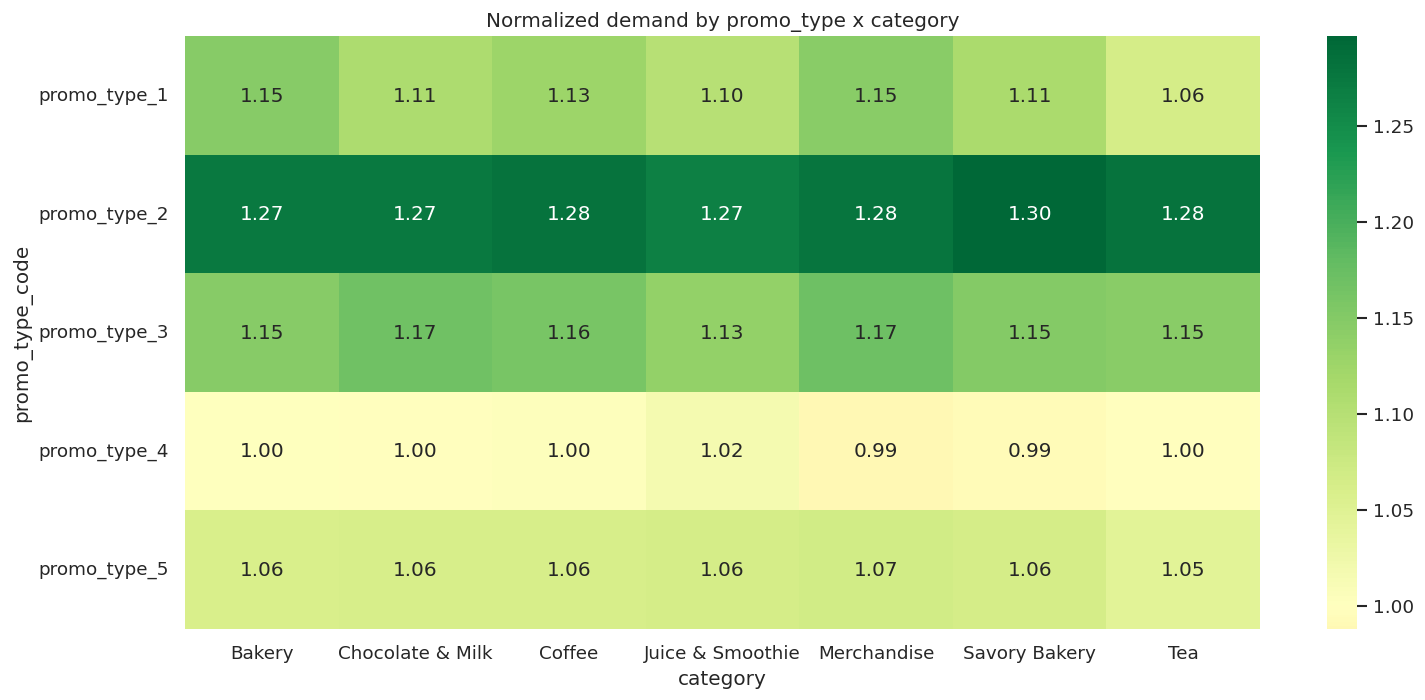

,promo_type_code,promo_type_raw
0,promo_type_1,ชุดคู่ลด
1,promo_type_2,ซื้อ1แถม1
2,promo_type_3,ลดราคา
3,promo_type_4,สมาชิกใหม่
4,promo_type_5,แต้มx2


,train_promo_rate,forecast_promo_rate,pp_change
category,,,
Bakery,39.22,32.21,-701.08
Chocolate & Milk,39.57,35.98,-359.10
Coffee,44.33,38.20,-613.16
Juice & Smoothie,35.64,30.16,-547.79
Merchandise,38.08,31.07,-701.65
Savory Bakery,38.51,34.84,-367.89
Tea,40.86,34.18,-667.79


drink_promo_active,off,on,lift_pct
neighborhood_type,,,
tourist,0.882,1.113,26.213
urban_residential,0.891,1.125,26.205
office,0.894,1.126,25.958
mall,0.899,1.113,23.693
hospital,0.918,1.124,22.365
university,0.904,1.105,22.323
gas_station,0.914,1.115,21.917
transit,0.936,1.095,16.939


In [16]:
promo_daily = expand_promo(promo, prod)
daily_promo = daily.merge(promo_daily, on=["store_id", "category", "date"], how="left")
daily_promo["has_promo"] = daily_promo["has_promo"].fillna(0).gt(0)
daily_promo["max_discount"] = daily_promo["max_discount"].fillna(0)

promo_lift = lift_table(daily_promo, "has_promo")
display(promo_lift.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_lift(promo_lift, "Promo normalized lift by category", ax=axes[0])
sns.boxplot(data=daily_promo, x="category", y="units_rel", hue="has_promo", ax=axes[1], showfliers=False)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha="right")
axes[1].set_title("Distribution of normalized demand: promo vs no promo")
plt.tight_layout()
plt.show()

promo_type_long = (
    daily_promo[daily_promo["has_promo"]]
    .assign(promo_type=daily_promo["promo_type"].fillna("").str.split("|"))
    .explode("promo_type")
)
promo_type_values = sorted(v for v in promo_type_long["promo_type"].dropna().unique() if v)
promo_type_code_map = {v: f"promo_type_{i+1}" for i, v in enumerate(promo_type_values)}
promo_type_long["promo_type_display"] = promo_type_long["promo_type"].map(promo_type_code_map).fillna("promo_type_other")
promo_type_heat = heatmap_table(promo_type_long, "promo_type_display", "category", "units_rel", min_count=20)
plt.figure(figsize=(13, 6))
sns.heatmap(promo_type_heat, annot=True, fmt=".2f", cmap="RdYlGn", center=1)
plt.title("Normalized demand by promo_type x category")
plt.xlabel("category")
plt.ylabel("promo_type_code")
plt.tight_layout()
plt.show()
display(
    pd.DataFrame(
        {
            "promo_type_code": list(promo_type_code_map.values()),
            "promo_type_raw": list(promo_type_code_map.keys()),
        }
    )
)

forecast_promo_daily = expand_promo(test_promo, prod)
train_rate = (
    promo_daily[promo_daily["date"].between(order["date"].min(), order["date"].max())]
    .groupby("category", observed=True)
    .size()
    / (store["store_id"].nunique() * daily["date"].nunique())
)
test_rate = (
    forecast_promo_daily[forecast_promo_daily["date"].between("2024-11-01", "2024-12-31")]
    .groupby("category", observed=True)
    .size()
    / (store["store_id"].nunique() * 61)
)
promo_drift = pd.concat([train_rate.rename("train_promo_rate"), test_rate.rename("forecast_promo_rate")], axis=1).fillna(0)
promo_drift["pp_change"] = (promo_drift["forecast_promo_rate"] - promo_drift["train_promo_rate"]) * 100
display((promo_drift * 100).round(2))

drink_promo_dates = daily_promo.loc[
    daily_promo["has_promo"] & daily_promo["category"].isin(["Coffee", "Tea"]),
    ["store_id", "date"],
].drop_duplicates()
drink_promo_dates["drink_promo_active"] = True
merch = daily_promo[daily_promo["category"].eq("Merchandise")].merge(drink_promo_dates, on=["store_id", "date"], how="left")
merch["drink_promo_active"] = merch["drink_promo_active"].fillna(False)
display(lift_table(merch, "drink_promo_active", by="neighborhood_type").round(3))


has_event,off,on,lift_pct
category,,,
Juice & Smoothie,0.953,1.454,52.660
Tea,0.954,1.438,50.618
Savory Bakery,0.955,1.435,50.317
Bakery,0.955,1.430,49.641
Chocolate & Milk,0.955,1.428,49.456
Coffee,0.956,1.424,48.971
Merchandise,0.958,1.401,46.188


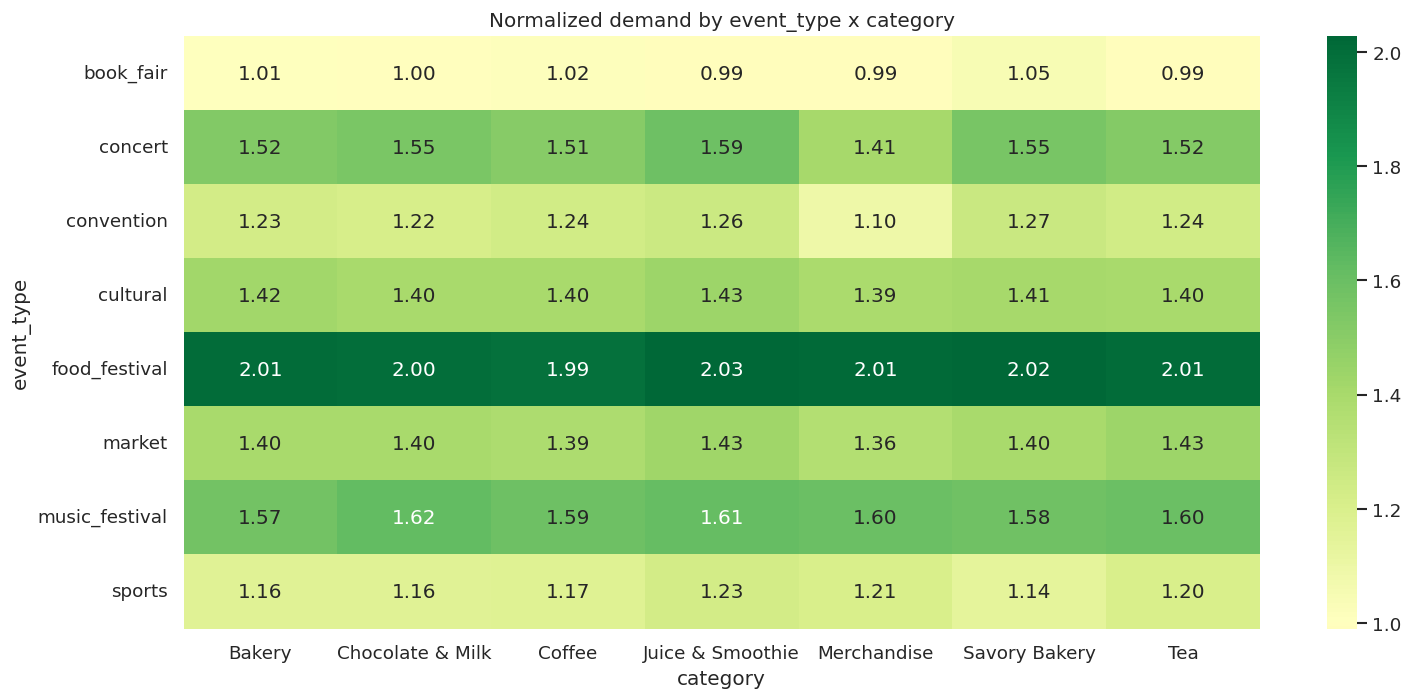

event_type
cultural          18
food_festival     16
market            14
book_fair         14
convention        13
concert           13
music_festival    13
sports            10
Name: forecast_event_count, dtype: int64

,event_id,store_id,date,event_name,event_type
755,756,1,2024-11-01,งาน Startup Expo,convention
1269,1270,2,2024-11-01,มิวสิคเฟสติวัล,music_festival
341,342,5,2024-11-01,มิวสิคเฟสติวัล,music_festival
8,9,6,2024-11-01,งาน Job Fair,convention
1215,1216,6,2024-11-02,งานบวช,cultural
953,954,12,2024-11-02,คอนเสิร์ตในสวน,concert
446,447,7,2024-11-06,เทศกาลกาแฟ,food_festival
1123,1124,10,2024-11-06,งาน Startup Expo,convention
17,18,13,2024-11-06,แข่งจักรยาน,sports
495,496,15,2024-11-06,งานวัดประจำปี,cultural


In [17]:
event_daily = (
    event.groupby(["store_id", "date"], observed=True)
    .agg(event_count=("event_id", "count"), event_type=("event_type", lambda s: "|".join(sorted(set(s)))))
    .reset_index()
)
daily_event = daily.merge(event_daily, on=["store_id", "date"], how="left")
daily_event["has_event"] = daily_event["event_count"].fillna(0).gt(0)

event_lift = lift_table(daily_event, "has_event")
display(event_lift.round(3))

event_long = (
    daily_event[daily_event["has_event"]]
    .assign(event_type=daily_event["event_type"].fillna("").str.split("|"))
    .explode("event_type")
)
event_type_heat = heatmap_table(event_long, "event_type", "category", "units_rel", min_count=10)
plt.figure(figsize=(13, 6))
sns.heatmap(event_type_heat, annot=True, fmt=".2f", cmap="RdYlGn", center=1)
plt.title("Normalized demand by event_type x category")
plt.tight_layout()
plt.show()

forecast_events = test_event[test_event["date"].between("2024-11-01", "2024-12-31")]
display(forecast_events.groupby("event_type").size().rename("forecast_event_count").sort_values(ascending=False))
display(forecast_events.sort_values(["date", "store_id"]).head(40))

## Customer, Store, and Operational Behavior

This section combines store profile, customer structure, neighborhood patterns, and hourly traffic behavior.


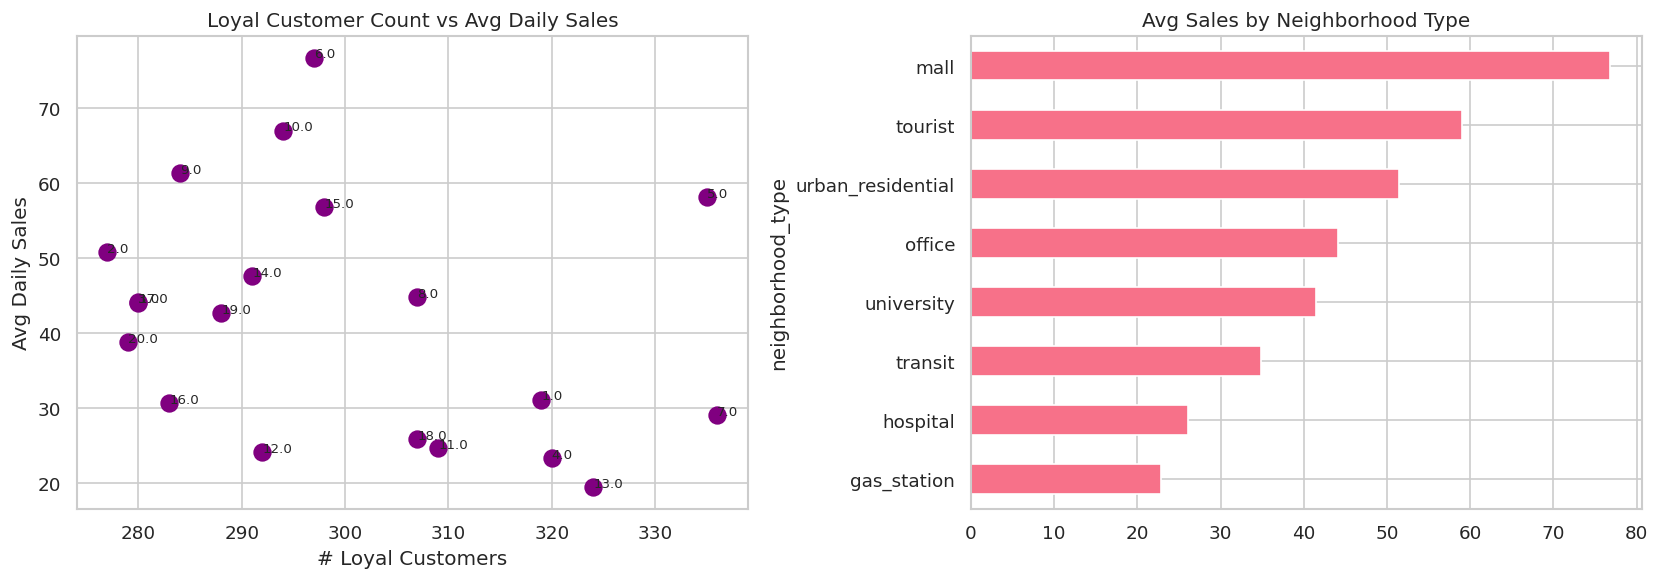

In [18]:
# CELL 13 — [CHART 12] Customer Analysis
member_ord = order.copy()
member_ord["is_member_order"] = member_ord["customer_id"].notna().astype(int)
member_daily = member_ord.groupby(["store_id","date"]).agg(
    member_orders=("is_member_order","sum"),
    total_orders=("order_id","count")).reset_index()
member_daily["member_ratio"] = member_daily["member_orders"]/member_daily["total_orders"]

loyal_count = cust.groupby("preferred_store_id")["customer_id"].count().reset_index()
loyal_count.columns = ["store_id","loyal_customers"]

store_total = daily.groupby("store_id")["units_sold"].mean().reset_index()
store_cust = store_total.merge(loyal_count, on="store_id", how="left")

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(store_cust["loyal_customers"], store_cust["units_sold"], s=100, c="purple")
for _,r in store_cust.iterrows():
    axes[0].annotate(r["store_id"],(r["loyal_customers"],r["units_sold"]),fontsize=8)
axes[0].set_xlabel("# Loyal Customers"); axes[0].set_ylabel("Avg Daily Sales")
axes[0].set_title("Loyal Customer Count vs Avg Daily Sales")

daily3.groupby("neighborhood_type")["units_sold"].mean().sort_values().plot(
    kind="barh",ax=axes[1],title="Avg Sales by Neighborhood Type")
plt.tight_layout(); plt.savefig("chart12_customer_analysis.png"); plt.show()

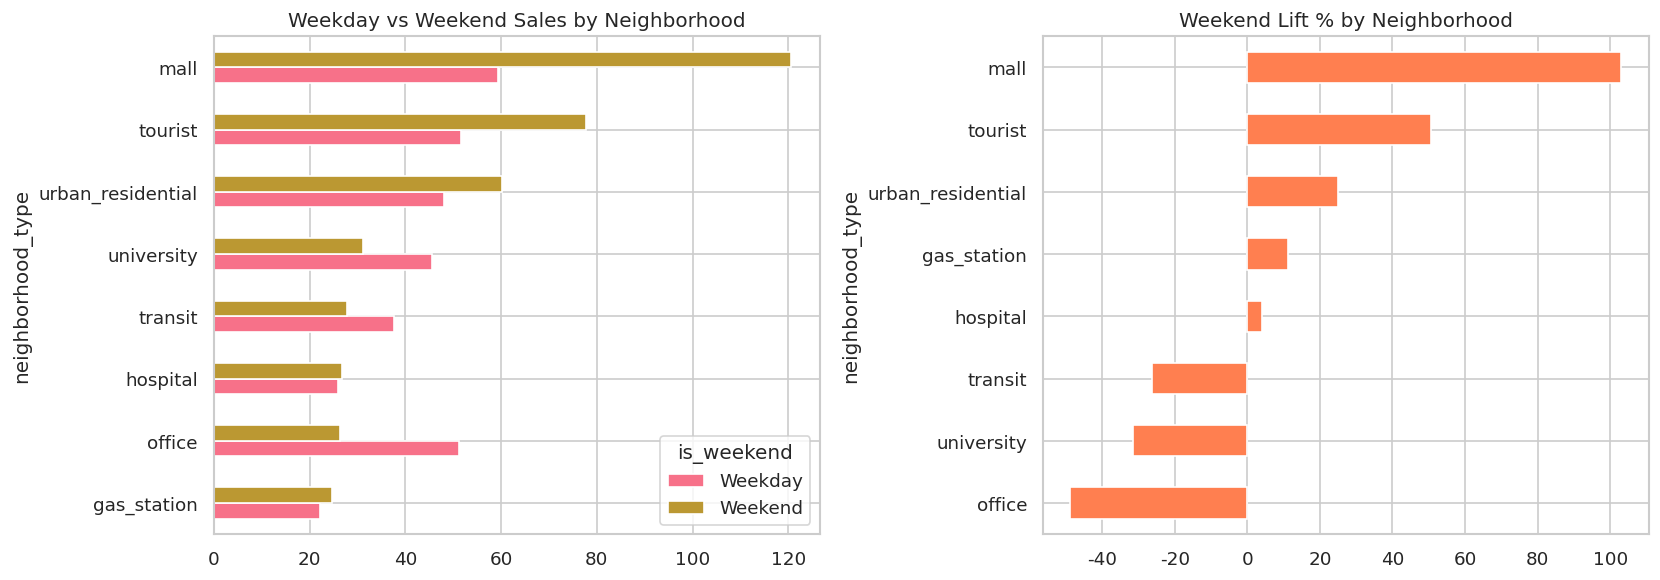

Weekend lift by neighborhood:
neighborhood_type
office               -48.7
university           -31.4
transit              -26.2
hospital               4.0
gas_station           11.3
urban_residential     25.0
tourist               50.6
mall                 103.0
Name: Weekend_Lift%, dtype: float64
>> Tourist stores: high weekend lift. Hospital/office: negative weekend effect.


In [19]:
# CELL 14 — [NEW CHART 13] Weekend Effect by Neighborhood
wkd_nbr = (daily.groupby(["neighborhood_type","is_weekend"])["units_sold"]
           .mean().unstack().rename(columns={False:"Weekday",True:"Weekend"}))
wkd_nbr["Weekend_Lift%"] = (wkd_nbr["Weekend"]-wkd_nbr["Weekday"])/wkd_nbr["Weekday"]*100
fig, axes = plt.subplots(1,2,figsize=(14,5))
wkd_nbr[["Weekday","Weekend"]].sort_values("Weekend").plot(kind="barh",ax=axes[0],
    title="Weekday vs Weekend Sales by Neighborhood")
wkd_nbr["Weekend_Lift%"].sort_values().plot(kind="barh",ax=axes[1],color="coral",
    title="Weekend Lift % by Neighborhood")
plt.tight_layout(); plt.savefig("chart13_weekend_by_neighborhood.png"); plt.show()
print("Weekend lift by neighborhood:"); print(wkd_nbr["Weekend_Lift%"].sort_values().round(1))
print(">> Tourist stores: high weekend lift. Hospital/office: negative weekend effect.")

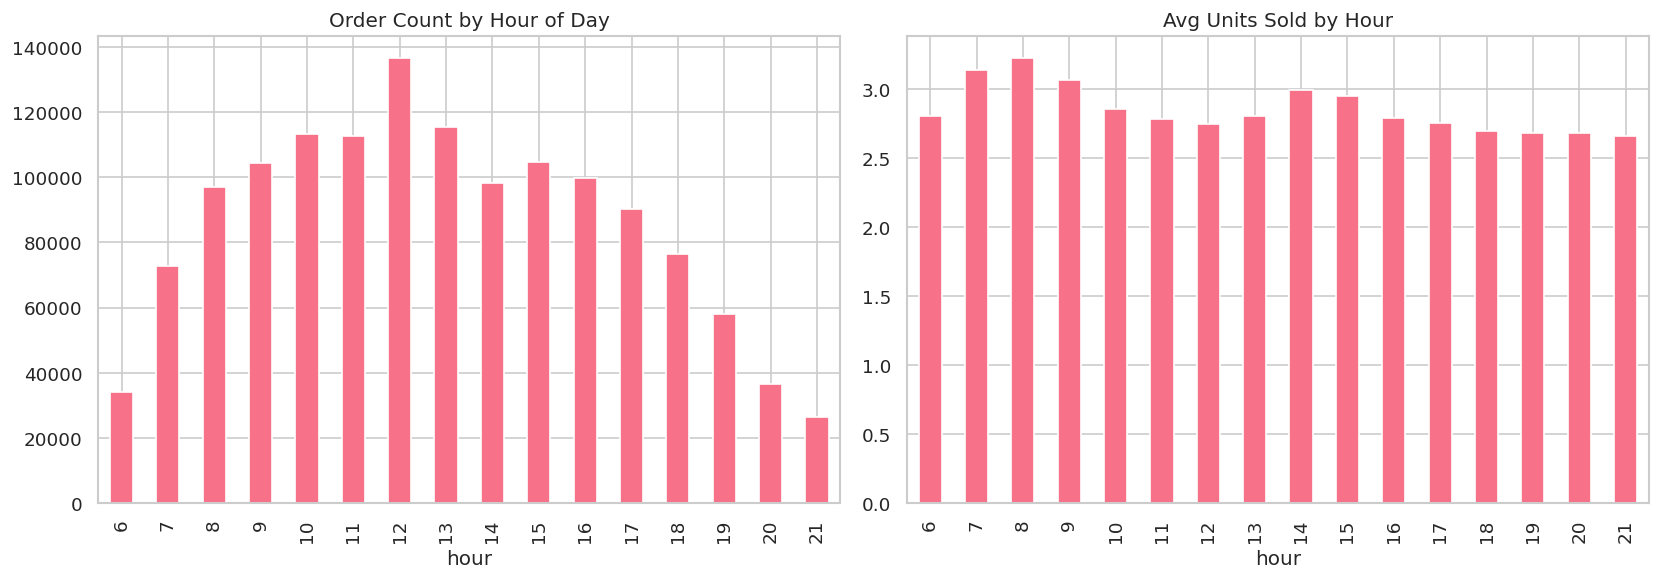

>> Morning rush 8-11am. Useful if predicting sub-daily or as store-capacity feature.


In [20]:
# CELL 20 — [NEW] Hour of Day Analysis
if "hour" in order.columns:
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    order.groupby("hour")["order_id"].count().plot(
        kind="bar",ax=axes[0],title="Order Count by Hour of Day")
    order.merge(txn.groupby("order_id")["units_sold"].sum().reset_index(),on="order_id").groupby(
        "hour")["units_sold"].mean().plot(kind="bar",ax=axes[1],title="Avg Units Sold by Hour")
    plt.tight_layout(); plt.savefig("chart18_hourly.png"); plt.show()
    print(">> Morning rush 8-11am. Useful if predicting sub-daily or as store-capacity feature.")

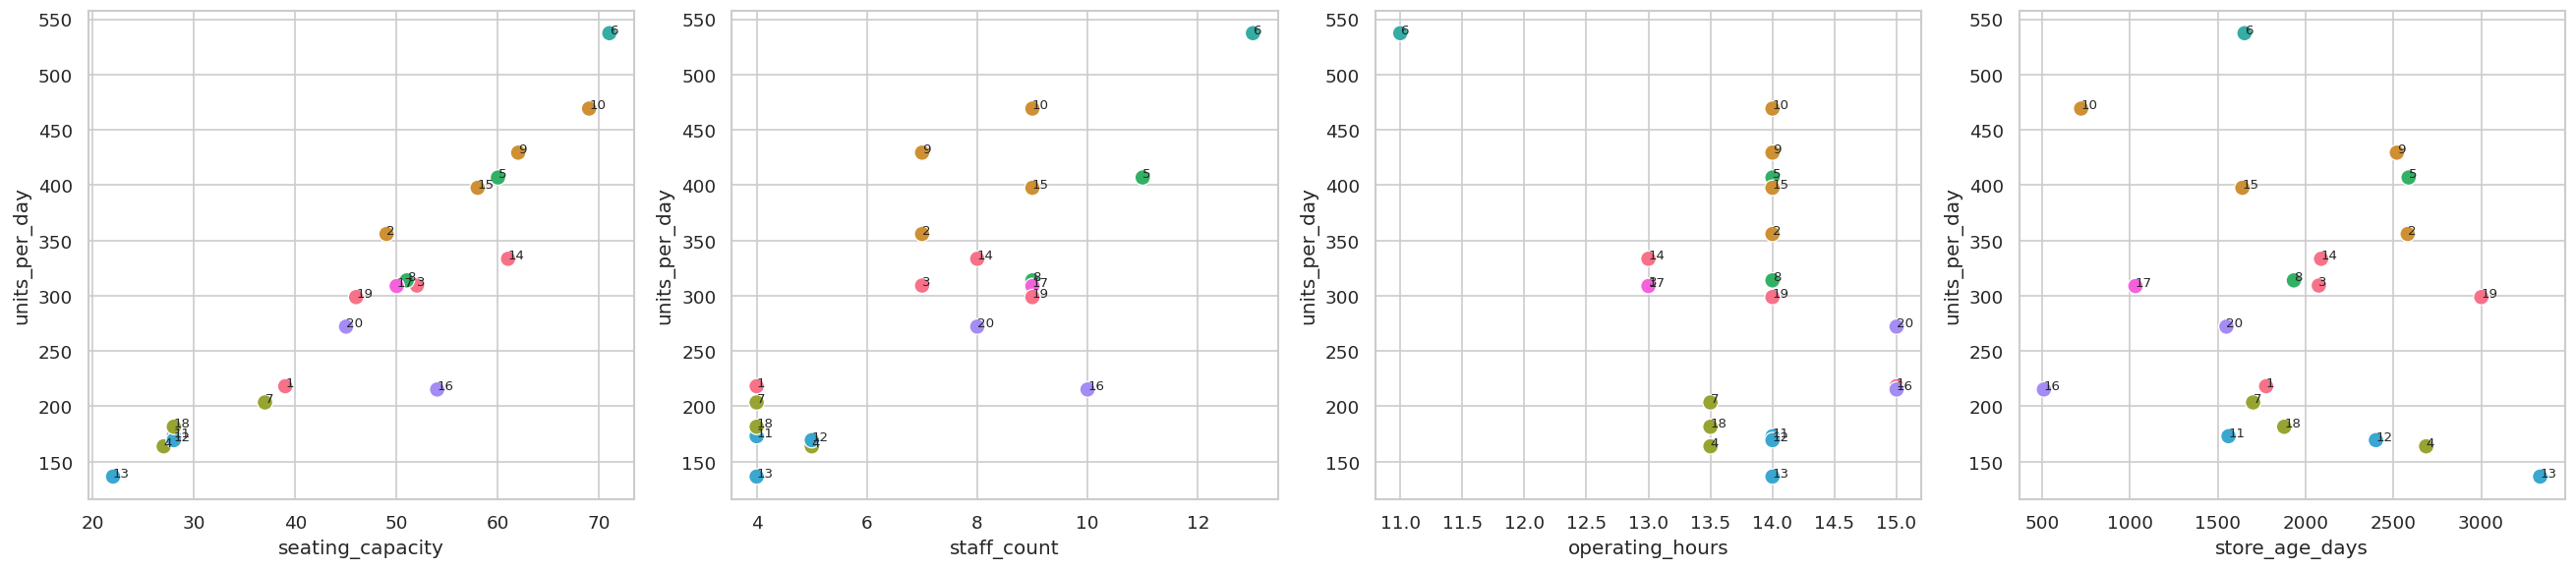

,store_id,neighborhood_type,units_per_day,rel_mean,seating_capacity,has_drive_through,staff_count,open_time,close_time,opened_date,open_hour,close_hour,operating_hours,store_age_days,units_per_staff_day,units_per_seat_day
5,6,mall,537.465672,1.0,71,False,13,10:00,21:00,2020-04-22,10.0,21.0,11.0,1653,41.343513,7.569939
9,10,tourist,469.279104,1.0,69,False,9,07:00,21:00,2022-11-08,7.0,21.0,14.0,723,52.142123,6.801146
8,9,tourist,429.443284,1.0,62,False,7,07:00,21:00,2017-12-07,7.0,21.0,14.0,2520,61.349041,6.926505
4,5,urban_residential,406.970149,1.0,60,False,11,06:00,20:00,2017-10-01,6.0,20.0,14.0,2587,36.997286,6.782836
14,15,tourist,397.652239,1.0,58,False,9,07:00,21:00,2020-05-04,7.0,21.0,14.0,1641,44.183582,6.856073
1,2,tourist,355.865672,1.0,49,False,7,07:00,21:00,2017-10-06,7.0,21.0,14.0,2582,50.837953,7.262565
13,14,university,333.438806,1.0,61,False,8,07:00,20:00,2019-02-11,7.0,20.0,13.0,2089,41.679851,5.466210
7,8,urban_residential,313.932836,1.0,51,False,9,07:00,21:00,2019-07-16,7.0,21.0,14.0,1934,34.881426,6.155546
2,3,university,309.252239,1.0,52,False,7,07:00,20:00,2019-02-24,7.0,20.0,13.0,2076,44.178891,5.947158
16,17,office,308.797015,1.0,50,False,9,07:00,20:00,2022-01-03,7.0,20.0,13.0,1032,34.310779,6.175940


In [21]:
store_profile = (
    daily.groupby(["store_id", "neighborhood_type"], observed=True)
    .agg(units_per_day=("units_sold", "sum"), rel_mean=("units_rel", "mean"))
    .reset_index()
)
store_profile["units_per_day"] /= daily["date"].nunique()

store_feat = store.copy()
store_feat["open_hour"] = store_feat["open_time"].str.slice(0, 2).astype(int) + store_feat["open_time"].str.slice(3, 5).astype(int) / 60
store_feat["close_hour"] = store_feat["close_time"].str.slice(0, 2).astype(int) + store_feat["close_time"].str.slice(3, 5).astype(int) / 60
store_feat["operating_hours"] = store_feat["close_hour"] - store_feat["open_hour"]
store_feat["store_age_days"] = (daily["date"].max() - store_feat["opened_date"]).dt.days

store_profile = store_profile.merge(store_feat, on=["store_id", "neighborhood_type"], how="left")
store_profile["units_per_staff_day"] = store_profile["units_per_day"] / store_profile["staff_count"]
store_profile["units_per_seat_day"] = store_profile["units_per_day"] / store_profile["seating_capacity"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for x, ax in zip(["seating_capacity", "staff_count", "operating_hours", "store_age_days"], axes):
    sns.scatterplot(data=store_profile, x=x, y="units_per_day", hue="neighborhood_type", s=90, ax=ax)
    for _, r in store_profile.iterrows():
        ax.text(r[x], r["units_per_day"], str(r["store_id"]), fontsize=8)
    ax.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

display(store_profile.sort_values("units_per_day", ascending=False))

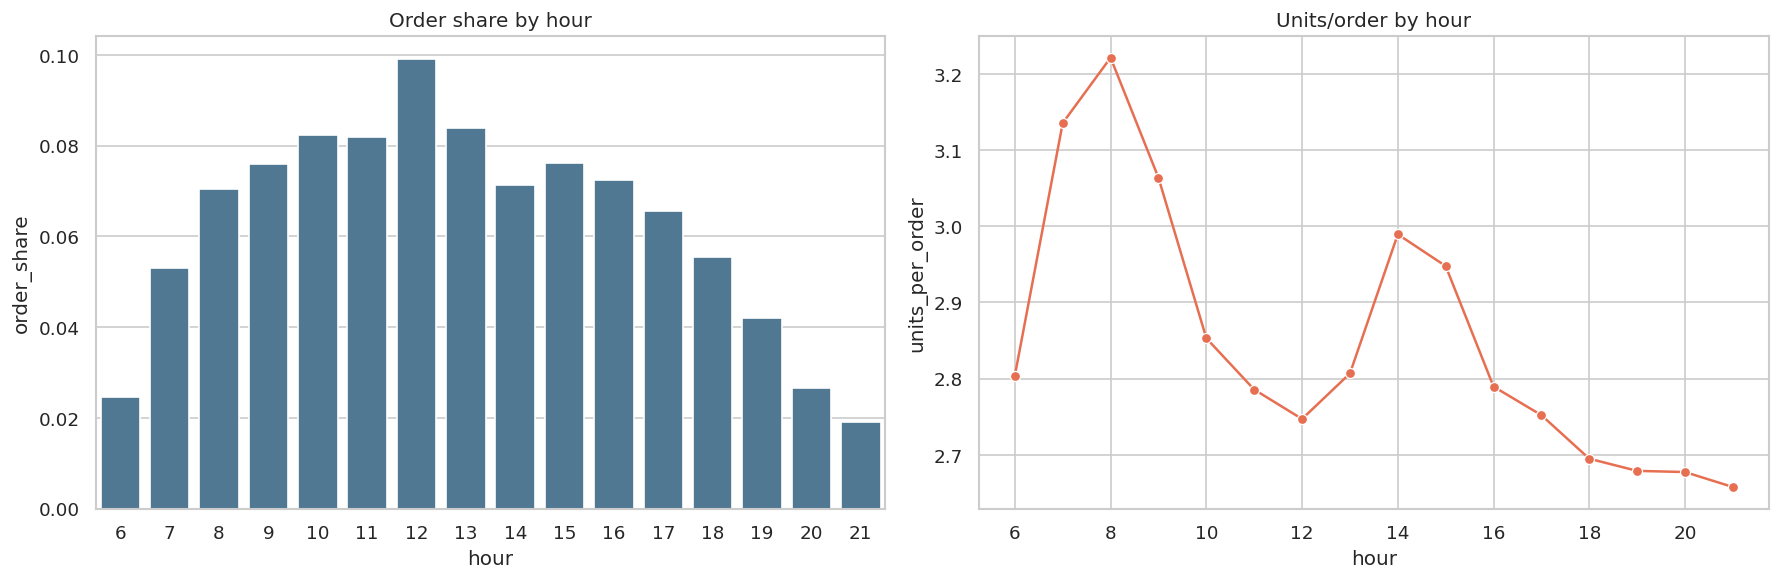

,neighborhood_type,hour,orders
1,gas_station,7,16842
2,gas_station,8,14498
3,gas_station,9,11848
18,hospital,8,13688
19,hospital,9,12477
22,hospital,12,12386
38,mall,12,14260
39,mall,13,13612
42,mall,16,12380
50,office,8,8282


,basket,orders
0,Coffee,469511
1,Tea,118280
2,Coffee + Tea,103102
3,Bakery + Coffee,84661
4,Coffee + Savory Bakery,58254
5,Chocolate & Milk,48068
6,Chocolate & Milk + Coffee,38755
7,Bakery,33172
8,Savory Bakery,27859
9,Juice & Smoothie,27542


,orders,units_per_order,revenue_per_order
segment,,,
member,550841,2.87185,152.309806
walk_in,825292,2.86858,152.068979


,orders,units_per_order,revenue_per_order
payment_method,,,
QR/PromptPay,530266,2.879481,152.756595
กระเป๋าเงินดิจิทัล,383558,2.901134,153.984754
บัตรเครดิต,294278,2.849537,150.714693
เงินสด,168031,2.803941,148.687246


In [22]:
hour_profile = (
    line.groupby(["hour"], observed=True)
    .agg(orders=("order_id", "nunique"), units=("units_sold", "sum"), revenue=("revenue", "sum"))
    .reset_index()
)
hour_profile["units_per_order"] = hour_profile["units"] / hour_profile["orders"]
hour_profile["order_share"] = hour_profile["orders"] / hour_profile["orders"].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=hour_profile, x="hour", y="order_share", ax=axes[0], color="#457b9d")
axes[0].set_title("Order share by hour")
sns.lineplot(data=hour_profile, x="hour", y="units_per_order", marker="o", ax=axes[1], color="#e76f51")
axes[1].set_title("Units/order by hour")
plt.tight_layout()
plt.show()

nb_hour = (
    line.merge(store[["store_id", "neighborhood_type"]], on="store_id", how="left")
    .groupby(["neighborhood_type", "hour"], observed=True)["order_id"]
    .nunique()
    .reset_index(name="orders")
)
top_hours = nb_hour.sort_values(["neighborhood_type", "orders"], ascending=[True, False]).groupby("neighborhood_type").head(3)
display(top_hours)

basket = (
    line.groupby("order_id", observed=True)
    .agg(
        basket=("category", lambda s: " + ".join(sorted(set(s)))),
        n_categories=("category", "nunique"),
        units=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        customer_id=("customer_id", "first"),
        payment_method=("payment_method", "first"),
    )
    .reset_index()
)
basket["segment"] = np.where(basket["customer_id"].isna(), "walk_in", "member")
display(basket["basket"].value_counts().head(15).rename_axis("basket").reset_index(name="orders"))
display(basket.groupby("segment").agg(orders=("order_id", "count"), units_per_order=("units", "mean"), revenue_per_order=("revenue", "mean")))
display(basket.groupby("payment_method").agg(orders=("order_id", "count"), units_per_order=("units", "mean"), revenue_per_order=("revenue", "mean")).sort_values("orders", ascending=False))

## Diagnostics, Seasonal Mix, and Drift

The final EDA block focuses on autocorrelation, seasonal and limited-edition products, school breaks, missingness, SKU mix, year-over-year drift, and stockout diagnostics.


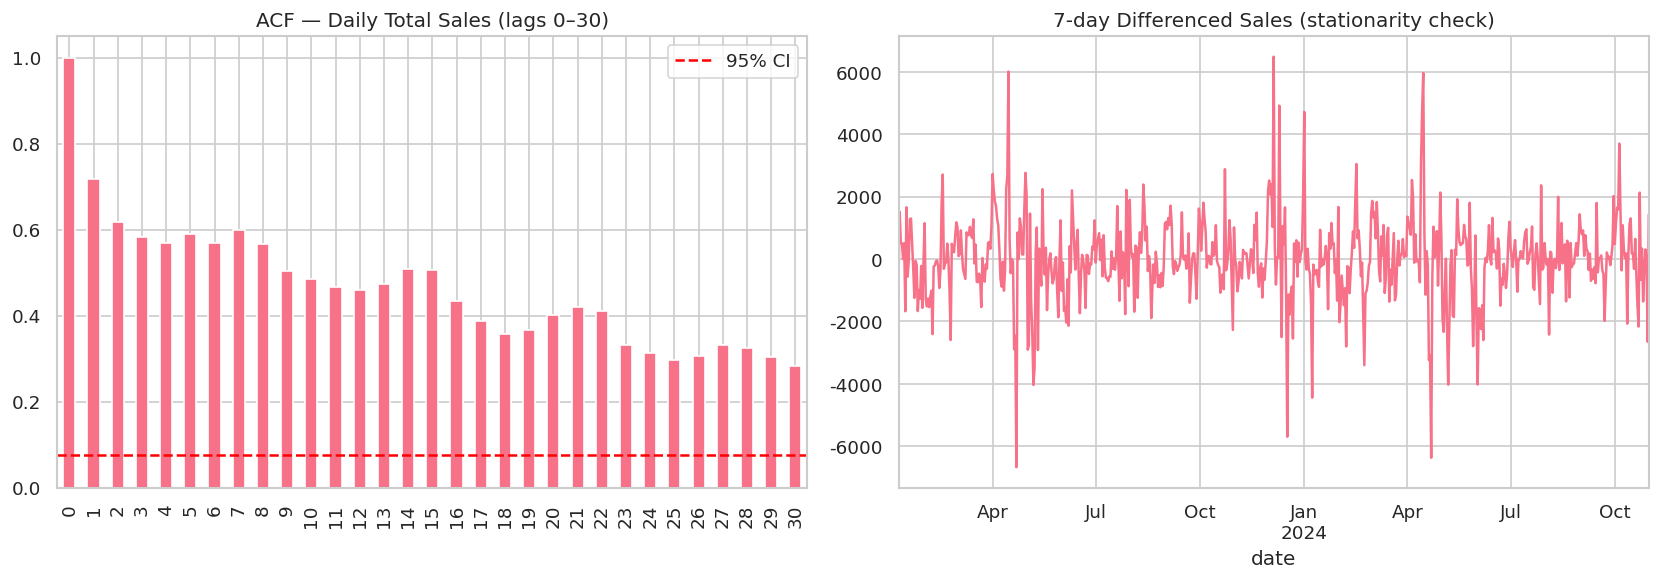

In [23]:
# CELL 15 — [CHART 14] Autocorrelation
ts = daily.groupby("date")["units_sold"].sum()
acf_vals = acf(ts, nlags=30, fft=True)
fig, axes = plt.subplots(1,2,figsize=(14,5))
pd.Series(acf_vals).plot(kind="bar",ax=axes[0],title="ACF — Daily Total Sales (lags 0–30)")
axes[0].axhline(y=0,color="black",lw=0.5)
axes[0].axhline(y=1.96/np.sqrt(len(ts)),color="red",linestyle="--",label="95% CI")
axes[0].legend()
ts.diff(7).dropna().plot(ax=axes[1],title="7-day Differenced Sales (stationarity check)")
plt.tight_layout(); plt.savefig("chart14_autocorrelation.png"); plt.show()

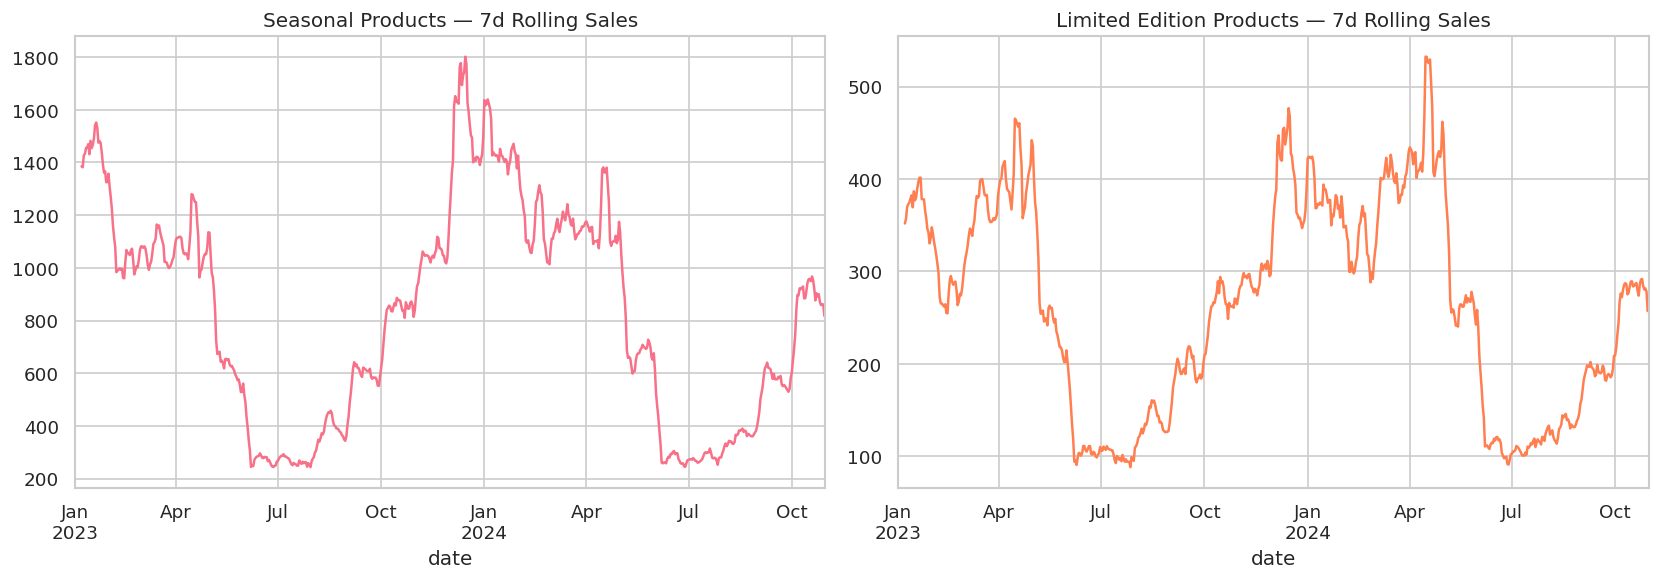

In [24]:
# CELL 16 — [NEW CHART 15] Seasonal & Limited Edition Products
seasonal_ids = prod[prod["is_seasonal"]==True]["product_id"].tolist()
limited_ids  = prod[prod["is_limited_edition"]==True]["product_id"].tolist()
df_seas = df[df["product_id"].isin(seasonal_ids)]
df_lim  = df[df["product_id"].isin(limited_ids)]

fig, axes = plt.subplots(1,2,figsize=(14,5))
if not df_seas.empty:
    df_seas.groupby("date")["units_sold"].sum().rolling(7).mean().plot(
        ax=axes[0],title="Seasonal Products — 7d Rolling Sales")
if not df_lim.empty:
    df_lim.groupby("date")["units_sold"].sum().rolling(7).mean().plot(
        ax=axes[1],color="coral",title="Limited Edition Products — 7d Rolling Sales")
plt.tight_layout(); plt.savefig("chart15_seasonal_limited.png"); plt.show()

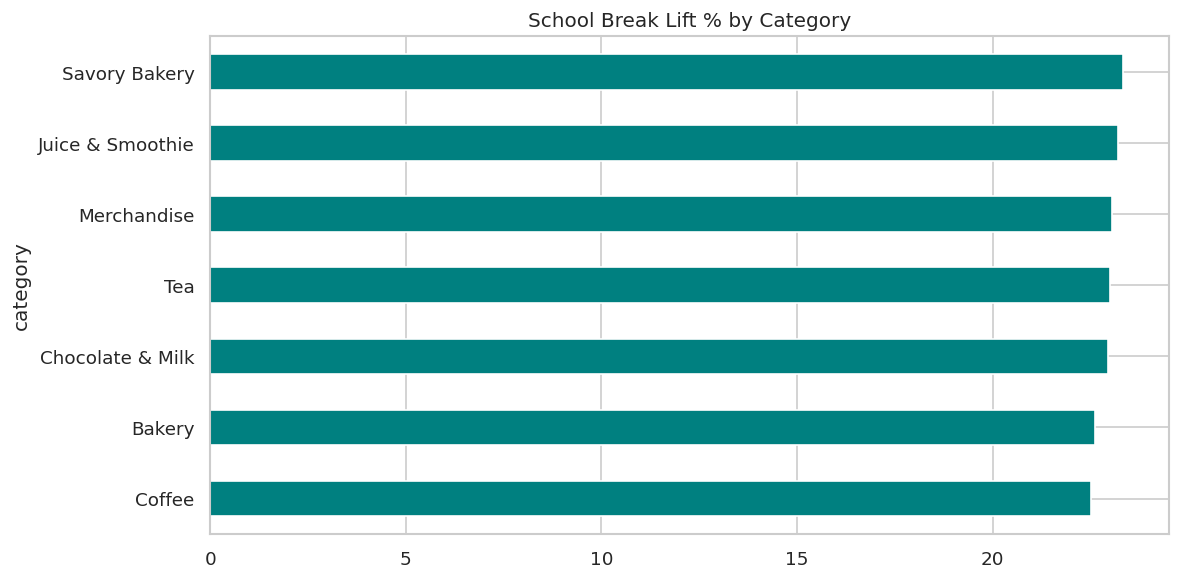

>> University-area stores may see different school break effect


In [25]:
# CELL 17 — [CHART 16] School Break Effect
sb_cat = (daily.groupby(["category","is_school_break"])["units_sold"]
          .mean().unstack().rename(columns={False:"School On",True:"School Break"}))
sb_cat["Lift%"] = (sb_cat["School Break"]-sb_cat["School On"])/sb_cat["School On"]*100
sb_cat["Lift%"].sort_values().plot(kind="barh",color="teal",figsize=(10,5),
    title="School Break Lift % by Category")
plt.axvline(x=0,color="black",lw=1)
plt.tight_layout(); plt.savefig("chart16_school_break.png"); plt.show()
print(">> University-area stores may see different school break effect")

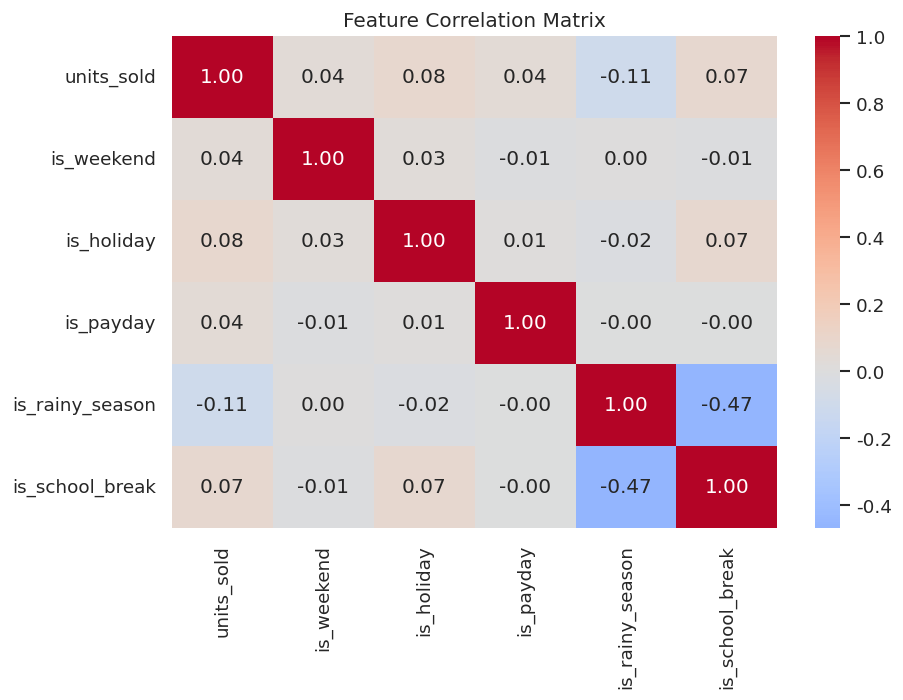

In [26]:
# CELL 18 — [CHART 17] Feature Correlation Matrix
num_cols = ["units_sold","is_weekend","is_holiday","is_payday","is_rainy_season","is_school_break"]
corr_df = daily[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout(); plt.savefig("chart17_correlation.png"); plt.show()

,column,missing_count
0,TRANSACTION (all fields),0
1,ORDER.customer_id,825292
2,DATE_DIM.holiday_name,703
3,PROMOTION.email_sent,0
4,PROMOTION.social_campaign,0


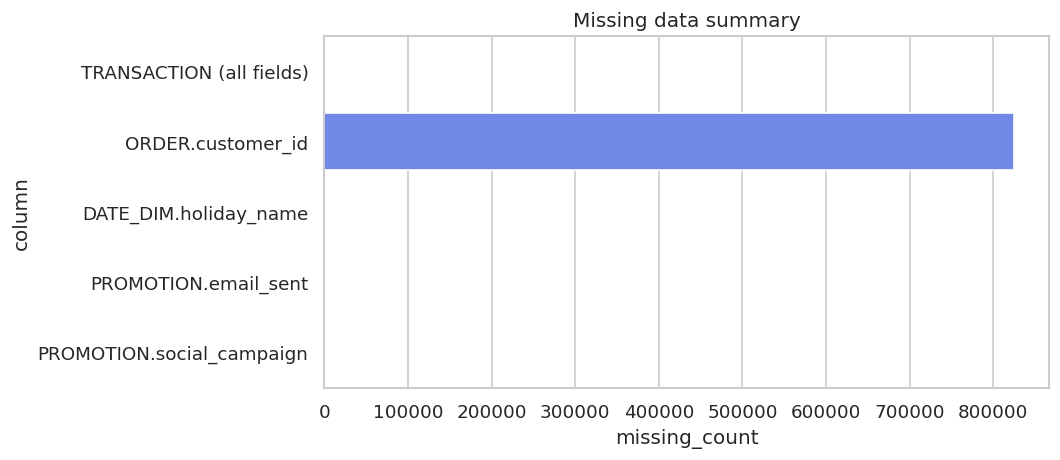

ORDER.customer_id is largely null because walk-in customers are structural non-members, not missing values to impute.


In [27]:
# CELL 19: Missing Data Summary
miss = pd.DataFrame(
    {
        "column": [
            "TRANSACTION (all fields)",
            "ORDER.customer_id",
            "DATE_DIM.holiday_name",
            "PROMOTION.email_sent",
            "PROMOTION.social_campaign",
        ],
        "missing_count": [
            int(txn.isnull().sum().sum()),
            int(order["customer_id"].isnull().sum()),
            int(date_dim["holiday_name"].isnull().sum()) if "holiday_name" in date_dim.columns else 0,
            int(promo["email_sent"].isnull().sum()) if "email_sent" in promo.columns else 0,
            int(promo["social_campaign"].isnull().sum()) if "social_campaign" in promo.columns else 0,
        ],
    }
)
display(miss)
plt.figure(figsize=(9, 4))
sns.barplot(data=miss, x="missing_count", y="column", color="#5c7cfa")
plt.title("Missing data summary")
plt.tight_layout()
plt.show()
print("ORDER.customer_id is largely null because walk-in customers are structural non-members, not missing values to impute.")

In [28]:
sku_summary = (
    line.groupby(["product_id", "product_name", "category", "serve_type", "base_price", "is_seasonal", "is_limited_edition"], observed=True)
    .agg(units=("units_sold", "sum"), revenue=("revenue", "sum"), avg_discount=("discount_applied", "mean"))
    .reset_index()
    .sort_values("units", ascending=False)
)
display(sku_summary.head(20))

seasonal_share = (
    line.groupby(["category", "is_seasonal"], observed=True, as_index=False)["units_sold"]
    .sum()
)
seasonal_share["unit_share"] = seasonal_share["units_sold"] / seasonal_share.groupby("category", observed=True)["units_sold"].transform("sum")
display(
    seasonal_share[seasonal_share["is_seasonal"]]
    .sort_values("unit_share", ascending=False)
)

monthly = daily.assign(year=daily["date"].dt.year, month=daily["date"].dt.month)
yoy = (
    monthly[monthly["month"].le(10)]
    .groupby(["year", "category"], observed=True)["units_sold"]
    .mean()
    .unstack("year")
)
yoy["yoy_pct"] = (yoy[2024] - yoy[2023]) / yoy[2023] * 100
display(yoy.sort_values("yoy_pct", ascending=False).round(2))

recent = monthly[monthly["date"].between("2024-05-01", "2024-10-31")].copy()
recent["period"] = np.where(recent["date"].dt.month <= 7, "May-Jul", "Aug-Oct")
recent_tab = recent.groupby(["category", "period"], observed=True)["units_sold"].mean().unstack()
recent_tab["change_pct"] = (recent_tab["Aug-Oct"] - recent_tab["May-Jul"]) / recent_tab["May-Jul"] * 100
display(recent_tab.sort_values("change_pct", ascending=False).round(2))

,product_id,product_name,category,serve_type,base_price,is_seasonal,is_limited_edition,units,revenue,avg_discount
9,10,ลาเต้อเมซอน,Coffee,เย็น,60,False,False,128348,7370520.00,4.290244
7,8,คาปูชิโน่,Coffee,เย็น,60,False,False,128259,7373580.00,4.168997
12,13,แบล็คคอฟฟี่,Coffee,เย็น,50,False,False,128065,6161735.00,3.782921
1,2,อเมซอน,Coffee,เย็น,55,False,False,127548,6723675.75,4.163739
4,5,เอสเปรสโซ,Coffee,เย็น,50,False,False,127405,6131180.00,3.764257
5,6,เอสเปรสโซ,Coffee,ปั่น,55,False,False,125014,6599958.75,4.014924
2,3,อเมซอน,Coffee,ปั่น,60,False,False,123558,7118508.00,3.965737
10,11,มอคค่า,Coffee,ร้อน,55,False,False,113031,5972851.50,3.951417
6,7,คาปูชิโน่,Coffee,ร้อน,50,False,False,112082,5398300.00,3.665963
8,9,ลาเต้อเมซอน,Coffee,ร้อน,50,False,False,111843,5352702.50,4.284468


,category,is_seasonal,units_sold,unit_share
3,Chocolate & Milk,True,57433,0.206754
5,Coffee,True,385200,0.198283
1,Bakery,True,56977,0.119672
10,Tea,True,56974,0.093408


year,2023,2024,yoy_pct
category,,,
Bakery,34.15,35.70,4.54
Chocolate & Milk,19.94,20.83,4.45
Coffee,139.60,145.26,4.05
Merchandise,7.08,7.35,3.89
Juice & Smoothie,12.07,12.54,3.88
Tea,43.99,45.60,3.67
Savory Bakery,27.14,28.13,3.61


period,Aug-Oct,May-Jul,change_pct
category,,,
Merchandise,6.80,6.30,8.08
Savory Bakery,25.87,24.43,5.90
Chocolate & Milk,19.15,18.15,5.48
Bakery,32.57,31.05,4.91
Coffee,132.97,126.83,4.84
Tea,41.67,39.85,4.57
Juice & Smoothie,11.52,11.08,4.03


In [29]:
inventory = pd.read_csv(TRAIN / "INVENTORY.csv", parse_dates=["date"])
txn_sku_day = (
    line.groupby(["store_id", "product_id", "date"], observed=True)["units_sold"]
    .sum()
    .reset_index(name="txn_units_sold")
)
inv_cmp = inventory.merge(txn_sku_day, on=["store_id", "product_id", "date"], how="left")
inv_cmp["txn_units_sold"] = inv_cmp["txn_units_sold"].fillna(0)
inv_cmp = inv_cmp.merge(prod[["product_id", "category"]], on="product_id", how="left")
inv_cmp["abs_diff"] = (inv_cmp["units_sold"] - inv_cmp["txn_units_sold"]).abs()

print("Inventory exact match rate:", (inv_cmp["units_sold"].eq(inv_cmp["txn_units_sold"]).mean()).round(4))
print("Inventory MAE vs transaction SKU-store-day:", inv_cmp["abs_diff"].mean().round(3))
display(inv_cmp.groupby("category").agg(stockout_rate=("is_stockout", "mean"), inv_mae=("abs_diff", "mean")).sort_values("stockout_rate", ascending=False))
display(inv_cmp.groupby("store_id").agg(stockout_rate=("is_stockout", "mean"), inv_mae=("abs_diff", "mean")).sort_values("stockout_rate", ascending=False).head(20))

stockout_cell = (
    inv_cmp[inv_cmp["is_stockout"]]
    .groupby(["store_id", "category", "date"], observed=True)
    .size()
    .reset_index(name="stockout_sku_count")
)
daily_stock = daily.merge(stockout_cell, on=["store_id", "category", "date"], how="left")
daily_stock["any_stockout"] = daily_stock["stockout_sku_count"].fillna(0).gt(0)
display(lift_table(daily_stock, "any_stockout").round(3))

Inventory exact match rate: 0.1286
Inventory MAE vs transaction SKU-store-day: 3.792


,stockout_rate,inv_mae
category,,
Juice & Smoothie,0.090328,3.614433
Tea,0.080705,4.222313
Chocolate & Milk,0.076203,3.456530
Coffee,0.074899,5.229012
Savory Bakery,0.062889,3.108955
Bakery,0.057729,3.678529
Merchandise,0.006493,1.058230


,stockout_rate,inv_mae
store_id,,
19,0.069627,3.515299
9,0.069378,4.437438
8,0.067562,3.505522
17,0.067488,3.878209
20,0.067363,3.478085
6,0.067239,5.687861
10,0.066940,4.961692
4,0.066866,3.279478
1,0.066119,3.366443


any_stockout,off,on,lift_pct
category,,,
Coffee,0.867,1.096,26.436
Merchandise,0.990,1.227,23.965
Chocolate & Milk,0.912,1.130,23.849
Tea,0.910,1.108,21.778
Bakery,0.939,1.135,20.843
Savory Bakery,0.936,1.128,20.548
Juice & Smoothie,0.952,1.115,17.087


In [30]:
feature_map = pd.DataFrame(
    [
        ["lag/rolling", "lag_7/14/28/35/60/90, rolling shifted by horizon", "must be horizon-safe"],
        ["baseline", "store_category_dow_mean, y_rel diagnostics", "separate structural volume from shocks"],
        ["store", "neighborhood_type, capacity, staff, hours, drive_through, store_age", "location/service/capacity"],
        ["calendar", "holiday_name, payday, school_break, rainy_season, month, DOW", "known future lookup"],
        ["promo", "has_promo, max_discount, promo_type, channel flags, promo_product_count", "known future lookup"],
        ["cross_promo", "drink_promo_active for Merchandise/Bakery targets", "cannibalization/cross-sell"],
        ["event", "has_event, event_type, event_count, store_type x event_type", "local demand shocks"],
        ["stockout", "lag_stockout_rate, stockout_sku_count, days_since_stockout", "recorded demand censoring"],
        ["customer", "rolling member ratio, basket attachment, payment mix", "behavior proxy, no review text"],
        ["traffic_proxy", "peak-hour share, morning/evening share by store type", "commute/location behavior"],
        ["sku_mix", "seasonal_unit_share, limited_sku_count, top_sku_promo/stockout", "hidden category composition"],
        ["drift", "recent 28/56/90 trend, YoY same month, forecast promo/event density", "public/private robustness"],
    ],
    columns=["block", "feature ideas", "purpose"],
)
display(feature_map)

,block,feature ideas,purpose
0,lag/rolling,"lag_7/14/28/35/60/90, rolling shifted by horizon",must be horizon-safe
1,baseline,"store_category_dow_mean, y_rel diagnostics",separate structural volume from shocks
2,store,"neighborhood_type, capacity, staff, hours, dri...",location/service/capacity
3,calendar,"holiday_name, payday, school_break, rainy_seas...",known future lookup
4,promo,"has_promo, max_discount, promo_type, channel f...",known future lookup
5,cross_promo,drink_promo_active for Merchandise/Bakery targets,cannibalization/cross-sell
6,event,"has_event, event_type, event_count, store_type...",local demand shocks
7,stockout,"lag_stockout_rate, stockout_sku_count, days_si...",recorded demand censoring
8,customer,"rolling member ratio, basket attachment, payme...","behavior proxy, no review text"
9,traffic_proxy,"peak-hour share, morning/evening share by stor...",commute/location behavior


In [31]:
# CELL 20: EDA Summary
print("\n" + "=" * 70)
print("EDA COMPLETE - Combined Chart Set")
print("Classic charts from the original notebook are preserved, and deep-dive diagnostics were appended.")
print("This notebook now covers more than 20 chart outputs across demand structure, seasonality, promotion, event, store, customer, drift, and stockout analysis.")
print("=" * 70)
print("\nMain takeaways:")
print("  1. Demand is highly skewed and category-driven, with Coffee dominating total volume.")
print("  2. Calendar effects matter, especially holiday and payday windows.")
print("  3. Promotions and local events show strong uplift and should be modeled explicitly.")
print("  4. Store differences are structural: neighborhood, capacity, staffing, and hours all matter.")
print("  5. Inventory stockouts distort recorded demand, so stockout-aware modeling is useful.")
print("  6. Late-period drift and forecast-window known signals should be checked before submission.")


EDA COMPLETE - Combined Chart Set
Classic charts from the original notebook are preserved, and deep-dive diagnostics were appended.
This notebook now covers more than 20 chart outputs across demand structure, seasonality, promotion, event, store, customer, drift, and stockout analysis.

Main takeaways:
  1. Demand is highly skewed and category-driven, with Coffee dominating total volume.
  2. Calendar effects matter, especially holiday and payday windows.
  3. Promotions and local events show strong uplift and should be modeled explicitly.
  4. Store differences are structural: neighborhood, capacity, staffing, and hours all matter.
  5. Inventory stockouts distort recorded demand, so stockout-aware modeling is useful.
  6. Late-period drift and forecast-window known signals should be checked before submission.


## AutoGluon TimeSeries Forecasting Pipeline

This Kaggle-ready notebook uses AutoGluon TimeSeries as the primary model, while keeping the EDA and shared feature-building code above.


In [32]:
# CELL 21: Shared Modeling Setup and Competition Config
import subprocess
import sys
from pathlib import Path

try:
    from sklearn.metrics import mean_absolute_error
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
    from sklearn.metrics import mean_absolute_error

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

FORECAST_START = pd.Timestamp("2024-11-01")
FORECAST_END = pd.Timestamp("2024-12-31")
TRAIN_END = pd.Timestamp("2024-10-31")
VALIDATION_START = pd.Timestamp("2024-10-01")
HORIZONS = {"1d": 1, "7d": 7, "1m": 30}
TARGET_COL = "units_sold"
WEIGHT_COL = "sample_weight"

ENABLE_RETRIEVAL_FEATURES = True
ENABLE_TSFRESH = True
TSFRESH_MAX_FEATURES = 50
SEPARATE_HORIZON_MODELS = True

HORIZON_CUTOFFS = {h: FORECAST_START - pd.Timedelta(days=delta) for h, delta in HORIZONS.items()}
HORIZON_PRED_LENGTHS = {h: int((FORECAST_END - cutoff).days) for h, cutoff in HORIZON_CUTOFFS.items()}

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
SUBMISSION_PATH = WORK_DIR / "submission_timeseries.csv"

print("Shared modeling config")
print(f"  Train end       : {TRAIN_END.date()}")
print(f"  Validation start: {VALIDATION_START.date()}")
print(f"  Forecast window : {FORECAST_START.date()} -> {FORECAST_END.date()}")
print(f"  Horizons        : {HORIZONS}")
for h in HORIZONS:
    print(f"  Horizon {h} cutoff: {HORIZON_CUTOFFS[h].date()} (pred_len {HORIZON_PRED_LENGTHS[h]})")
print(f"  Submission path : {SUBMISSION_PATH}")
print(f"  Separate models : {SEPARATE_HORIZON_MODELS}")
print(f"  Retrieval feats : {ENABLE_RETRIEVAL_FEATURES}")
print(f"  TSFresh feats   : {ENABLE_TSFRESH}")

Shared modeling config
  Train end       : 2024-10-31
  Validation start: 2024-10-01
  Forecast window : 2024-11-01 -> 2024-12-31
  Horizons        : {'1d': 1, '7d': 7, '1m': 30}
  Horizon 1d cutoff: 2024-10-31 (pred_len 61)
  Horizon 7d cutoff: 2024-10-25 (pred_len 67)
  Horizon 1m cutoff: 2024-10-02 (pred_len 90)
  Submission path : /kaggle/working/submission_timeseries.csv
  Separate models : True
  Retrieval feats : True
  TSFresh feats   : True


In [33]:
# CELL 22: Feature Engineering Helpers
KEYS = ["store_id", "category", "date"]
STORE_KEY = ["store_id", "date"]
CATEGORY_KEY = ["category", "date"]

DRINK_CATEGORIES = {"Coffee", "Tea", "Chocolate & Milk", "Juice & Smoothie"}
FOOD_CATEGORIES = {"Bakery", "Savory Bakery"}


def to_bool_int(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype("int8")
    return series.astype(str).str.lower().isin(["true", "1", "yes", "y"]).astype("int8")


def safe_numeric(series, default=0):
    return pd.to_numeric(series, errors="coerce").fillna(default)


def first_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    if Path("/kaggle/input").exists():
        matches = list(Path("/kaggle/input").rglob("sample_submission_with_id.csv"))
        if matches:
            return matches[0]
    return None


def prepare_date_features(*date_frames):
    frames = [d.copy() for d in date_frames if isinstance(d, pd.DataFrame) and len(d) > 0]
    if frames:
        out = pd.concat(frames, ignore_index=True).drop_duplicates("date", keep="last")
    else:
        out = pd.DataFrame({"date": pd.date_range(daily["date"].min(), FORECAST_END, freq="D")})
    out["date"] = pd.to_datetime(out["date"])
    out = out.drop_duplicates("date", keep="last")

    out["day_of_week"] = out.get("day_of_week", out["date"].dt.day_name()).fillna(out["date"].dt.day_name())
    out["week_number"] = safe_numeric(out.get("week_number", out["date"].dt.isocalendar().week), out["date"].dt.isocalendar().week)
    out["month"] = safe_numeric(out.get("month", out["date"].dt.month), out["date"].dt.month)
    out["quarter"] = safe_numeric(out.get("quarter", out["date"].dt.quarter), out["date"].dt.quarter)
    out["year"] = safe_numeric(out.get("year", out["date"].dt.year), out["date"].dt.year)
    for col in ["is_weekend", "is_holiday", "is_school_break", "is_payday", "is_rainy_season"]:
        out[col] = to_bool_int(out[col]) if col in out else 0
    out["holiday_name"] = out.get("holiday_name", "none").fillna("none").replace("", "none")
    out["day"] = out["date"].dt.day
    out["dayofweek_num"] = out["date"].dt.dayofweek
    out["dayofyear"] = out["date"].dt.dayofyear
    out["is_month_start"] = out["date"].dt.is_month_start.astype("int8")
    out["is_month_end"] = out["date"].dt.is_month_end.astype("int8")
    out["sin_dow"] = np.sin(2 * np.pi * out["dayofweek_num"] / 7)
    out["cos_dow"] = np.cos(2 * np.pi * out["dayofweek_num"] / 7)
    out["sin_month"] = np.sin(2 * np.pi * out["month"] / 12)
    out["cos_month"] = np.cos(2 * np.pi * out["month"] / 12)
    for period in [30.5, 167.5, 335.0, 365.25]:
        safe_period = str(period).replace(".", "_")
        out[f"sin_period_{safe_period}"] = np.sin(2 * np.pi * out["dayofyear"] / period)
        out[f"cos_period_{safe_period}"] = np.cos(2 * np.pi * out["dayofyear"] / period)
    out["is_gifting_season"] = ((out["month"] == 12) & (out["day"] >= 10)).astype("int8")
    out["is_nye"] = ((out["month"] == 12) & (out["day"] == 31)).astype("int8")
    out["is_fathers_day"] = ((out["month"] == 12) & (out["day"] == 5)).astype("int8")
    out["is_constitution_day"] = ((out["month"] == 12) & (out["day"] == 10)).astype("int8")
    out["is_loy_krathong_2024"] = (out["date"].eq(pd.Timestamp("2024-11-15"))).astype("int8")
    return out


def prepare_store_features(store_df):
    out = store_df.copy()
    out["open_hour"] = safe_numeric(out["open_time"].astype(str).str.split(":").str[0], 7)
    out["close_hour"] = safe_numeric(out["close_time"].astype(str).str.split(":").str[0], 21)
    out["operating_hours"] = out["close_hour"] - out["open_hour"]
    out.loc[out["operating_hours"] <= 0, "operating_hours"] += 24
    out["has_drive_through"] = to_bool_int(out["has_drive_through"])
    out["seating_capacity"] = safe_numeric(out["seating_capacity"], out["seating_capacity"].median())
    out["staff_count"] = safe_numeric(out["staff_count"], out["staff_count"].median())
    out["capacity_per_staff"] = out["seating_capacity"] / out["staff_count"].replace(0, np.nan)
    out["capacity_per_staff"] = out["capacity_per_staff"].replace([np.inf, -np.inf], np.nan).fillna(out["capacity_per_staff"].median())
    out["opened_date"] = pd.to_datetime(out["opened_date"])
    return out[
        [
            "store_id", "neighborhood_type", "seating_capacity", "has_drive_through",
            "staff_count", "open_hour", "close_hour", "operating_hours",
            "capacity_per_staff", "opened_date",
        ]
    ]


def prepare_category_features(product_df):
    p = product_df.copy()
    p["base_price"] = safe_numeric(p["base_price"], p["base_price"].median())
    p["is_seasonal_int"] = to_bool_int(p["is_seasonal"])
    p["is_limited_edition_int"] = to_bool_int(p["is_limited_edition"])
    profile = (
        p.groupby("category", observed=True)
        .agg(
            category_sku_count=("product_id", "nunique"),
            category_avg_base_price=("base_price", "mean"),
            category_min_base_price=("base_price", "min"),
            category_max_base_price=("base_price", "max"),
            category_seasonal_sku_share=("is_seasonal_int", "mean"),
            category_limited_sku_share=("is_limited_edition_int", "mean"),
            category_serve_type_count=("serve_type", "nunique"),
        )
        .reset_index()
    )
    return profile


def build_promo_features(promo_frames, product_df):
    frames = [p.copy() for p in promo_frames if isinstance(p, pd.DataFrame) and len(p) > 0]
    empty_cat = pd.DataFrame(
        columns=[
            "store_id", "category", "date", "has_promo", "max_discount", "mean_discount",
            "promo_product_count", "promo_campaign_count", "email_sent", "social_campaign", "promo_type",
        ]
    )
    empty_store = pd.DataFrame(
        columns=[
            "store_id", "date", "store_promo_product_count", "store_max_discount",
            "store_email_campaign", "store_social_campaign", "drink_promo_active",
            "food_promo_active", "merch_promo_active",
        ]
    )
    if not frames:
        return empty_cat, empty_store

    p = pd.concat(frames, ignore_index=True).drop_duplicates()
    p = p.merge(product_df[["product_id", "category"]], on="product_id", how="left")
    p["start_date"] = pd.to_datetime(p["start_date"])
    p["end_date"] = pd.to_datetime(p["end_date"])
    p["discount_pct"] = safe_numeric(p["discount_pct"], 0)
    p["email_sent"] = to_bool_int(p["email_sent"])
    p["social_campaign"] = to_bool_int(p["social_campaign"])
    promo_text = p["promo_type"].fillna("").astype(str)
    p["promo_has_bogo"] = promo_text.str.contains("ซื้อ1แถม1|buy|bogo", case=False, regex=True).astype("int8")
    p["promo_has_discount"] = promo_text.str.contains("ลดราคา|discount", case=False, regex=True).astype("int8")
    p["promo_has_points_x2"] = promo_text.str.contains("แต้มx2|x2|point", case=False, regex=True).astype("int8")
    p["promo_has_new_member"] = promo_text.str.contains("สมาชิกใหม่|new member", case=False, regex=True).astype("int8")
    p["promo_has_bundle"] = promo_text.str.contains("ชุดคู่|bundle", case=False, regex=True).astype("int8")

    def valid_range(row):
        if pd.isna(row["start_date"]) or pd.isna(row["end_date"]):
            return []
        if row["end_date"] < row["start_date"]:
            return []
        return pd.date_range(row["start_date"], row["end_date"], freq="D")

    p["date"] = p.apply(valid_range, axis=1)
    p = p.explode("date")
    p = p[p["date"].notna()].copy()
    if p.empty:
        return empty_cat, empty_store

    promo_cat = (
        p.groupby(["store_id", "category", "date"], observed=True)
        .agg(
            has_promo=("promo_id", "count"),
            max_discount=("discount_pct", "max"),
            mean_discount=("discount_pct", "mean"),
            promo_product_count=("product_id", "nunique"),
            promo_campaign_count=("campaign_id", "nunique"),
            email_sent=("email_sent", "max"),
            social_campaign=("social_campaign", "max"),
            promo_type=("promo_type", lambda s: "|".join(sorted(set(s.dropna().astype(str))))[:200]),
            promo_has_bogo=("promo_has_bogo", "max"),
            promo_has_discount=("promo_has_discount", "max"),
            promo_has_points_x2=("promo_has_points_x2", "max"),
            promo_has_new_member=("promo_has_new_member", "max"),
            promo_has_bundle=("promo_has_bundle", "max"),
        )
        .reset_index()
    )
    promo_cat["has_promo"] = (promo_cat["has_promo"] > 0).astype("int8")
    promo_cat["promo_type"] = promo_cat["promo_type"].replace("", "none")

    p["is_drink_promo"] = p["category"].isin(DRINK_CATEGORIES).astype("int8")
    p["is_food_promo"] = p["category"].isin(FOOD_CATEGORIES).astype("int8")
    p["is_merch_promo"] = (p["category"] == "Merchandise").astype("int8")
    promo_store = (
        p.groupby(["store_id", "date"], observed=True)
        .agg(
            store_promo_product_count=("product_id", "nunique"),
            store_max_discount=("discount_pct", "max"),
            store_email_campaign=("email_sent", "max"),
            store_social_campaign=("social_campaign", "max"),
            drink_promo_active=("is_drink_promo", "max"),
            food_promo_active=("is_food_promo", "max"),
            merch_promo_active=("is_merch_promo", "max"),
            store_promo_has_bogo=("promo_has_bogo", "max"),
            store_promo_has_discount=("promo_has_discount", "max"),
            store_promo_has_points_x2=("promo_has_points_x2", "max"),
            store_promo_has_new_member=("promo_has_new_member", "max"),
            store_promo_has_bundle=("promo_has_bundle", "max"),
        )
        .reset_index()
    )
    return promo_cat, promo_store


def build_event_features(event_frames):
    frames = [e.copy() for e in event_frames if isinstance(e, pd.DataFrame) and len(e) > 0]
    if not frames:
        return pd.DataFrame(columns=["store_id", "date", "event_count", "has_event", "event_type"])
    ev = pd.concat(frames, ignore_index=True).drop_duplicates()
    ev["date"] = pd.to_datetime(ev["date"])
    event_daily = (
        ev.groupby(["store_id", "date"], observed=True)
        .agg(
            event_count=("event_id", "count"),
            event_type=("event_type", lambda s: "|".join(sorted(set(s.dropna().astype(str))))[:200]),
            event_name_count=("event_name", "nunique"),
        )
        .reset_index()
    )
    event_daily["has_event"] = (event_daily["event_count"] > 0).astype("int8")
    event_daily["event_type"] = event_daily["event_type"].replace("", "none")
    for event_type in ["food_festival", "music_festival", "cultural", "concert", "market", "convention", "sports"]:
        event_daily[f"event_{event_type}"] = event_daily["event_type"].astype(str).str.contains(event_type, regex=False).astype("int8")
    return event_daily


def add_lag_lookup(frame, history, keys, value_col, horizon_days, extra_lags, prefix):
    base = (
        history[keys + ["date", value_col]]
        .groupby(keys + ["date"], observed=True)[value_col]
        .mean()
        .reset_index()
    )
    out = frame
    for extra in extra_lags:
        lag_days = horizon_days + extra
        lookup = base.copy()
        lookup["date"] = lookup["date"] + pd.to_timedelta(lag_days, unit="D")
        out = out.merge(
            lookup.rename(columns={value_col: f"{prefix}_lag_{lag_days}"}),
            on=keys + ["date"],
            how="left",
        )
    return out


def add_rolling_lookup(frame, history, keys, value_col, horizon_days, windows, prefix):
    work = (
        history[keys + ["date", value_col]]
        .groupby(keys + ["date"], observed=True)[value_col]
        .mean()
        .reset_index()
        .sort_values(keys + ["date"])
    )
    new_cols = []
    for window in windows:
        min_periods = max(1, min(7, window))
        mean_col = f"{prefix}_roll_mean_{window}_h{horizon_days}"
        std_col = f"{prefix}_roll_std_{window}_h{horizon_days}"
        work[mean_col] = work.groupby(keys, observed=True)[value_col].transform(
            lambda s, w=window, mp=min_periods: s.rolling(w, min_periods=mp).mean()
        )
        work[std_col] = work.groupby(keys, observed=True)[value_col].transform(
            lambda s, w=window, mp=min_periods: s.rolling(w, min_periods=mp).std()
        )
        new_cols.extend([mean_col, std_col])
    work["date"] = work["date"] + pd.to_timedelta(horizon_days, unit="D")
    return frame.merge(work[keys + ["date"] + new_cols], on=keys + ["date"], how="left")


def finalize_for_autogluon(frame):
    out = frame.copy()
    for col in out.columns:
        if pd.api.types.is_bool_dtype(out[col]):
            out[col] = out[col].astype("int8")
        elif pd.api.types.is_object_dtype(out[col]):
            out[col] = out[col].fillna("none").astype("category")
    return out

In [34]:
# CELL 23: Build Full Known-Future Panel and Historical Tables
def build_model_assets(train_end):
    target_daily = (
        daily.loc[daily["date"] <= train_end, ["store_id", "category", "date", TARGET_COL]]
        .groupby(KEYS, observed=True)[TARGET_COL]
        .sum()
        .reset_index()
    )

    history_profile = (
        target_daily.groupby(["store_id", "category"], observed=True)
        .agg(
            hist_mean=(TARGET_COL, "mean"),
            hist_median=(TARGET_COL, "median"),
            hist_std=(TARGET_COL, "std"),
            hist_p90=(TARGET_COL, lambda s: s.quantile(0.90)),
            hist_p95=(TARGET_COL, lambda s: s.quantile(0.95)),
        )
        .reset_index()
    )
    recent_28 = (
        target_daily[target_daily["date"] >= train_end - pd.Timedelta(days=27)]
        .groupby(["store_id", "category"], observed=True)[TARGET_COL]
        .mean()
        .reset_index(name="recent_28_mean")
    )
    recent_90 = (
        target_daily[target_daily["date"] >= train_end - pd.Timedelta(days=89)]
        .groupby(["store_id", "category"], observed=True)[TARGET_COL]
        .mean()
        .reset_index(name="recent_90_mean")
    )
    history_profile = history_profile.merge(recent_28, on=["store_id", "category"], how="left")
    history_profile = history_profile.merge(recent_90, on=["store_id", "category"], how="left")
    history_profile["trend_28_90"] = (
        (history_profile["recent_28_mean"] - history_profile["recent_90_mean"])
        / history_profile["recent_90_mean"].replace(0, np.nan)
    )
    history_profile = history_profile.fillna(0)

    date_features = prepare_date_features(date_dim, test_date)
    store_features = prepare_store_features(store)
    category_features = prepare_category_features(prod)
    promo_cat, promo_store = build_promo_features([promo, test_promo], prod)
    event_daily = build_event_features([event, test_event])

    all_dates = pd.date_range(target_daily["date"].min(), FORECAST_END, freq="D")
    all_store_ids = sorted(store["store_id"].dropna().unique())
    all_categories = sorted(prod["category"].dropna().unique())
    panel = pd.MultiIndex.from_product(
        [all_store_ids, all_categories, all_dates],
        names=["store_id", "category", "date"],
    ).to_frame(index=False)

    panel = panel.merge(target_daily, on=KEYS, how="left")
    panel[TARGET_COL] = np.where(panel["date"] <= train_end, panel[TARGET_COL].fillna(0), np.nan)
    panel = panel.merge(store_features, on="store_id", how="left")
    panel = panel.merge(category_features, on="category", how="left")
    panel = panel.merge(date_features, on="date", how="left")
    panel["store_age_days"] = (panel["date"] - panel["opened_date"]).dt.days.clip(lower=0)
    panel = panel.drop(columns=["opened_date"])
    panel = panel.merge(history_profile, on=["store_id", "category"], how="left")

    panel = panel.merge(promo_cat, on=KEYS, how="left")
    panel = panel.merge(promo_store, on=STORE_KEY, how="left")
    panel = panel.merge(event_daily, on=STORE_KEY, how="left")

    if ENABLE_RETRIEVAL_FEATURES:
        hist_calendar = target_daily.merge(date_features, on="date", how="left")
        cal_cols = ["store_id", "category", "dayofweek_num", "is_holiday", "is_payday", "month"]
        calendar_profile = (
            hist_calendar.groupby(cal_cols, observed=True)
            .agg(
                retrieval_mean=(TARGET_COL, "mean"),
                retrieval_median=(TARGET_COL, "median"),
                retrieval_count=(TARGET_COL, "size"),
            )
            .reset_index()
        )
        panel = panel.merge(calendar_profile, on=cal_cols, how="left")

        cat_cols = ["category", "dayofweek_num", "is_holiday", "is_payday", "month"]
        cat_profile = (
            hist_calendar.groupby(cat_cols, observed=True)
            .agg(retrieval_cat_mean=(TARGET_COL, "mean"))
            .reset_index()
        )
        panel = panel.merge(cat_profile, on=cat_cols, how="left")
        panel["retrieval_mean"] = panel["retrieval_mean"].fillna(panel["retrieval_cat_mean"])
        panel["retrieval_median"] = panel["retrieval_median"].fillna(panel["retrieval_cat_mean"])
        panel["retrieval_count"] = panel["retrieval_count"].fillna(0)

    history_cols = [
        "hist_mean", "hist_median", "hist_std", "hist_p90", "hist_p95",
        "recent_28_mean", "recent_90_mean", "trend_28_90",
    ]
    retrieval_cols = ["retrieval_mean", "retrieval_median", "retrieval_count", "retrieval_cat_mean"]
    zero_cols = [
        "has_promo", "max_discount", "mean_discount", "promo_product_count", "promo_campaign_count",
        "email_sent", "social_campaign", "store_promo_product_count", "store_max_discount",
        "store_email_campaign", "store_social_campaign", "drink_promo_active", "food_promo_active",
        "merch_promo_active", "store_promo_has_bogo", "store_promo_has_discount",
        "store_promo_has_points_x2", "store_promo_has_new_member", "store_promo_has_bundle",
        "promo_has_bogo", "promo_has_discount", "promo_has_points_x2", "promo_has_new_member", "promo_has_bundle",
        "event_count", "has_event", "event_name_count", "event_food_festival", "event_music_festival",
        "event_cultural", "event_concert", "event_market", "event_convention", "event_sports",
        "loyal_customer_count", "loyal_member_count", "loyal_member_ratio",
        "home_store_neighborhood_match_ratio", "avg_customer_tenure_days",
        "customer_home_neighborhood_nunique",
        *history_cols,
        *retrieval_cols,
    ]
    for col in zero_cols:
        if col in panel:
            panel[col] = panel[col].fillna(0)
    for col in ["promo_type", "event_type", "holiday_name"]:
        if col in panel:
            panel[col] = panel[col].fillna("none").replace("", "none")

    STORE_TIER = {
        6: "high", 10: "high", 9: "high",
        5: "mid", 15: "mid", 2: "mid", 14: "mid", 8: "mid", 3: "mid",
        17: "mid", 19: "mid", 20: "mid",
        1: "low", 16: "low", 7: "low", 18: "low", 11: "low", 12: "low", 4: "low", 13: "low",
    }
    panel["store_tier"] = panel["store_id"].map(STORE_TIER).fillna("mid")
    panel["is_coffee"] = (panel["category"] == "Coffee").astype("int8")
    panel["is_tea"] = (panel["category"] == "Tea").astype("int8")
    panel["is_juice"] = (panel["category"] == "Juice & Smoothie").astype("int8")
    panel["is_merchandise"] = (panel["category"] == "Merchandise").astype("int8")
    panel["is_bakery_family"] = panel["category"].isin(["Bakery", "Savory Bakery"]).astype("int8")
    panel["rainy_x_coffee"] = panel["is_rainy_season"] * panel["is_coffee"]
    panel["rainy_x_juice"] = panel["is_rainy_season"] * panel["is_juice"]
    panel["weekend_x_office"] = panel["is_weekend"] * (panel["neighborhood_type"] == "office").astype("int8")
    panel["weekend_x_mall"] = panel["is_weekend"] * (panel["neighborhood_type"] == "mall").astype("int8")
    panel["school_break_x_university"] = panel["is_school_break"] * (panel["neighborhood_type"] == "university").astype("int8")
    panel["gifting_x_merchandise"] = panel["is_gifting_season"] * panel["is_merchandise"]
    panel["nye_x_tourist_mall"] = panel["is_nye"] * panel["neighborhood_type"].isin(["tourist", "mall"]).astype("int8")
    panel["loy_x_tourist_mall"] = panel["is_loy_krathong_2024"] * panel["neighborhood_type"].isin(["tourist", "mall"]).astype("int8")
    panel["holiday_x_coffee"] = panel["is_holiday"] * panel["is_coffee"]
    panel["food_festival_x_store"] = panel.get("event_food_festival", 0) * panel["store_id"]

    inv = inventory.merge(prod[["product_id", "category"]], on="product_id", how="left").copy()
    inv["is_stockout_int"] = to_bool_int(inv["is_stockout"])
    inv["opening_stock"] = safe_numeric(inv["opening_stock"], 0)
    inv["closing_stock"] = safe_numeric(inv["closing_stock"], 0)
    inv["inventory_units_sold_reported"] = safe_numeric(inv["units_sold"], 0)
    stockout_daily = (
        inv.groupby(KEYS, observed=True)
        .agg(
            target_stockout_sku_count=("is_stockout_int", "sum"),
            target_stockout_rate=("is_stockout_int", "mean"),
            min_closing_stock=("closing_stock", "min"),
            total_opening_stock=("opening_stock", "sum"),
            inventory_units_sold_reported=("inventory_units_sold_reported", "sum"),
        )
        .reset_index()
    )
    stockout_history = target_daily[KEYS].merge(stockout_daily, on=KEYS, how="left")
    for col in [
        "target_stockout_sku_count", "target_stockout_rate", "min_closing_stock",
        "total_opening_stock", "inventory_units_sold_reported",
    ]:
        stockout_history[col] = stockout_history[col].fillna(0)

    behavior = line.copy()
    behavior["is_member_int"] = to_bool_int(behavior["is_member"])
    behavior["discount_applied"] = safe_numeric(behavior["discount_applied"], 0)
    behavior["hour"] = safe_numeric(behavior["hour"], 12)
    behavior["revenue"] = safe_numeric(behavior["revenue"], 0)
    behavior["member_units"] = behavior[TARGET_COL] * behavior["is_member_int"]
    behavior["discounted_units"] = behavior[TARGET_COL] * (behavior["discount_applied"] > 0).astype("int8")
    behavior["morning_units"] = behavior[TARGET_COL] * (behavior["hour"] <= 10).astype("int8")
    behavior["lunch_units"] = behavior[TARGET_COL] * behavior["hour"].between(11, 14).astype("int8")
    behavior["evening_units"] = behavior[TARGET_COL] * (behavior["hour"] >= 17).astype("int8")
    behavior_daily = (
        behavior.groupby(KEYS, observed=True)
        .agg(
            behavior_units=(TARGET_COL, "sum"),
            member_units=("member_units", "sum"),
            discounted_units=("discounted_units", "sum"),
            morning_units=("morning_units", "sum"),
            lunch_units=("lunch_units", "sum"),
            evening_units=("evening_units", "sum"),
            revenue_sum=("revenue", "sum"),
            avg_discount_applied=("discount_applied", "mean"),
            order_count=("order_id", "nunique"),
            customer_count=("customer_id", "nunique"),
        )
        .reset_index()
    )
    behavior_history = target_daily[KEYS].merge(behavior_daily, on=KEYS, how="left").fillna(0)
    denom = behavior_history["behavior_units"].replace(0, np.nan)
    behavior_history["member_unit_share"] = (behavior_history["member_units"] / denom).fillna(0)
    behavior_history["discounted_unit_share"] = (behavior_history["discounted_units"] / denom).fillna(0)
    behavior_history["morning_unit_share"] = (behavior_history["morning_units"] / denom).fillna(0)
    behavior_history["lunch_unit_share"] = (behavior_history["lunch_units"] / denom).fillna(0)
    behavior_history["evening_unit_share"] = (behavior_history["evening_units"] / denom).fillna(0)
    behavior_history["avg_unit_revenue"] = (behavior_history["revenue_sum"] / denom).fillna(0)
    behavior_history["orders_per_customer"] = (
        behavior_history["order_count"] / behavior_history["customer_count"].replace(0, np.nan)
    ).fillna(0)

    stockout_profile = (
        stockout_history.groupby(["store_id", "category"], observed=True)
        .agg(
            stockout_rate_mean=("target_stockout_rate", "mean"),
            stockout_rate_p90=("target_stockout_rate", lambda s: s.quantile(0.90)),
            stockout_sku_mean=("target_stockout_sku_count", "mean"),
            stockout_units_reported_mean=("inventory_units_sold_reported", "mean"),
            stockout_opening_stock_mean=("total_opening_stock", "mean"),
            stockout_min_closing_stock_mean=("min_closing_stock", "mean"),
        )
        .reset_index()
    )
    behavior_profile = (
        behavior_history.groupby(["store_id", "category"], observed=True)
        .agg(
            member_share_mean=("member_unit_share", "mean"),
            discounted_share_mean=("discounted_unit_share", "mean"),
            morning_share_mean=("morning_unit_share", "mean"),
            lunch_share_mean=("lunch_unit_share", "mean"),
            evening_share_mean=("evening_unit_share", "mean"),
            avg_unit_revenue_mean=("avg_unit_revenue", "mean"),
            orders_per_customer_mean=("orders_per_customer", "mean"),
        )
        .reset_index()
    )
    panel = panel.merge(stockout_profile, on=["store_id", "category"], how="left")
    panel = panel.merge(behavior_profile, on=["store_id", "category"], how="left")

    profile_cols = [
        "stockout_rate_mean", "stockout_rate_p90", "stockout_sku_mean",
        "stockout_units_reported_mean", "stockout_opening_stock_mean", "stockout_min_closing_stock_mean",
        "member_share_mean", "discounted_share_mean", "morning_share_mean", "lunch_share_mean",
        "evening_share_mean", "avg_unit_revenue_mean", "orders_per_customer_mean",
    ]
    for col in profile_cols:
        if col in panel:
            panel[col] = panel[col].fillna(0)

    # YoY Lag Features (lag_364/365/366)
    # Safe: Nov-Dec 2024 lags point back to Nov-Dec 2023 (always in train data)
    _full_ts = daily[["store_id", "category", "date", TARGET_COL]].copy()
    _full_ts = _full_ts.groupby(["store_id", "category", "date"], observed=True)[TARGET_COL].sum().reset_index()
    _full_ts = _full_ts.sort_values(["store_id", "category", "date"])
    for _lag in [364, 365, 366]:
        _full_ts[f"lag_{_lag}"] = (
            _full_ts.groupby(["store_id", "category"], observed=True)[TARGET_COL]
            .shift(_lag)
            .fillna(0)
            .astype("float32")
        )
    lag_cols = ["lag_364", "lag_365", "lag_366"]
    panel = panel.merge(
        _full_ts[["store_id", "category", "date"] + lag_cols],
        on=["store_id", "category", "date"], how="left"
    )
    for col in lag_cols:
        panel[col] = panel[col].fillna(0).astype("float32")

    return target_daily, panel, stockout_history, behavior_history


target_daily, known_panel, stockout_history, behavior_history = build_model_assets(TRAIN_END)

print(f"target_daily shape : {target_daily.shape}")
print(f"known_panel shape  : {known_panel.shape}")
print(f"stockout shape     : {stockout_history.shape}")
print(f"behavior shape     : {behavior_history.shape}")
display(known_panel.head())

target_daily shape : (93800, 4)
known_panel shape  : (102340, 133)
stockout shape     : (93800, 8)
behavior shape     : (93800, 20)


,store_id,category,date,units_sold,neighborhood_type,seating_capacity,has_drive_through,staff_count,open_hour,close_hour,...,member_share_mean,discounted_share_mean,morning_share_mean,lunch_share_mean,evening_share_mean,avg_unit_revenue_mean,orders_per_customer_mean,lag_364,lag_365,lag_366
0,1,Bakery,2023-01-01,18.0,university,39,0,4,6,21,...,0.402694,0.102238,0.334786,0.384639,0.12853,44.137494,4.083504,0.0,0.0,0.0
1,1,Bakery,2023-01-02,33.0,university,39,0,4,6,21,...,0.402694,0.102238,0.334786,0.384639,0.12853,44.137494,4.083504,0.0,0.0,0.0
2,1,Bakery,2023-01-03,21.0,university,39,0,4,6,21,...,0.402694,0.102238,0.334786,0.384639,0.12853,44.137494,4.083504,0.0,0.0,0.0
3,1,Bakery,2023-01-04,28.0,university,39,0,4,6,21,...,0.402694,0.102238,0.334786,0.384639,0.12853,44.137494,4.083504,0.0,0.0,0.0
4,1,Bakery,2023-01-05,39.0,university,39,0,4,6,21,...,0.402694,0.102238,0.334786,0.384639,0.12853,44.137494,4.083504,0.0,0.0,0.0


## AutoGluon TimeSeries Model Pipeline

Primary modeling path using `autogluon.timeseries.TimeSeriesPredictor`.


In [35]:
# CELL 28: AutoGluon TimeSeries Setup
# Kaggle sometimes ships a newer pyarrow where PyExtensionType was removed,
# while GluonTS/AutoGluon TimeSeries may still import code that expects it.
# This shim is safe: PyExtensionType was an alias-like extension base class.
def patch_pyarrow_pyextensiontype():
    try:
        import pyarrow as pa
        import pyarrow.lib as pa_lib
        if not hasattr(pa, "PyExtensionType") and hasattr(pa, "ExtensionType"):
            pa.PyExtensionType = pa.ExtensionType
        if not hasattr(pa_lib, "PyExtensionType") and hasattr(pa, "ExtensionType"):
            pa_lib.PyExtensionType = pa.ExtensionType
        return True
    except Exception as exc:
        print(f"pyarrow compatibility shim skipped: {type(exc).__name__}: {exc}")
        return False

patch_pyarrow_pyextensiontype()
try:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
except ModuleNotFoundError:
    print("autogluon.timeseries is missing; installing autogluon.timeseries now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "autogluon.timeseries"])
    patch_pyarrow_pyextensiontype()
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
except AttributeError as exc:
    if "PyExtensionType" in str(exc):
        patch_pyarrow_pyextensiontype()
        try:
            from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
        except Exception as exc2:
            raise RuntimeError(
                "AutoGluon TimeSeries still hits the Kaggle pyarrow compatibility issue. "
                "Restart the runtime and rerun from CELL 21. If it persists, run: "
                "!pip install -q --force-reinstall pyarrow==16.1.0 autogluon.timeseries"
            ) from exc2
    else:
        raise

TS_PREDICTION_LENGTH = 61
TS_TIME_LIMIT = 3600
TS_PRESET = "best_quality"
TS_RESUME_TRAINING = False
TS_MODEL_DIR = WORK_DIR / "autogluon_expresso_timeseries_v1"
TS_SUBMISSION_PATH = WORK_DIR / "submission_timeseries.csv"
TS_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("AutoGluon TimeSeries config")
print(f"  prediction_length: {TS_PREDICTION_LENGTH}")
print(f"  eval_metric       : MAE")
print(f"  preset            : {TS_PRESET}")
print(f"  time_limit        : {TS_TIME_LIMIT}")
print(f"  resume_training   : {TS_RESUME_TRAINING}")
print(f"  model_dir         : {TS_MODEL_DIR}")

autogluon.timeseries is missing; installing autogluon.timeseries now...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
datasets 4.8.3 requires pyarrow>=21.0.0, but you have pyarrow 20.0.0 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.9.1 which is incompatible.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.9.1 which is incompatible.


AutoGluon TimeSeries config
  prediction_length: 61
  eval_metric       : MAE
  preset            : best_quality
  time_limit        : 3600
  resume_training   : False
  model_dir         : /kaggle/working/autogluon_expresso_timeseries_v1


In [36]:
# CELL 29: Build TimeSeriesDataFrame, Static Features, and Known Covariates
required_ts_objects = ["build_model_assets", "known_panel", "target_daily"]
missing_ts_objects = [name for name in required_ts_objects if name not in globals()]
if missing_ts_objects:
    if "build_model_assets" in globals():
        target_daily, known_panel, stockout_history, behavior_history = build_model_assets(TRAIN_END)
    else:
        raise RuntimeError(
            "Run CELL 21 to CELL 23 first so the known future panel can be built. "
            f"Missing: {missing_ts_objects}"
        )


def make_ts_item_id(frame):
    return frame["store_id"].astype(str) + "__" + frame["category"].astype(str)


def add_tsfresh_static_features(static_features_df, target_daily):
    if not ENABLE_TSFRESH:
        return static_features_df
    try:
        from tsfresh.feature_extraction import extract_features, MinimalFCParameters
    except ModuleNotFoundError:
        print("tsfresh is missing; installing tsfresh...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tsfresh"])
        from tsfresh.feature_extraction import extract_features, MinimalFCParameters
    except Exception as exc:
        print(f"tsfresh unavailable: {type(exc).__name__}: {exc}")
        return static_features_df

    ts_data = target_daily[["store_id", "category", "date", TARGET_COL]].copy()
    ts_data["item_id"] = make_ts_item_id(ts_data)
    ts_data = ts_data.rename(columns={"date": "time", TARGET_COL: "value"})
    ts_data = ts_data.dropna(subset=["time", "value"]).sort_values(["item_id", "time"])

    settings = MinimalFCParameters()
    try:
        ts_feats = extract_features(
            ts_data,
            column_id="item_id",
            column_sort="time",
            column_value="value",
            default_fc_parameters=settings,
            disable_progressbar=True,
            n_jobs=0,
        )
    except Exception as exc:
        print(f"tsfresh extraction failed: {type(exc).__name__}: {exc}")
        return static_features_df

    ts_feats = ts_feats.replace([np.inf, -np.inf], np.nan).fillna(0)
    ts_feats = ts_feats.reset_index().rename(columns={"index": "item_id"})
    feature_cols = [c for c in ts_feats.columns if c != "item_id"]
    if TSFRESH_MAX_FEATURES and len(feature_cols) > TSFRESH_MAX_FEATURES:
        variances = ts_feats[feature_cols].var().sort_values(ascending=False)
        keep = variances.head(TSFRESH_MAX_FEATURES).index.tolist()
        ts_feats = ts_feats[["item_id"] + keep]
        feature_cols = keep

    out = static_features_df.merge(ts_feats, on="item_id", how="left")
    for col in feature_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype("float32")
    return out


def build_ts_assets(known_panel, target_daily, train_end):
    ts_panel = known_panel.copy()
    ts_panel["item_id"] = make_ts_item_id(ts_panel)
    ts_panel["timestamp"] = pd.to_datetime(ts_panel["date"])
    ts_panel["target"] = ts_panel[TARGET_COL]

    known_covariate_candidates = [
        "day", "dayofweek_num", "dayofyear", "week_number", "month", "quarter", "year",
        "is_weekend", "is_holiday", "is_school_break", "is_payday", "is_rainy_season",
        "is_month_start", "is_month_end", "sin_dow", "cos_dow", "sin_month", "cos_month",
        "sin_period_30_5", "cos_period_30_5", "sin_period_167_5", "cos_period_167_5",
        "sin_period_335_0", "cos_period_335_0", "sin_period_365_25", "cos_period_365_25",
        "is_gifting_season", "is_nye", "is_fathers_day", "is_constitution_day", "is_loy_krathong_2024",
        "has_promo", "max_discount", "mean_discount", "promo_product_count", "promo_campaign_count",
        "email_sent", "social_campaign", "store_promo_product_count", "store_max_discount",
        "store_email_campaign", "store_social_campaign", "drink_promo_active", "food_promo_active",
        "merch_promo_active", "store_promo_has_bogo", "store_promo_has_discount",
        "store_promo_has_points_x2", "store_promo_has_new_member", "store_promo_has_bundle",
        "promo_has_bogo", "promo_has_discount", "promo_has_points_x2", "promo_has_new_member", "promo_has_bundle",
        "event_count", "has_event", "event_name_count", "event_food_festival", "event_music_festival",
        "event_cultural", "event_concert", "event_market", "event_convention", "event_sports",
        "rainy_x_coffee", "rainy_x_juice", "weekend_x_office", "weekend_x_mall",
        "school_break_x_university", "gifting_x_merchandise", "nye_x_tourist_mall",
        "loy_x_tourist_mall", "holiday_x_coffee", "food_festival_x_store",
        "retrieval_mean", "retrieval_median", "retrieval_count", "retrieval_cat_mean",
        # YoY lags (safe: future dates lag back to same period last year in train)
        "lag_364", "lag_365", "lag_366",
    ]
    known_covariates_names = [col for col in known_covariate_candidates if col in ts_panel.columns]

    for col in known_covariates_names:
        ts_panel[col] = pd.to_numeric(ts_panel[col], errors="coerce").fillna(0).astype("float32")

    train_ts_df = (
        ts_panel.loc[ts_panel["timestamp"] <= train_end, ["item_id", "timestamp", "target"] + known_covariates_names]
        .sort_values(["item_id", "timestamp"])
        .copy()
    )
    train_ts_df["target"] = train_ts_df["target"].fillna(0).astype("float32")

    forecast_known_start = train_end + pd.Timedelta(days=1)
    future_known_df = (
        ts_panel.loc[ts_panel["timestamp"].between(forecast_known_start, FORECAST_END), ["item_id", "timestamp"] + known_covariates_names]
        .sort_values(["item_id", "timestamp"])
        .copy()
    )

    static_cols = [
        "item_id", "store_id", "category", "neighborhood_type", "store_tier",
        "seating_capacity", "has_drive_through", "staff_count", "open_hour", "close_hour",
        "operating_hours", "capacity_per_staff", "store_age_days",
        "category_sku_count", "category_avg_base_price", "category_min_base_price",
        "category_max_base_price", "category_seasonal_sku_share", "category_limited_sku_share",
        "category_serve_type_count", "loyal_customer_count", "loyal_member_count",
        "loyal_member_ratio", "home_store_neighborhood_match_ratio", "avg_customer_tenure_days",
        "customer_home_neighborhood_nunique",
        "hist_mean", "hist_median", "hist_std", "hist_p90", "hist_p95",
        "recent_28_mean", "recent_90_mean", "trend_28_90",
        "stockout_rate_mean", "stockout_rate_p90", "stockout_sku_mean",
        "stockout_units_reported_mean", "stockout_opening_stock_mean", "stockout_min_closing_stock_mean",
        "member_share_mean", "discounted_share_mean", "morning_share_mean", "lunch_share_mean",
        "evening_share_mean", "avg_unit_revenue_mean", "orders_per_customer_mean",
    ]
    static_cols += [col for col in ts_panel.columns if str(col).startswith("customer_home_mix_")]
    static_cols = [col for col in static_cols if col in ts_panel.columns]
    static_features_df = (
        ts_panel.loc[ts_panel["timestamp"] == ts_panel["timestamp"].min(), static_cols]
        .drop_duplicates("item_id")
        .copy()
    )

    if ENABLE_TSFRESH:
        static_features_df = add_tsfresh_static_features(static_features_df, target_daily)

    for col in static_features_df.columns:
        if col == "item_id":
            continue
        if col in ["store_id", "category", "neighborhood_type", "store_tier"]:
            static_features_df[col] = static_features_df[col].astype("category")
        elif pd.api.types.is_numeric_dtype(static_features_df[col]):
            static_features_df[col] = static_features_df[col].fillna(0)
        else:
            static_features_df[col] = static_features_df[col].fillna("none").astype("category")

    train_ts_data = TimeSeriesDataFrame.from_data_frame(
        train_ts_df,
        id_column="item_id",
        timestamp_column="timestamp",
        static_features_df=static_features_df,
    )
    future_known_covariates = TimeSeriesDataFrame.from_data_frame(
        future_known_df,
        id_column="item_id",
        timestamp_column="timestamp",
    )

    assets = {
        "train_ts_data": train_ts_data,
        "future_known_covariates": future_known_covariates,
        "known_covariates_names": known_covariates_names,
        "static_features_df": static_features_df,
        "target_daily": target_daily,
        "known_panel": known_panel,
        "train_end": train_end,
        "prediction_length": int((FORECAST_END - train_end).days),
    }
    return assets


horizon_data = {}
if SEPARATE_HORIZON_MODELS:
    for h in HORIZONS:
        train_end_h = HORIZON_CUTOFFS[h]
        target_daily_h, known_panel_h, stockout_history_h, behavior_history_h = build_model_assets(train_end_h)
        assets_h = build_ts_assets(known_panel_h, target_daily_h, train_end_h)
        horizon_data[h] = assets_h
        print(f"Horizon {h}: train_end {train_end_h.date()} pred_len {assets_h['prediction_length']}")
else:
    assets_shared = build_ts_assets(known_panel, target_daily, TRAIN_END)
    horizon_data = {h: assets_shared for h in HORIZONS}
    print("Using shared assets for all horizons")

example_h = "1d" if "1d" in horizon_data else list(horizon_data)[0]
print(f"Time series count       : {horizon_data[example_h]['train_ts_data'].num_items}")
print(f"Train rows              : {len(horizon_data[example_h]['train_ts_data']):,}")
print(f"Future covariate rows   : {len(horizon_data[example_h]['future_known_covariates']):,}")
print(f"Known covariates        : {len(horizon_data[example_h]['known_covariates_names'])}")
display(horizon_data[example_h]["static_features_df"].head())
display(pd.DataFrame({"known_covariate": horizon_data[example_h]["known_covariates_names"]}).head(50))

Horizon 1d: train_end 2024-10-31 pred_len 61
Horizon 7d: train_end 2024-10-25 pred_len 67
Horizon 1m: train_end 2024-10-02 pred_len 90
Time series count       : 140
Train rows              : 93,800
Future covariate rows   : 8,540
Known covariates        : 82


,item_id,store_id,category,neighborhood_type,store_tier,seating_capacity,has_drive_through,staff_count,open_hour,close_hour,...,value__sum_values,value__median,value__mean,value__length,value__standard_deviation,value__variance,value__root_mean_square,value__maximum,value__absolute_maximum,value__minimum
0,1__Bakery,1,Bakery,university,low,39,0,4,6,21,...,18090.0,25.0,27.000000,670.0,15.776612,248.901489,31.271416,268.0,268.0,3.0
1,1__Chocolate & Milk,1,Chocolate & Milk,university,low,39,0,4,6,21,...,10146.0,14.0,15.143284,670.0,9.686446,93.827232,17.976269,148.0,148.0,1.0
2,1__Coffee,1,Coffee,university,low,39,0,4,6,21,...,71526.0,97.0,106.755226,670.0,57.036018,3253.107178,121.036293,975.0,975.0,23.0
3,1__Juice & Smoothie,1,Juice & Smoothie,university,low,39,0,4,6,21,...,6313.0,9.0,9.422388,670.0,6.093974,37.136513,11.221315,84.0,84.0,0.0
4,1__Merchandise,1,Merchandise,university,low,39,0,4,6,21,...,3858.0,5.0,5.758209,670.0,3.939246,15.517656,6.976720,49.0,49.0,0.0


,known_covariate
0,day
1,dayofweek_num
2,dayofyear
3,week_number
4,month
5,quarter
6,year
7,is_weekend
8,is_holiday
9,is_school_break


In [37]:
# CELL 29B: Horizon leakage checks
def horizon_leakage_checks(horizon_data, horizon_cutoffs):
    rows = []
    for h, assets in horizon_data.items():
        train_end = pd.to_datetime(assets["train_end"])
        cutoff = pd.to_datetime(horizon_cutoffs[h])
        target_daily = assets["target_daily"]
        max_target_date = pd.to_datetime(target_daily["date"]).max()

        train_ts = assets["train_ts_data"]
        max_train_ts = train_ts.index.get_level_values("timestamp").max() if len(train_ts) else pd.NaT

        future_ts = assets["future_known_covariates"]
        min_future_ts = future_ts.index.get_level_values("timestamp").min() if len(future_ts) else pd.NaT

        rows.append({
            "horizon": h,
            "cutoff": cutoff.date(),
            "train_end": train_end.date(),
            "max_target_date": max_target_date.date() if pd.notna(max_target_date) else None,
            "max_train_ts": max_train_ts.date() if pd.notna(max_train_ts) else None,
            "min_future_ts": min_future_ts.date() if pd.notna(min_future_ts) else None,
            "ok_target_leak": bool(max_target_date <= cutoff),
            "ok_train_leak": bool(max_train_ts <= train_end) if pd.notna(max_train_ts) else True,
            "ok_future_after": bool(min_future_ts > train_end) if pd.notna(min_future_ts) else True,
        })

    return pd.DataFrame(rows).sort_values("horizon")


checks = horizon_leakage_checks(horizon_data, HORIZON_CUTOFFS)
display(checks)

if not checks["ok_target_leak"].all():
    raise RuntimeError("Leakage detected: target_daily includes dates after horizon cutoff.")
if not checks["ok_train_leak"].all():
    raise RuntimeError("Leakage detected: train_ts_data includes timestamps after train_end.")
if not checks["ok_future_after"].all():
    raise RuntimeError("Future covariates start on/before train_end.")

if SEPARATE_HORIZON_MODELS:
    unique_ends = set(checks["train_end"].astype(str).tolist())
    if len(unique_ends) != len(HORIZON_CUTOFFS):
        print("Warning: train_end values are not unique across horizons.")
    else:
        print("OK: horizons use distinct train_end cutoffs.")

,horizon,cutoff,train_end,max_target_date,max_train_ts,min_future_ts,ok_target_leak,ok_train_leak,ok_future_after
0,1d,2024-10-31,2024-10-31,2024-10-31,2024-10-31,2024-11-01,True,True,True
2,1m,2024-10-02,2024-10-02,2024-10-02,2024-10-02,2024-10-03,True,True,True
1,7d,2024-10-25,2024-10-25,2024-10-25,2024-10-25,2024-10-26,True,True,True


OK: horizons use distinct train_end cutoffs.


In [38]:
# CELL 30: Train or Load AutoGluon TimeSeriesPredictor
def load_existing_ts_predictor(model_path):
    if not TS_RESUME_TRAINING or not Path(model_path).exists():
        return None
    try:
        predictor = TimeSeriesPredictor.load(str(model_path))
        print(f"Loaded existing TimeSeriesPredictor: {model_path}")
        return predictor
    except Exception as exc:
        print(f"Could not load existing TimeSeriesPredictor at {model_path}: {type(exc).__name__}: {exc}")
        return None


ts_predictors = {}
for h, assets in horizon_data.items():
    model_dir = TS_MODEL_DIR / f"horizon_{h}"
    model_dir.mkdir(parents=True, exist_ok=True)
    predictor = load_existing_ts_predictor(model_dir)
    if predictor is None:
        predictor = TimeSeriesPredictor(
            prediction_length=assets["prediction_length"],
            target="target",
            eval_metric="MAE",
            known_covariates_names=assets["known_covariates_names"],
            path=str(model_dir),
            verbosity=2,
        )
        predictor.fit(
            assets["train_ts_data"],
            presets=TS_PRESET,
            time_limit=TS_TIME_LIMIT,
            num_val_windows=1,
            enable_ensemble=True,
        )
    ts_predictors[h] = predictor

    print(f"TimeSeries model names for {h}:")
    print(predictor.model_names())
    try:
        display(predictor.leaderboard())
    except Exception as exc:
        print(f"Could not show TimeSeries leaderboard for {h}: {type(exc).__name__}: {exc}")

Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/kaggle/working/autogluon_expresso_timeseries_v1/horizon_1d'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       26.95 GB / 31.35 GB (86.0%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': 'default',
 'known_covariates_names': ['day',
                            'dayofweek_num',
                            'dayofyear',
                            'week_number',
       

TimeSeries model names for 1d:
['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'AutoETS', 'WeightedEnsemble']


,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-7.438700,3.161803,0.648475,6
1,DirectTabular,-7.458163,1.203383,10.356612,3
2,RecursiveTabular,-9.697980,1.954983,19.982464,2
3,DynamicOptimizedTheta,-13.067317,8.379098,0.127677,4
4,AutoETS,-13.531918,14.544803,0.130274,5
5,SeasonalNaive,-16.378103,2.271732,0.118611,1


Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/kaggle/working/autogluon_expresso_timeseries_v1/horizon_7d'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       25.79 GB / 31.35 GB (82.3%)
Disk Space Avail:   19.46 GB / 19.52 GB (99.7%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': 'default',
 'known_covariates_names': ['day',
                            'dayofweek_num',
                            'dayofyear',
                            'week_number',
       

TimeSeries model names for 7d:
['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'AutoETS', 'WeightedEnsemble']


,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-7.297295,8.161958,0.704638,6
1,DirectTabular,-7.332481,1.256607,10.765919,3
2,RecursiveTabular,-9.589010,2.037503,15.638250,2
3,AutoETS,-13.829588,14.284435,0.127666,5
4,DynamicOptimizedTheta,-13.975122,4.862432,0.133348,4
5,SeasonalNaive,-15.901706,0.233538,0.118356,1


Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/kaggle/working/autogluon_expresso_timeseries_v1/horizon_1m'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       25.74 GB / 31.35 GB (82.1%)
Disk Space Avail:   19.43 GB / 19.52 GB (99.5%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MAE,
 'hyperparameters': 'default',
 'known_covariates_names': ['day',
                            'dayofweek_num',
                            'dayofyear',
                            'week_number',
       

TimeSeries model names for 1m:
['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'AutoETS', 'WeightedEnsemble']


,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-6.764651,5.497839,0.885576,6
1,DirectTabular,-6.957300,1.160035,6.531783,3
2,DynamicOptimizedTheta,-10.067525,4.333812,0.123721,4
3,AutoETS,-10.831870,13.744059,0.122368,5
4,SeasonalNaive,-12.164683,0.229894,0.115125,1
5,RecursiveTabular,-15.299642,2.603836,16.859129,2


In [39]:
# CELL 31: Generate Submission from AutoGluon TimeSeries Forecasts
pred_frames = []
for h, predictor in ts_predictors.items():
    assets = horizon_data[h]
    ts_predictions = predictor.predict(
        assets["train_ts_data"],
        known_covariates=assets["future_known_covariates"],
    )
    ts_pred_df = ts_predictions.reset_index()

    pred_col = "mean" if "mean" in ts_pred_df.columns else "0.5"
    ts_pred_df = ts_pred_df[["item_id", "timestamp", pred_col]].rename(
        columns={"timestamp": "date", pred_col: "timeseries_pred"}
    )
    ts_pred_df["date"] = pd.to_datetime(ts_pred_df["date"])
    ts_pred_df = ts_pred_df[ts_pred_df["date"].between(FORECAST_START, FORECAST_END)].copy()
    ts_pred_df["timeseries_pred"] = ts_pred_df["timeseries_pred"].clip(lower=0)
    ts_pred_df["horizon"] = h
    pred_frames.append(ts_pred_df)

preds_all = pd.concat(pred_frames, ignore_index=True)

sample_path = first_existing_path(
    [
        BASE / "sample_submission_with_id.csv",
        BASE.parent / "sample_submission_with_id.csv",
        Path("sample_submission_with_id.csv"),
    ]
)
if sample_path is None:
    raise FileNotFoundError("Could not find sample_submission_with_id.csv. Check BASE or Kaggle input paths.")

sample_submission = pd.read_csv(sample_path)
parsed_submission_ts = parse_submission_id(sample_submission) if "parse_submission_id" in globals() else None
if parsed_submission_ts is None:
    parsed_submission_ts = sample_submission[["id"]].copy()
    pieces = parsed_submission_ts["id"].str.rsplit("_", n=2, expand=True)
    parsed_submission_ts["store_category"] = pieces[0]
    parsed_submission_ts["date"] = pd.to_datetime(pieces[1])
    parsed_submission_ts["horizon"] = pieces[2]
    left = parsed_submission_ts["store_category"].str.split("_", n=1, expand=True)
    parsed_submission_ts["store_id"] = left[0].astype(int)
    parsed_submission_ts["category"] = left[1]
    parsed_submission_ts = parsed_submission_ts.drop(columns=["store_category"])

parsed_submission_ts["row_idx"] = np.arange(len(parsed_submission_ts))
parsed_submission_ts["date"] = pd.to_datetime(parsed_submission_ts["date"])
parsed_submission_ts["item_id"] = make_ts_item_id(parsed_submission_ts)

submission_parts = []
for h in HORIZONS:
    sub_h = parsed_submission_ts[parsed_submission_ts["horizon"] == h].copy()
    pred_h = preds_all[preds_all["horizon"] == h].copy()
    pred_h = pred_h[["item_id", "date", "timeseries_pred"]]

    merged = sub_h.merge(pred_h, on=["item_id", "date"], how="left")

    if ENABLE_RETRIEVAL_FEATURES and "retrieval_mean" in horizon_data[h]["known_panel"].columns:
        retrieval_lookup = horizon_data[h]["known_panel"][
            ["store_id", "category", "date", "retrieval_mean"]
        ].drop_duplicates()
        merged = merged.merge(retrieval_lookup, on=["store_id", "category", "date"], how="left")
        merged["timeseries_pred"] = merged["timeseries_pred"].fillna(merged["retrieval_mean"])

    missing_ts = merged["timeseries_pred"].isna().sum()
    if missing_ts:
        print(f"Warning: {missing_ts} rows missing predictions for horizon {h}. Filling with store-category median.")
        fallback = (
            horizon_data[h]["target_daily"]
            .groupby(["store_id", "category"], observed=True)[TARGET_COL]
            .median()
            .reset_index(name="fallback_pred")
        )
        merged = merged.merge(fallback, on=["store_id", "category"], how="left")
        merged["timeseries_pred"] = merged["timeseries_pred"].fillna(merged["fallback_pred"]).fillna(0)

    submission_parts.append(merged)

submission_ts_work = pd.concat(submission_parts, ignore_index=True)
submission_ts_work = submission_ts_work.sort_values("row_idx")

submission_timeseries = submission_ts_work[["id", "timeseries_pred"]].rename(
    columns={"timeseries_pred": "units_sold_predicted"}
)
submission_timeseries["units_sold_predicted"] = submission_timeseries["units_sold_predicted"].clip(lower=0)
submission_timeseries.to_csv(TS_SUBMISSION_PATH, index=False)

print(f"Saved TimeSeries submission: {TS_SUBMISSION_PATH}")
print(f"Rows: {len(submission_timeseries):,}")
display(submission_ts_work.groupby("horizon")["timeseries_pred"].agg(["mean", "median", "min", "max"]).round(2))
display(submission_timeseries.head(10))

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Saved TimeSeries submission: /kaggle/working/submission_timeseries.csv
Rows: 25,620


,mean,median,min,max
horizon,,,,
1d,44.83,24.73,0.94,837.36
1m,43.45,23.95,1.26,680.55
7d,44.99,24.91,0.81,822.58


,id,units_sold_predicted
0,1_Bakery_2024-11-01_1d,29.828713
17080,1_Bakery_2024-11-01_1m,27.750727
8540,1_Bakery_2024-11-01_7d,30.442213
1,1_Bakery_2024-11-02_1d,15.217139
17081,1_Bakery_2024-11-02_1m,14.677632
8541,1_Bakery_2024-11-02_7d,14.054289
2,1_Bakery_2024-11-03_1d,18.602270
17082,1_Bakery_2024-11-03_1m,18.307312
8542,1_Bakery_2024-11-03_7d,17.780647
3,1_Bakery_2024-11-04_1d,30.622962


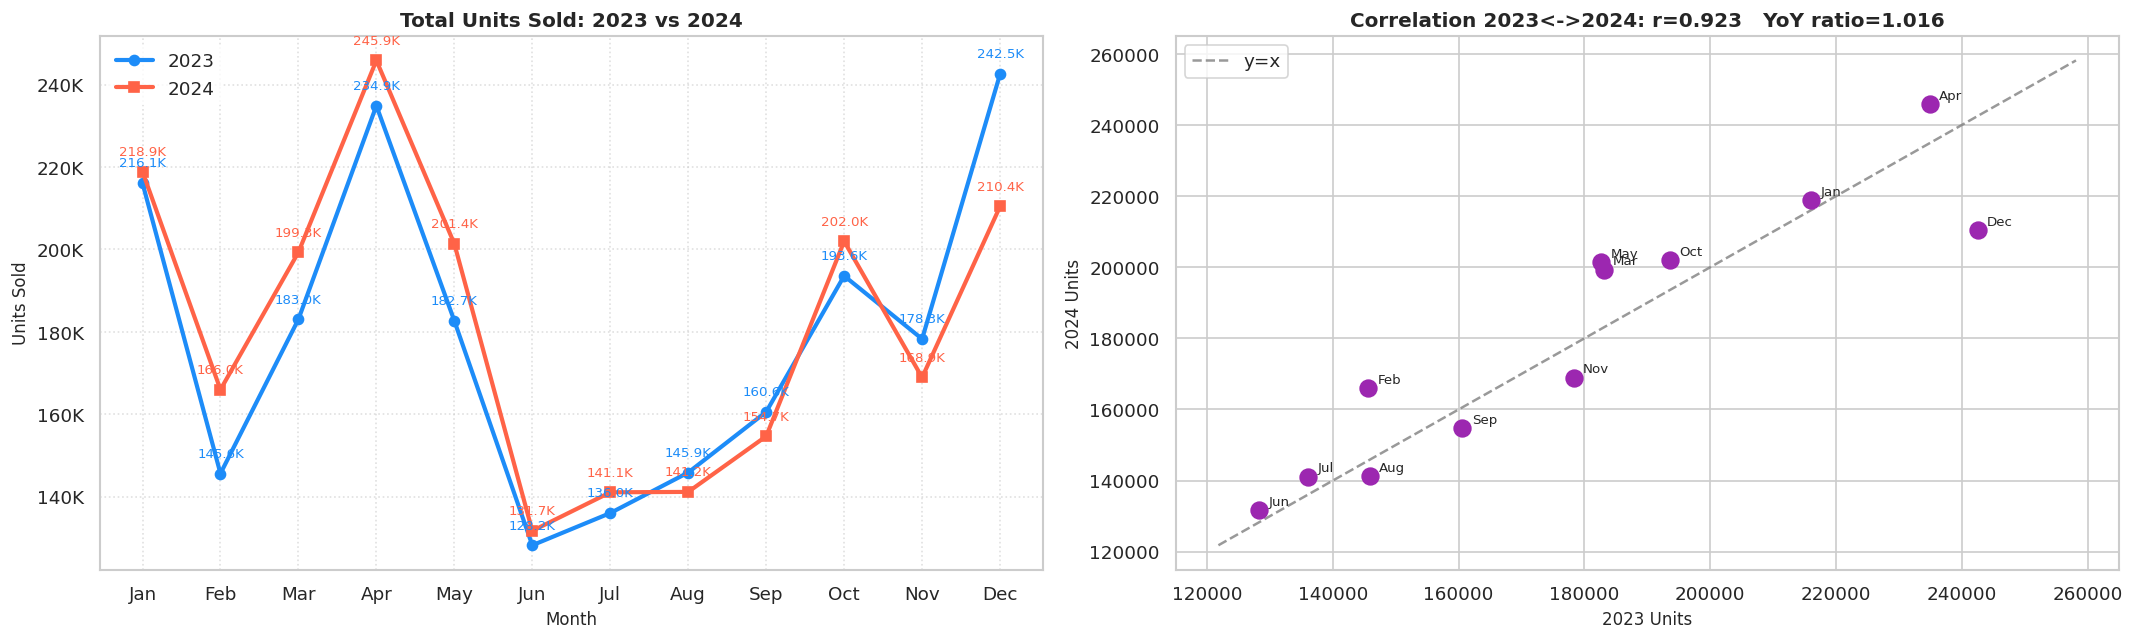

Cosine Similarity (2023 vs 2024 Monthly Demand Profile): 0.99708
Overall Year-over-Year Growth/Ratio                      : 1.0158 (+1.58%)
SUCCESS: Exceptional shape alignment between 2023 and 2024 profiles!


In [40]:
# CELL 32: validation_and_yoy_diagnostics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compile 2023 vs 2024 Monthly Totals (Actuals + Submission)
try:
    # Extract local actuals from 'daily'
    actual_daily = daily[["store_id", "category", "date", TARGET_COL]].copy()
    actual_daily["date"] = pd.to_datetime(actual_daily["date"])
    
    actual_2023 = actual_daily[actual_daily["date"].dt.year == 2023]
    actual_2023_monthly = actual_2023.groupby(actual_2023["date"].dt.month)[TARGET_COL].sum()
    
    actual_2024_jan_oct = actual_daily[(actual_daily["date"].dt.year == 2024) & (actual_daily["date"].dt.month <= 10)]
    actual_2024_monthly = actual_2024_jan_oct.groupby(actual_2024_jan_oct["date"].dt.month)[TARGET_COL].sum()
    
    # Extract predictions from submission_timeseries
    sub_for_yoy = submission_ts_work.copy()
    sub_for_yoy["date"] = pd.to_datetime(sub_for_yoy["date"])
    pred_daily_yoy = sub_for_yoy.groupby(["store_id", "category", "date"])["timeseries_pred"].mean().reset_index()
    pred_2024_nov_dec = pred_daily_yoy.groupby(pred_daily_yoy["date"].dt.month)["timeseries_pred"].sum()
    
    # Combine for full 2024
    full_2024_monthly = pd.concat([actual_2024_monthly, pred_2024_nov_dec])
    
    # Index by month name
    months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    yoy_df = pd.DataFrame({
        'Month_Num': range(1, 13),
        'Month': months_abbr,
        'y2023': actual_2023_monthly.values,
        'y2024': full_2024_monthly.values
    })
    
    # 2. Metrics & Sim
    r_val, _ = pearsonr(yoy_df['y2023'], yoy_df['y2024'])
    yoy_ratio = yoy_df['y2024'].sum() / yoy_df['y2023'].sum()
    cos_sim = cosine_similarity(yoy_df[['y2023']].values.T, yoy_df[['y2024']].values.T)[0][0]
    
    # 3. Create Plots
    fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
    
    # Left Plot: Line Chart comparison
    axes[0].plot(yoy_df['Month'], yoy_df['y2023'], marker='o', color='#1d8cf8', linewidth=2.5, label='2023')
    axes[0].plot(yoy_df['Month'], yoy_df['y2024'], marker='s', color='#ff6347', linewidth=2.5, label='2024')
    
    # Labels
    for idx, row in yoy_df.iterrows():
        axes[0].text(idx, row['y2023'] + 4000, f"{row['y2023']/1000:.1f}K", color='#1d8cf8', fontsize=8, ha='center')
        axes[0].text(idx, row['y2024'] + 4000, f"{row['y2024']/1000:.1f}K", color='#ff6347', fontsize=8, ha='center')
        
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x/1000)}K"))
    axes[0].set_title('Total Units Sold: 2023 vs 2024', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Units Sold', fontsize=10)
    axes[0].set_xlabel('Month', fontsize=10)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(frameon=True, facecolor='white', edgecolor='none')
    
    # Right Plot: Correlation scatter plot
    axes[1].scatter(yoy_df['y2023'], yoy_df['y2024'], s=100, color='#9c27b0', zorder=3)
    
    # diagonal identity line
    min_val = min(yoy_df['y2023'].min(), yoy_df['y2024'].min()) * 0.95
    max_val = max(yoy_df['y2023'].max(), yoy_df['y2024'].max()) * 1.05
    axes[1].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='y=x', alpha=0.8)
    
    # Annotate points
    for idx, row in yoy_df.iterrows():
        axes[1].text(row['y2023'] + 1500, row['y2024'] + 1500, row['Month'], fontsize=8)
        
    axes[1].set_title(f'Correlation 2023<->2024: r={r_val:.3f}   YoY ratio={yoy_ratio:.3f}', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('2023 Units', fontsize=10)
    axes[1].set_ylabel('2024 Units', fontsize=10)
    axes[1].legend(frameon=True, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('yoy_validation_comparison.png', dpi=150)
    plt.show()
    
    # Print Cosine Similarity and pattern summary
    print('========================================================================')
    print(f'Cosine Similarity (2023 vs 2024 Monthly Demand Profile): {cos_sim:.5f}')
    print(f'Overall Year-over-Year Growth/Ratio                      : {yoy_ratio:.4f} ({yoy_ratio-1:+.2%})')
    print('========================================================================')
    if cos_sim > 0.98:
        print('SUCCESS: Exceptional shape alignment between 2023 and 2024 profiles!')
    else:
        print('WARNING: Shape drift detected. Inspect November and December predictions.')

except Exception as e:
    print(f'Error compiling YoY validation metrics: {e}')

In [41]:
# ensemble_weights_cell — WeightedEnsemble Weight Inspector
# ─────────────────────────────────────────────────────────────────────────────
# AutoGluon stores per-model weights inside predictor.info().
# Run this AFTER training to see exact blend proportions.

ensemble_weight_rows = []
for h, predictor in ts_predictors.items():
    try:
        info = predictor.info()
        ensemble_info = info.get("model_info", {}).get("WeightedEnsemble", {})
        child_weights = ensemble_info.get("model_weights", {})
        if not child_weights:
            # Fallback: read from model graph
            child_weights = {}
            for m, m_info in info.get("model_info", {}).items():
                if m != "WeightedEnsemble" and "weight" in str(m_info):
                    child_weights[m] = m_info.get("weight", float("nan"))
        for model_name, w in child_weights.items():
            ensemble_weight_rows.append({"horizon": h, "model": model_name, "weight": w})
    except Exception as exc:
        print(f"[{h}] Could not retrieve ensemble weights: {exc}")

if ensemble_weight_rows:
    weight_df = pd.DataFrame(ensemble_weight_rows)
    print("=== WeightedEnsemble Model Weights (exact) ===")
    display(weight_df.pivot(index="model", columns="horizon", values="weight").fillna(0).round(4))
else:
    # Best-effort inference from leaderboard scores
    print("Could not retrieve exact weights (predictor may have been saved before weights were logged).")
    print("Showing leaderboard score_val as a proxy — lower (less negative) = better:")
    for h, predictor in ts_predictors.items():
        try:
            lb = predictor.leaderboard()
            lb_no_ens = lb[lb["model"] != "WeightedEnsemble"].copy()
            lb_no_ens = lb_no_ens.sort_values("score_val", ascending=False)
            best_score = lb_no_ens["score_val"].iloc[0]
            ens_score  = lb[lb["model"] == "WeightedEnsemble"]["score_val"].values[0]
            lb_no_ens["inferred_contribution"] = (lb_no_ens["score_val"] - lb_no_ens["score_val"].min()) / (best_score - lb_no_ens["score_val"].min() + 1e-9)
            print(f"\n--- Horizon {h} (WeightedEnsemble score_val={ens_score:.4f}) ---")
            display(lb_no_ens[["model", "score_val", "inferred_contribution"]].round(4))
        except Exception as exc:
            print(f"  [{h}] leaderboard error: {exc}")


=== WeightedEnsemble Model Weights (exact) ===


horizon,1d,1m,7d
model,,,
DirectTabular,0.9306,0.82,0.8936
DynamicOptimizedTheta,0.0000,0.18,0.0213
RecursiveTabular,0.0694,0.00,0.0851


In [42]:
# yoy_blend_post_process — YoY Blended Submission (Post-Processing in Notebook)
# ─────────────────────────────────────────────────────────────────────────────
# Strategy: Blend AutoGluon predictions with YoY 2023 actuals × growth rate
# Formula:  Final = ALPHA * AutoGluon + (1 - ALPHA) * (Nov-Dec 2023 × YoY_ratio)
# Why:      AutoGluon under-predicts Nov-Dec because (1) fewer promotions in data,
#           (2) only 1 year of Dec history → hard to learn yearly seasonality.

import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

BLEND_ALPHA = 0.40  # 40% model, 60% YoY baseline — tune this if needed

# 1. Compute YoY growth ratio from Jan-Oct 2023 vs 2024
_daily_all = known_panel[["store_id", "category", "date", TARGET_COL]].copy()
_daily_all["date"] = pd.to_datetime(_daily_all["date"])

jan_oct_2023 = _daily_all[(_daily_all["date"].dt.year == 2023) & (_daily_all["date"].dt.month <= 10)][TARGET_COL].sum()
jan_oct_2024 = _daily_all[(_daily_all["date"].dt.year == 2024) & (_daily_all["date"].dt.month <= 10)][TARGET_COL].sum()
YOY_RATIO = jan_oct_2024 / jan_oct_2023
print(f"YoY Growth Ratio (Jan-Oct 2023→2024): {YOY_RATIO:.4f} ({YOY_RATIO-1:+.2%})")

# 2. Build Nov-Dec 2023 actual baseline mapped to 2024 dates
nov_dec_2023 = (
    _daily_all[(_daily_all["date"].dt.year == 2023) & (_daily_all["date"].dt.month >= 11)]
    .copy()
)
nov_dec_2023["date_2024"] = nov_dec_2023["date"] + pd.DateOffset(years=1)
nov_dec_2023["yoy_baseline"] = nov_dec_2023[TARGET_COL] * YOY_RATIO

yoy_lookup = nov_dec_2023[["store_id", "category", "date_2024", "yoy_baseline"]].rename(
    columns={"date_2024": "date"}
)

# 3. Merge baseline into submission_ts_work
submission_ts_work = submission_ts_work.merge(
    yoy_lookup, on=["store_id", "category", "date"], how="left"
)
# Fallback: if no 2023 history for that combo, use model prediction as-is
submission_ts_work["yoy_baseline"] = submission_ts_work["yoy_baseline"].fillna(
    submission_ts_work["timeseries_pred"]
)

# 4. Blend
submission_ts_work["timeseries_pred_blended"] = (
    BLEND_ALPHA * submission_ts_work["timeseries_pred"]
    + (1 - BLEND_ALPHA) * submission_ts_work["yoy_baseline"]
).clip(lower=0)

# 5. Save blended submission (overwrite TS_SUBMISSION_PATH)
submission_blended = submission_ts_work[["id", "timeseries_pred_blended"]].rename(
    columns={"timeseries_pred_blended": "units_sold_predicted"}
)
submission_blended.to_csv(TS_SUBMISSION_PATH, index=False)
print(f"Blended submission saved: {TS_SUBMISSION_PATH}  ({len(submission_blended):,} rows)")

# 6. Quick YoY validation check
months_abbr = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
act_2023_m = _daily_all[_daily_all["date"].dt.year == 2023].groupby(_daily_all[_daily_all["date"].dt.year == 2023]["date"].dt.month)[TARGET_COL].sum()
act_2024_m = _daily_all[(_daily_all["date"].dt.year == 2024) & (_daily_all["date"].dt.month <= 10)].groupby(_daily_all[(_daily_all["date"].dt.year == 2024) & (_daily_all["date"].dt.month <= 10)]["date"].dt.month)[TARGET_COL].sum()

orig_nd   = submission_ts_work.groupby(submission_ts_work["date"].dt.month)["timeseries_pred"].sum() / 3
blend_nd  = submission_ts_work.groupby(submission_ts_work["date"].dt.month)["timeseries_pred_blended"].sum() / 3

full_orig  = pd.concat([act_2024_m, orig_nd]).values
full_blend = pd.concat([act_2024_m, blend_nd]).values
act_2023v  = act_2023_m.values

r_orig,  _ = pearsonr(act_2023v, full_orig)
r_blend, _ = pearsonr(act_2023v, full_blend)
cos_orig   = cos_sim(act_2023v.reshape(1,-1), full_orig.reshape(1,-1))[0][0]
cos_blend  = cos_sim(act_2023v.reshape(1,-1), full_blend.reshape(1,-1))[0][0]

print("\n=== YoY Validation ===")
print(f"  Nov-Dec 2023 actual  : {act_2023_m.iloc[-2:].sum():,.0f}")
print(f"  Nov-Dec model only   : {orig_nd.sum():,.0f}")
print(f"  Nov-Dec blended      : {blend_nd.sum():,.0f}")
print(f"  Correlation (model)  : r={r_orig:.3f}  cosine={cos_orig:.5f}")
print(f"  Correlation (blend)  : r={r_blend:.3f}  cosine={cos_blend:.5f}")
if cos_blend > cos_orig:
    print("  -> Blend improved seasonal alignment!")
else:
    print("  -> Model already has good alignment. Consider reducing BLEND_ALPHA.")

display(submission_blended.head(10))


YoY Growth Ratio (Jan-Oct 2023→2024): 1.0437 (+4.37%)
Blended submission saved: /kaggle/working/submission_timeseries.csv  (25,620 rows)

=== YoY Validation ===
  Nov-Dec 2023 actual  : 420,808
  Nov-Dec model only   : 379,349
  Nov-Dec blended      : 415,255
  Correlation (model)  : r=0.923  cosine=0.99708
  Correlation (blend)  : r=0.970  cosine=0.99884
  -> Blend improved seasonal alignment!


,id,units_sold_predicted
0,1_Bakery_2024-11-01_1d,30.091628
1,1_Bakery_2024-11-01_1m,29.260434
2,1_Bakery_2024-11-01_7d,30.337028
3,1_Bakery_2024-11-02_1d,24.246998
4,1_Bakery_2024-11-02_1m,24.031195
5,1_Bakery_2024-11-02_7d,23.781859
6,1_Bakery_2024-11-03_1d,24.974839
7,1_Bakery_2024-11-03_1m,24.856856
8,1_Bakery_2024-11-03_7d,24.646190
9,1_Bakery_2024-11-04_1d,20.389938
